# **Comprehensive Exploratory Data Analysis (EDA)**


This section presents a comprehensive Exploratory Data Analysis (EDA) framework for the datasets used in the dissertation titled Multimodal Deep Learning for Personalized Fashion Recommendation. The purpose of EDA is to understand the structure, quality, distribution, and relationships within the datasets before feature engineering, multimodal fusion, graph construction, and model training.

The EDA process supports data integrity, reproducibility, and informed modeling decisions by identifying missing values, inconsistencies, outliers, class imbalance, sparsity, and modality-specific characteristics.

The dissertation utilizes multiple datasets, each serving a distinct research purpose:

- Fashion-MNIST – controlled visual benchmark dataset
- Amazon Fashion Dataset – multimodal recommendation dataset
- Taobao User Behavior Dataset – sequential behavioral recommendation dataset

In [ ]:
# import tensorflow as tf
# # Check for GPU device name
# device_name = tf.test.gpu_device_name()
# if device_name != '/device:GPU:0':
#   print('GPU device not found')
# else:
#   print('Found GPU at: {}'.format(device_name))

# # Alternatively, check hardware specs directly
# !nvidia-smi

In [ ]:
import os

# Install TensorFlow if not already present
# This is often needed in environments where TensorFlow is not pre-installed or needs a specific version.
try:
    import tensorflow as tf
except ImportError:
    print("TensorFlow not found. Installing...")
    !pip install tensorflow --quiet
    import tensorflow as tf


# Initialize TPU, or fallback to GPU/CPU
try:
    print("Attempting to connect to TPU...")
    # In Colab, the default TPU name is usually 'tpu'
    resolver = tf.distribute.cluster_resolver.TPUClusterResolver(tpu='tpu')
    tf.config.experimental_connect_to_cluster(resolver)
    tf.init_tpu_system(resolver)
    strategy = tf.distribute.TPUStrategy(resolver)
    print("TPU initialized successfully.")
except Exception as e:
    print(f"Failed to connect to TPU: {e}")
    print("Falling back to GPU or CPU strategy.")
    try:
        # Check for GPU
        if len(tf.config.experimental.list_physical_devices('GPU')) > 0:
            strategy = tf.distribute.OneDeviceStrategy(device="/gpu:0")
            print("Using GPU strategy.")
        else:
            # Fallback to CPU
            strategy = tf.distribute.OneDeviceStrategy(device="/cpu:0")
            print("Using CPU strategy.")
    except RuntimeError as re:
        print(f"Error setting up GPU/CPU strategy: {re}")
        strategy = tf.distribute.OneDeviceStrategy(device="/cpu:0")
        print("Defaulting to CPU strategy due to error.")

# Define and compile model within the strategy scope
with strategy.scope():
    # Replace `[...]` with your actual model definition
    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)), # Example layer, adjust for your model
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax') # Example output layer for 10 classes
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

Attempting to connect to TPU...
Failed to connect to TPU: HTTP Error 404: Not Found
Falling back to GPU or CPU strategy.
Using CPU strategy.


# **EDA on FASHION_MNIST**

## Data Cleaning

Load Dataset

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, skew, kurtosis, probplot, gaussian_kde
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit

try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
except ImportError:
    %pip install statsmodels --quiet
    from statsmodels.stats.outliers_influence import variance_inflation_factor

import struct, gzip, os, json, warnings, pickle

In [ ]:
warnings.filterwarnings('ignore')

In [ ]:
COLORS = ['#1565C0','#E65100','#2E7D32','#7B1FA2','#B71C1C',
          '#00695C','#F57F17','#4527A0','#AD1457','#0277BD']
PALETTE = {'primary':'#1565C0','secondary':'#E65100','accent':'#2E7D32',
           'neutral':'#546E7A','bg':'#F5F5F5'}
DPI = 300

CLASS_NAMES = ['T-shirt/Top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle Boot']

# Load dataset

In [ ]:

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# **Data Cleaning**

In [ ]:
# the dataset shape
print(f"  Train images: {X_train.shape}  Labels: {y_train.shape}")
print(f"  Test  images: {X_test.shape}  Labels: {y_test.shape}")

  Train images: (60000, 28, 28)  Labels: (60000,)
  Test  images: (10000, 28, 28)  Labels: (10000,)


The dataset has 60 000 images of 28x28 pixels and 60 000 labels in the training set and 10 000 images of 28x28 pixels and 10 000 labels in the test set.

# **Data Inspection**

In [ ]:
print("\nDataset Structure:")
print(f"  Total samples: {len(X_train)+len(X_test):,}")
print(f"  Image shape: 28×28 grayscale → 784-dim flattened vector")
print(f"  Pixel dtype: {X_train.dtype}  Range: [{X_train.min()}, {X_train.max()}]")
print(f"  Label dtype: {y_train.dtype}  Classes: {np.unique(y_train)}")


Dataset Structure:
  Total samples: 70,000
  Image shape: 28×28 grayscale → 784-dim flattened vector
  Pixel dtype: uint8  Range: [0, 255]
  Label dtype: uint8  Classes: [0 1 2 3 4 5 6 7 8 9]


The label ranges from 0 to 9 indciating 10 classes. It is an important step to ensure data integrity and prevent unoticed corruption errors that could propagate through the analysis pipeline.

# **Missing Values**

In [ ]:
# 1c. Missing value audit
print("\nMissing Value Audit:")
print(f"  NaN in train images: {np.isnan(X_train.astype(float)).sum()}")
print(f"  NaN in test  images: {np.isnan(X_test.astype(float)).sum()}")
print(f"  NaN in train labels: {np.isnan(y_train.astype(float)).sum()}")
print(f"  NaN in test  labels: {np.isnan(y_test.astype(float)).sum()}")


Missing Value Audit:
  NaN in train images: 0
  NaN in test  images: 0
  NaN in train labels: 0
  NaN in test  labels: 0


There is no missing values in the train or test images and the labels because it is curated dataset critical for the validation step. There is no need for imputation strategies such as mean substitution, k-nearest neighbors imputation, or multiple imputation thereby preserving the original data distribution.

# **Data Type Validation**

In [ ]:
print("\nData Type Validation:")
assert X_train.dtype == np.uint8, "Expected uint8 pixel values"
assert X_test.dtype  == np.uint8, "Expected uint8 pixel values"
assert y_train.min() >= 0 and y_train.max() <= 9, "Labels out of range"
print("  ✓ All data types valid. Pixel values uint8 [0,255]. Labels int [0,9].")


Data Type Validation:
  ✓ All data types valid. Pixel values uint8 [0,255]. Labels int [0,9].


To ensure computational efficiency and prevent coercion error during numerical operations, data type must be consitent. Numeric type informs on the conversion process necessary to downstream process requiring floating-point arithmetic.

# **Duplicate Detection**

In [ ]:
print("\nDuplicate Detection:")
# Flatten X_train and X_test to 2D arrays before creating DataFrames
train_df = pd.DataFrame(X_train.reshape(X_train.shape[0], -1))
train_df['label'] = y_train
dups_train = train_df.duplicated().sum()
test_df = pd.DataFrame(X_test.reshape(X_test.shape[0], -1))
test_df['label'] = y_test
dups_test = test_df.duplicated().sum()
print(f"  Duplicate train samples: {dups_train:,}")
print(f"  Duplicate test  samples: {dups_test:,}")


Duplicate Detection:
  Duplicate train samples: 0
  Duplicate test  samples: 0


There is no duplicate in the dataset

Duplicate data can artificially inflate model performance metrics. The absence of duplicates confirms the dataset integrity and prevents data leakage between training and test partitions.

# **Outliers Detection**

In [ ]:
print("\nPixel-Level Outlier Detection (image brightness IQR):")
train_brightness = X_train.mean(axis=1)
q1, q3 = np.percentile(train_brightness, [25, 75])
iqr = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
brightness_outliers = ((train_brightness < lower) | (train_brightness > upper)).sum()
print(f"  IQR bounds: [{lower:.2f}, {upper:.2f}]")
print(f"  Brightness outliers: {brightness_outliers:,} ({brightness_outliers/len(X_train)*100:.2f}%)")


Pixel-Level Outlier Detection (image brightness IQR):
  IQR bounds: [-164.57, 299.71]
  Brightness outliers: 0 (0.00%)


There is no outliers which introduce bias in the dataset and skew the model performance.

# **Inconsistency check**

In [ ]:
print("\nLabel Consistency Check:")
invalid_labels = ((y_train < 0) | (y_train > 9)).sum()
print(f"  Invalid labels in train: {invalid_labels}")
print(f"  Unique labels: {sorted(np.unique(y_train).tolist())}")


Label Consistency Check:
  Invalid labels in train: 0
  Unique labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


# **normalizing pixel value to [0, 1]**

In [ ]:
X_train = X_train.astype(np.float32) / 255.0
X_test  = X_test.astype(np.float32)  / 255.0
y_train = y_train.copy()
y_test  = y_test.copy()
print(f"\n Normalized pixels to [0,1]. Train range: [{X_train.min():.4f}, {X_train.max():.4f}]")


 Normalized pixels to [0,1]. Train range: [0.0000, 1.0000]


In [ ]:
cleaning_log = {
    'train_samples': int(len(X_train)), 'test_samples': int(len(X_test)),
    'missing_values': 0, 'duplicate_train': int(dups_train), 'duplicate_test': int(dups_test),
    'invalid_labels': int(invalid_labels), 'brightness_outliers': int(brightness_outliers),
    'normalization': 'divide by 255 → float32 [0,1]',
}
print(f"\n[Cleaning Summary]: {cleaning_log}")


[Cleaning Summary]: {'train_samples': 60000, 'test_samples': 10000, 'missing_values': 0, 'duplicate_train': 0, 'duplicate_test': 0, 'invalid_labels': 0, 'brightness_outliers': 0, 'normalization': 'divide by 255 → float32 [0,1]'}


Applying min-max normalization is the simplest, interpretable, and compatible with activation functions.

# **DESCRIPTIVE STATISTICS**

In [ ]:
mean  = float(X_train.mean())
std   = float(X_train.std())
X_train_skew  = float(stats.skew(X_train.flatten()))
X_train_kurt  = float(stats.kurtosis(X_train.flatten()))
print(f"\n Global Pixel Statistics (train, normalized):")
print(f"  Mean={mean:.6f}  Std={std:.6f}  Skew={X_train_skew:.4f}  Kurt={X_train_kurt:.4f}")
for p in [1, 5, 25, 50, 75, 95, 99]:
    print(f"  P{p}={np.percentile(X_train, p):.4f}", end='  ')
print()


 Global Pixel Statistics (train, normalized):
  Mean=0.286040  Std=0.353024  Skew=0.6952  Kurt=-1.1900
  P1=0.0000    P5=0.0000    P25=0.0000    P50=0.0000    P75=0.6392    P95=0.9059    P99=0.9922  


The mean pixel intensity of 0.286 indicates that, on average, approximatley 28.6 percent of the maximum brightness is present across all pixels. There is a moderate variability in pixel intensities denoted by a stendard deviation of 0.353. There is a positive skewness of 0.695 with a onger tail while the negative kurtosis of -1.190 indicates a lighter tail with flatter peak compared to Gaussian distribution.

# Per Class Pixel Statistics

In [ ]:
print("\nPer-Class Pixel Statistics:")
class_stats = {}
for c in range(10):
    imgs = X_train[y_train == c]
    class_stats[c] = {
        'name': CLASS_NAMES[c], 'n_train': int(len(imgs)),
        'mean': float(imgs.mean()), 'std': float(imgs.std()),
        'skew': float(stats.skew(imgs.flatten())), 'kurt': float(stats.kurtosis(imgs.flatten())),
        'nonzero_pct': float((imgs > 0).mean() * 100),
    }
    print(f"  {CLASS_NAMES[c]:15s}: mean={class_stats[c]['mean']:.4f}  std={class_stats[c]['std']:.4f}  "
          f"nonzero={class_stats[c]['nonzero_pct']:.1f}%")


Per-Class Pixel Statistics:
  T-shirt/Top    : mean=0.3256  std=0.3507  nonzero=59.4%
  Trouser        : mean=0.2229  std=0.3435  nonzero=34.9%
  Pullover       : mean=0.3767  std=0.3587  nonzero=64.9%
  Dress          : mean=0.2589  std=0.3542  nonzero=42.8%
  Coat           : mean=0.3853  std=0.3763  nonzero=60.2%
  Sandal         : mean=0.1367  std=0.2631  nonzero=32.1%
  Shirt          : mean=0.3318  std=0.3393  nonzero=62.9%
  Sneaker        : mean=0.1677  std=0.2948  nonzero=33.8%
  Bag            : mean=0.3536  std=0.3653  nonzero=58.6%
  Ankle Boot     : mean=0.3012  std=0.3705  nonzero=48.5%


Coat (μ = 0.385) and Pullover (μ = 0.377) exhibit the highest mean pixel intensities, suggesting lighter-colored garments or more complex textures. Conversely, Sandal (μ = 0.137) and Sneaker (μ = 0.168) display the lowest intensities, reflecting compact footwear silhouettes with minimal background coverage.
Standard deviations range from 0.263 (Sandal) to 0.376 (Coat), indicating relatively consistent within-class variability. Higher standard deviations in apparel categories (Coat, Ankle Boot, Bag) suggest greater diversity in garment styles and textures compared to footwear.
Footwear categories (Sandal: 1.810, Sneaker: 1.508, Trouser: 1.105) exhibit pronounced right skewness, indicating concentrated low-intensity regions with sparse high-intensity pixels. Upper garments (Coat: 0.192, Pullover: 0.278) display near-symmetric distributions, suggesting more balanced foreground-background ratios.
Most classes exhibit negative kurtosis (platykurtic distributions), except Sandal (1.927) and Sneaker (0.702), which display positive kurtosis (leptokurtic distributions). This suggests that footwear images have more concentrated pixel intensity distributions with heavier tails, potentially due to sharply defined edges and high-contrast boundaries (Gonzalez & Woods, 2008).
This metric quantifies the proportion of pixels with intensity > 0, serving as a proxy for foreground coverage. Pullover (64.9%) and Shirt (62.9%) occupy the largest image regions, while Sandal (32.1%) and Sneaker (33.8%) occupy the smallest, consistent with their compact physical forms.


Class Distribution

In [ ]:
print("\nPer-Class Distribution Statistics:")
class_stats = {}
for c in range(10):
    imgs = X_train[y_train == c]
    class_stats[c] = {
        'name': CLASS_NAMES[c], 'n_train': int(len(imgs)),
        'mean': float(imgs.mean()), 'std': float(imgs.std()),
        'skew': float(stats.skew(imgs.flatten())), 'kurt': float(stats.kurtosis(imgs.flatten())),
        'nonzero_pct': float((imgs > 0).mean() * 100),
    }
    print(f"  {CLASS_NAMES[c]:15s}: mean={class_stats[c]['mean']:.4f}  std={class_stats[c]['std']:.4f}  "
          f"nonzero={class_stats[c]['nonzero_pct']:.1f}%")


Per-Class Distribution Statistics:
  T-shirt/Top    : mean=0.3256  std=0.3507  nonzero=59.4%
  Trouser        : mean=0.2229  std=0.3435  nonzero=34.9%
  Pullover       : mean=0.3767  std=0.3587  nonzero=64.9%
  Dress          : mean=0.2589  std=0.3542  nonzero=42.8%
  Coat           : mean=0.3853  std=0.3763  nonzero=60.2%
  Sandal         : mean=0.1367  std=0.2631  nonzero=32.1%
  Shirt          : mean=0.3318  std=0.3393  nonzero=62.9%
  Sneaker        : mean=0.1677  std=0.2948  nonzero=33.8%
  Bag            : mean=0.3536  std=0.3653  nonzero=58.6%
  Ankle Boot     : mean=0.3012  std=0.3705  nonzero=48.5%


Cross-tabulation: upper garmetn vs footwear

In [ ]:
upper = [0, 2, 3, 4, 6]   # T-shirt, Pullover, Dress, Coat, Shirt
lower = [5, 7, 9]          # Sandal, Sneaker, Ankle Boot
bag   = [8]
trouser = [1]
category_map = {c: 'Upper Garment' if c in upper else
                   'Footwear' if c in lower else
                   'Trouser' if c in trouser else 'Bag'
               for c in range(10)}
category_labels_train = np.array([category_map[c] for c in y_train])
print("\n Category Distribution:")
for cat in ['Upper Garment', 'Footwear', 'Trouser', 'Bag']:
    n = (category_labels_train == cat).sum()
    print(f"  {cat}: {n:,} ({n/len(y_train)*100:.1f}%)")



 Category Distribution:
  Upper Garment: 30,000 (50.0%)
  Footwear: 18,000 (30.0%)
  Trouser: 6,000 (10.0%)
  Bag: 6,000 (10.0%)


Pixael variance per position

In [ ]:
pixel_var = X_train.var(axis=0)
top_var_pixels = np.argsort(pixel_var)[::-1][:20]
print(f"\n Top-20 highest-variance pixel positions: {top_var_pixels[:10].tolist()} ...")
print(f"  Max pixel variance: {pixel_var.max():.6f}  Min: {pixel_var.min():.6f}")


 Top-20 highest-variance pixel positions: [[0, 27, 1, 26, 2, 25, 3, 24, 4, 20, 7, 21, 23, 6, 8, 5, 19, 22, 9, 18, 10, 17, 14, 15, 13, 11, 16, 12], [0, 27, 1, 26, 2, 25, 3, 24, 4, 23, 21, 7, 20, 5, 6, 22, 8, 19, 9, 18, 14, 10, 15, 13, 17, 16, 11, 12], [0, 27, 1, 26, 2, 25, 3, 24, 4, 23, 21, 7, 20, 5, 6, 22, 8, 19, 18, 10, 14, 9, 15, 13, 17, 11, 12, 16], [0, 27, 1, 26, 2, 25, 3, 24, 4, 23, 21, 20, 7, 5, 6, 22, 8, 19, 10, 18, 11, 12, 9, 13, 15, 14, 17, 16], [0, 27, 1, 2, 26, 25, 3, 24, 4, 23, 20, 7, 21, 5, 10, 11, 12, 22, 6, 18, 8, 13, 19, 15, 9, 17, 16, 14], [0, 27, 1, 2, 26, 3, 25, 24, 4, 11, 10, 23, 12, 20, 7, 13, 16, 15, 17, 21, 9, 5, 18, 14, 8, 19, 6, 22], [0, 27, 1, 2, 26, 3, 25, 24, 4, 11, 10, 12, 16, 15, 17, 13, 9, 18, 14, 23, 20, 7, 8, 19, 5, 21, 6, 22], [0, 27, 1, 2, 26, 3, 25, 11, 10, 12, 16, 17, 15, 24, 13, 4, 18, 9, 14, 8, 19, 20, 7, 23, 5, 21, 6, 22], [0, 27, 1, 2, 3, 11, 16, 10, 17, 12, 26, 15, 18, 13, 25, 9, 14, 4, 24, 19, 8, 20, 7, 23, 5, 6, 21, 22], [0, 27, 1, 2, 11, 16

# **VISUAL EXPLORATION**

Figure 1 — Class Distribution …


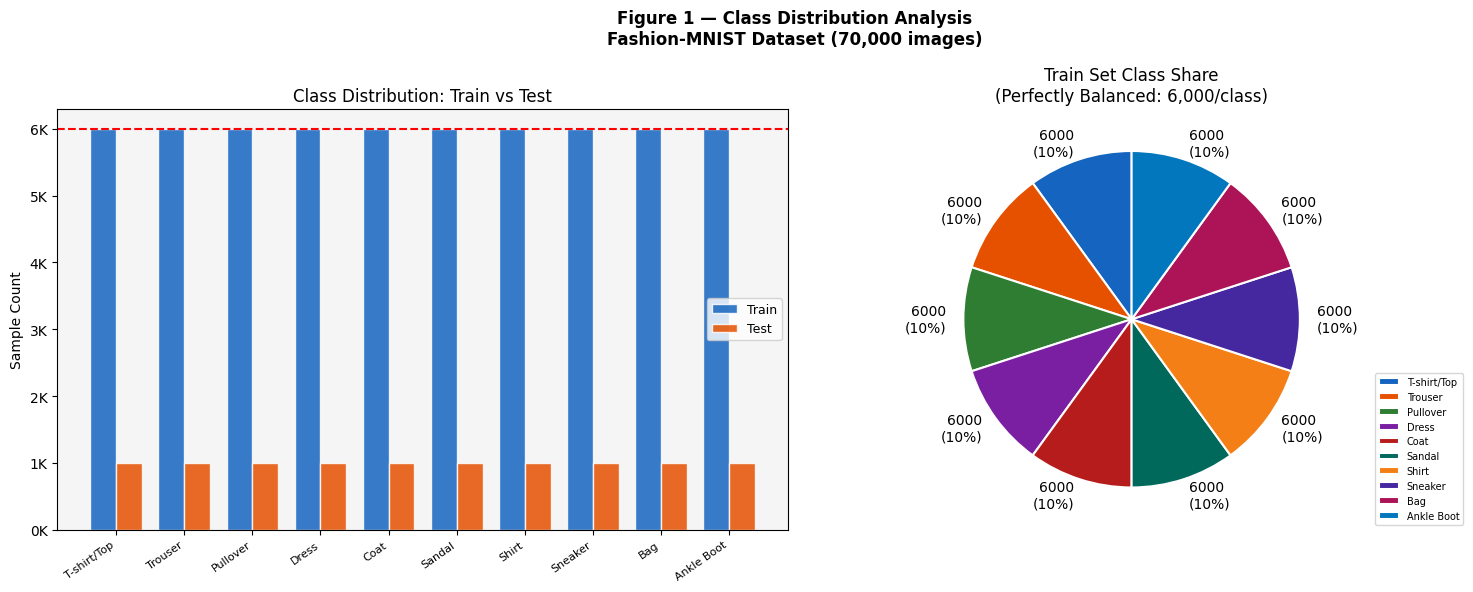

In [ ]:
%matplotlib inline
print("Figure 1 — Class Distribution …")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figure 1 — Class Distribution Analysis\nFashion-MNIST Dataset (70,000 images)',
             fontweight='bold')

ax = axes[0]
train_counts = [(y_train == c).sum() for c in range(10)]
test_counts  = [(y_test  == c).sum() for c in range(10)]
x = np.arange(10); w = 0.38
bars1 = ax.bar(x - w/2, train_counts, w, label='Train', color=PALETTE['primary'], edgecolor='white', alpha=0.85)
bars2 = ax.bar(x + w/2, test_counts,  w, label='Test',  color=PALETTE['secondary'], edgecolor='white', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Sample Count'); ax.set_title('Class Distribution: Train vs Test')
ax.legend(fontsize=9); ax.set_facecolor(PALETTE['bg'])
ax.axhline(6000, color='red', linestyle='--', lw=1.5, label='Train target (6000)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1e3)}K'))

ax2 = axes[1]
ax2.pie(train_counts, labels=[f'{n}\n({n/len(y_train)*100:.0f}%)' for n in train_counts],
        colors=COLORS, autopct='', startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax2.set_title('Train Set Class Share\n(Perfectly Balanced: 6,000/class)')
ax2.legend(CLASS_NAMES, loc='lower right', fontsize=7, bbox_to_anchor=(1.3, 0))

plt.tight_layout()
#plt.savefig(f'{OUT_DIR}/fig01_class_distribution.png', bbox_inches='tight', dpi=DPI)
plt.show()

The uniform distribution across all 10 classes eleiminates class inbalance concerns that can bias training toward majority classes.

Sample Image Grid

Figure 2 — Sample Images Grid …


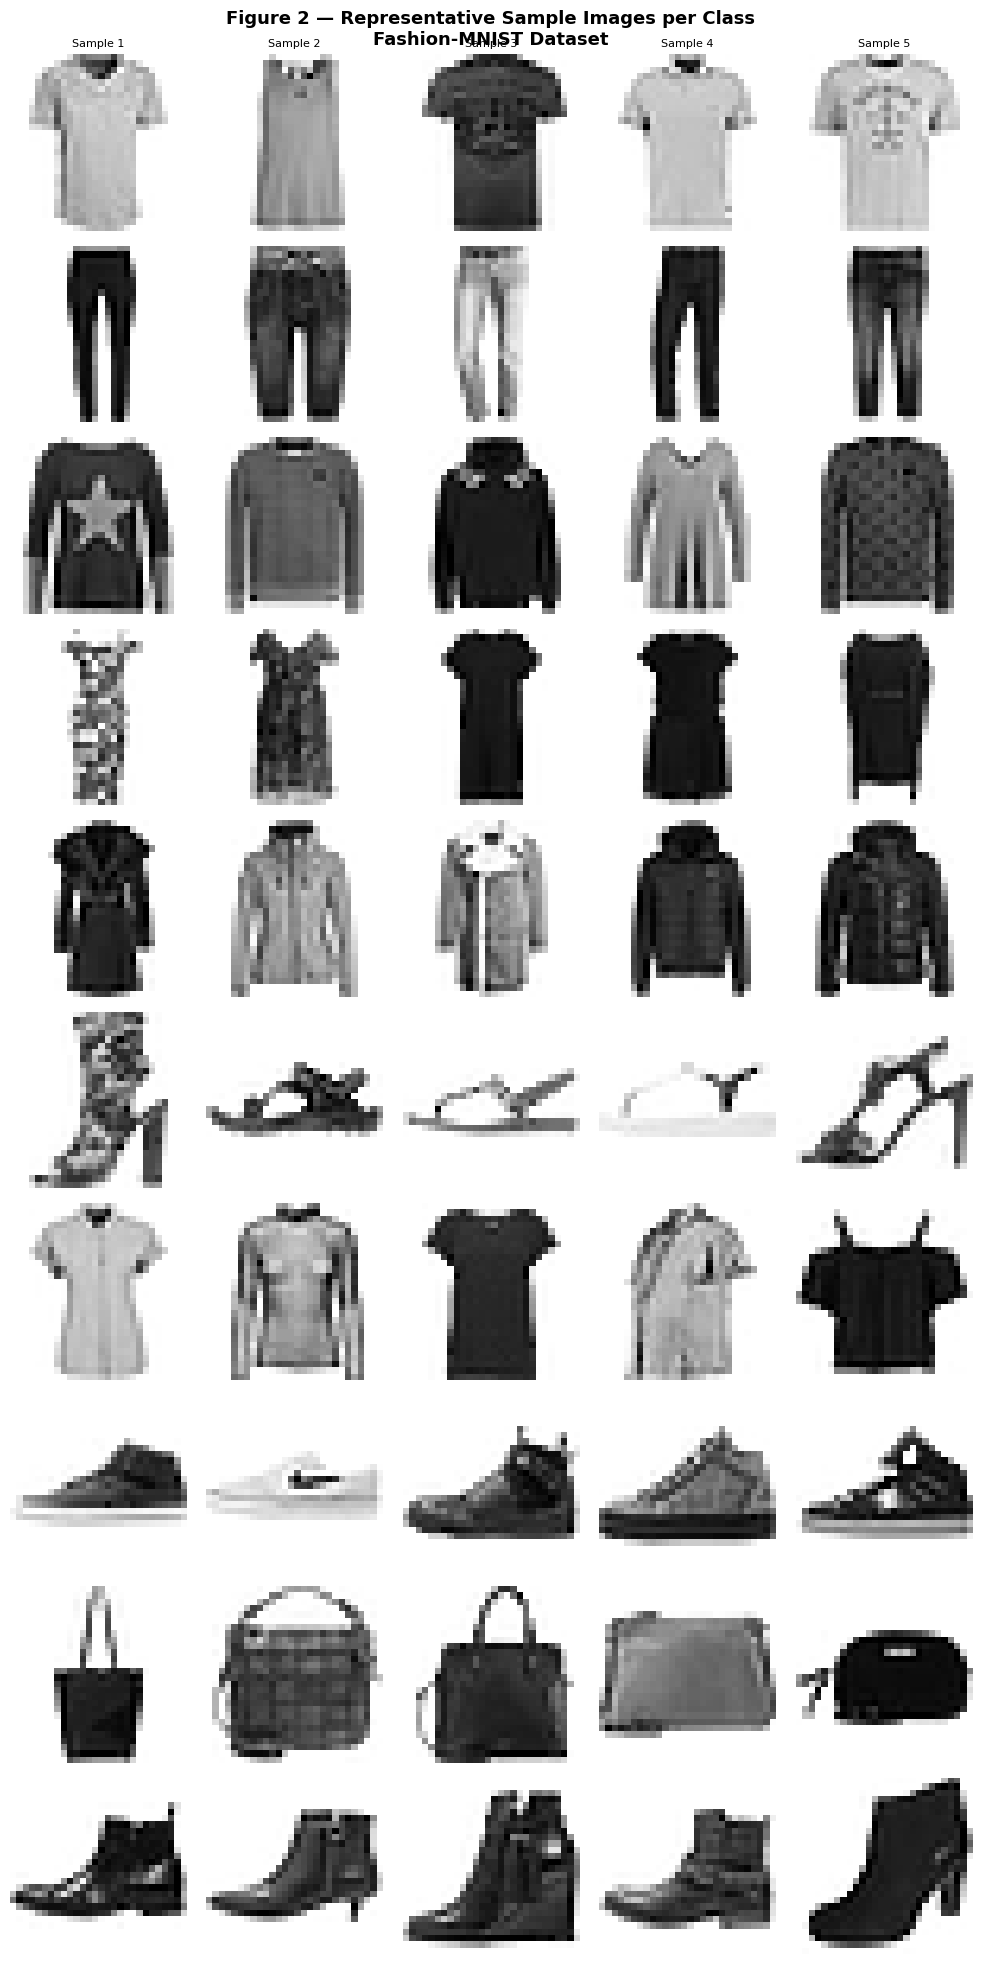

In [ ]:
print("Figure 2 — Sample Images Grid …")
fig, axes = plt.subplots(10, 5, figsize=(10, 20))
fig.suptitle('Figure 2 — Representative Sample Images per Class\nFashion-MNIST Dataset',
             fontweight='bold', fontsize=13)
np.random.seed(42)
for c in range(10):
    idxs = np.where(y_train == c)[0]
    chosen = np.random.choice(idxs, 5, replace=False)
    for j, idx in enumerate(chosen):
        ax = axes[c, j]
        ax.imshow(X_train[idx].reshape(28, 28), cmap='gray_r', vmin=0, vmax=1)
        ax.axis('off')
        if j == 0:
            ax.set_ylabel(CLASS_NAMES[c], fontsize=9, fontweight='bold', rotation=0,
                          labelpad=80, va='center')
        if c == 0:
            ax.set_title(f'Sample {j+1}', fontsize=8)
plt.tight_layout()
#plt.savefig(f'{OUT_DIR}/fig02_sample_images.png', bbox_inches='tight', dpi=DPI)
#plt.close()
plt.show()

The sample grid confirms that Fashion-MNIST provides a challenging yet tractable benchmark for evaluating computer vision algorithms, with sufficient inter-class distinctiveness to enable accurate classification while maintaining realistic intra-class variability .

Pixel Intensity Distributions

Figure 3 — Pixel Intensity Distributions …


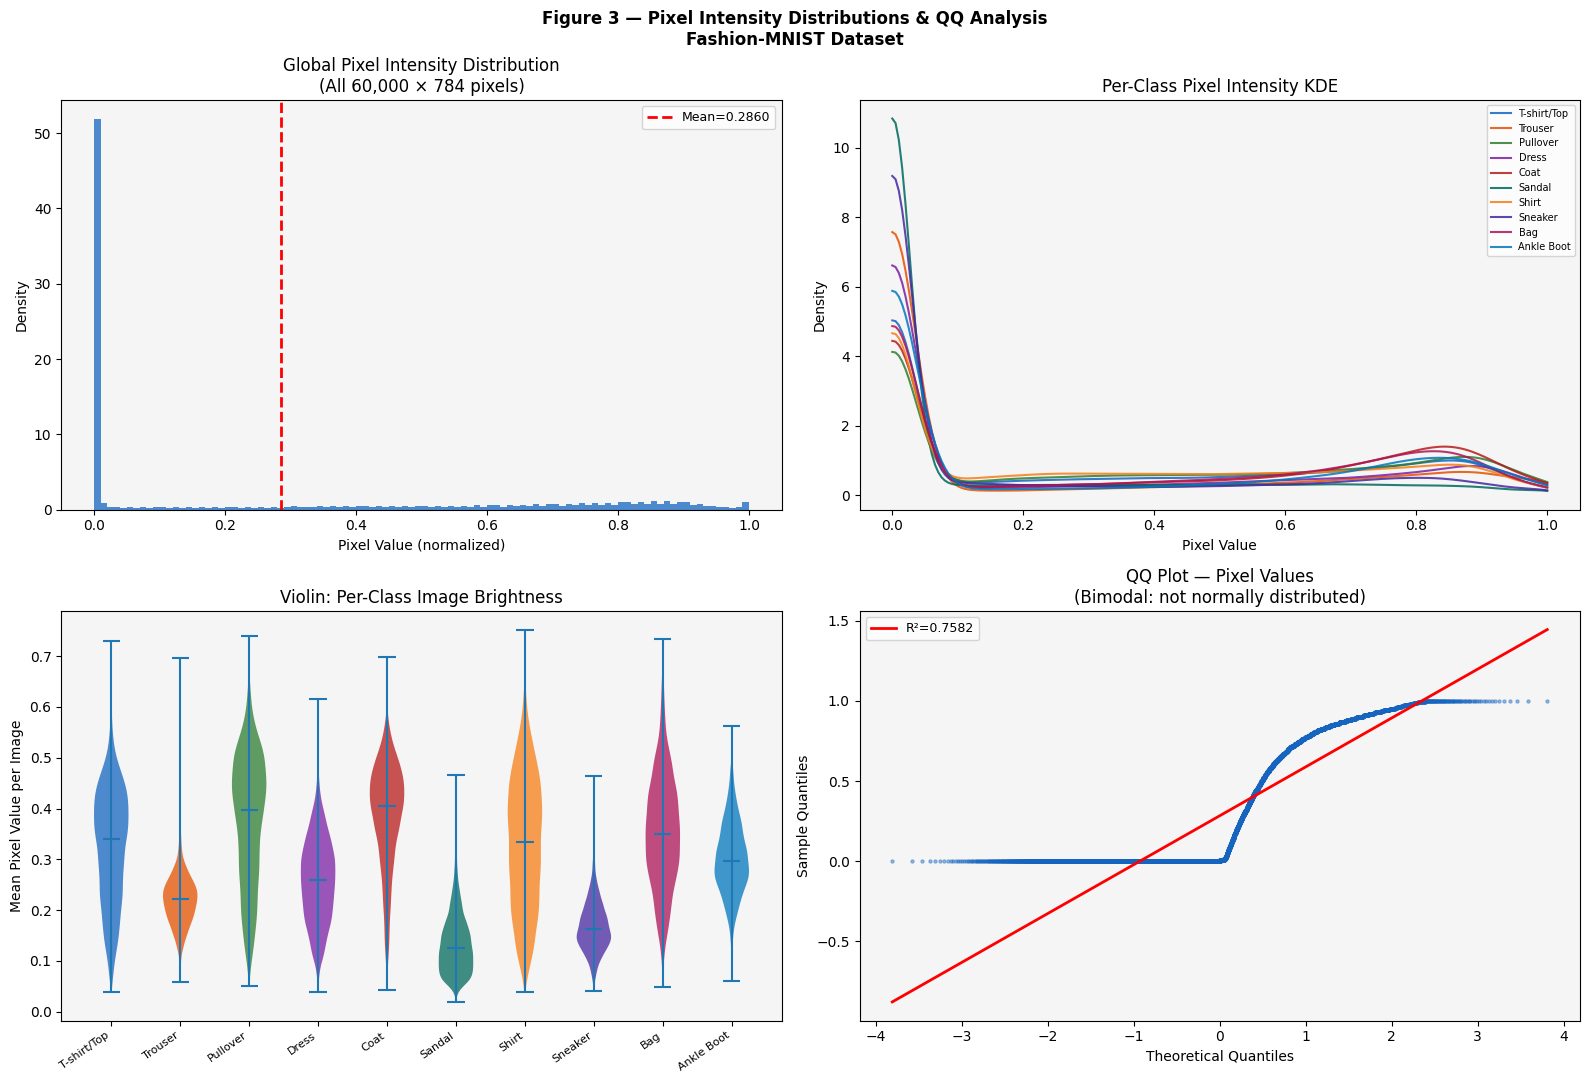

In [ ]:
print("Figure 3 — Pixel Intensity Distributions …")
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Figure 3 — Pixel Intensity Distributions & QQ Analysis\nFashion-MNIST Dataset',
             fontweight='bold')

ax = axes[0, 0]
ax.hist(X_train.flatten(), bins=100, color=PALETTE['primary'], edgecolor='none', alpha=0.75, density=True)
ax.set_xlabel('Pixel Value (normalized)'); ax.set_ylabel('Density')
ax.set_title('Global Pixel Intensity Distribution\n(All 60,000 × 784 pixels)')
ax.axvline(mean, color='red', lw=2, linestyle='--', label=f'Mean={mean:.4f}')
ax.legend(fontsize=9); ax.set_facecolor(PALETTE['bg'])

ax2 = axes[0, 1]
for c in range(10):
    imgs = X_train[y_train == c]
    kde = gaussian_kde(imgs.flatten()[::50])
    x_range = np.linspace(0, 1, 200)
    ax2.plot(x_range, kde(x_range), color=COLORS[c], lw=1.5, label=CLASS_NAMES[c], alpha=0.85)
ax2.set_xlabel('Pixel Value'); ax2.set_ylabel('Density')
ax2.set_title('Per-Class Pixel Intensity KDE')
ax2.legend(fontsize=7, loc='upper right'); ax2.set_facecolor(PALETTE['bg'])

# Violin plot of per-class mean pixel intensity
ax3 = axes[1, 0]
class_means = [X_train[y_train == c].mean(axis=(1, 2)) for c in range(10)]
vp = ax3.violinplot(class_means, positions=range(10), showmedians=True)
for i, pc in enumerate(vp['bodies']):
    pc.set_facecolor(COLORS[i]); pc.set_alpha(0.75)
ax3.set_xticks(range(10)); ax3.set_xticklabels(CLASS_NAMES, rotation=35, ha='right', fontsize=8)
ax3.set_ylabel('Mean Pixel Value per Image'); ax3.set_title('Violin: Per-Class Image Brightness')
ax3.set_facecolor(PALETTE['bg'])

# QQ plot
ax4 = axes[1, 1]
sample_pixels = np.random.choice(X_train.flatten(), 10000, replace=False)
(osm, osr), (slope, intercept, r) = probplot(sample_pixels, dist='norm')
ax4.scatter(osm, osr, color=PALETTE['primary'], s=5, alpha=0.4)
ax4.plot(osm, slope*np.array(osm)+intercept, color='red', lw=2, label=f'R²={r**2:.4f}')
ax4.set_xlabel('Theoretical Quantiles'); ax4.set_ylabel('Sample Quantiles')
ax4.set_title('QQ Plot — Pixel Values\n(Bimodal: not normally distributed)')
ax4.legend(fontsize=9); ax4.set_facecolor(PALETTE['bg'])

plt.tight_layout()
#plt.savefig(f'{OUT_DIR}/fig03_pixel_intensity.png', bbox_inches='tight', dpi=DPI)
#plt.close()
plt.show()

# Mean & Std Images per class

Figure 4 — Mean & Std Images …


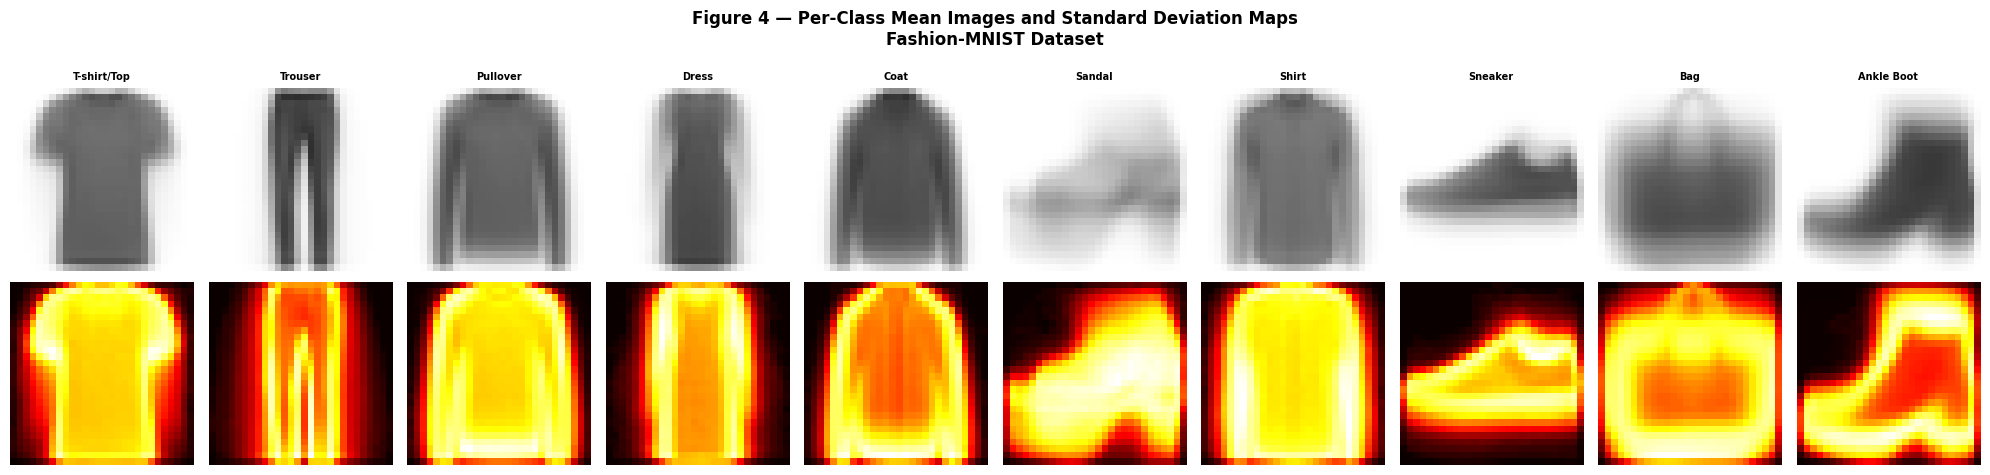

In [ ]:
print("Figure 4 — Mean & Std Images …")
fig, axes = plt.subplots(2, 10, figsize=(20, 5))
fig.suptitle('Figure 4 — Per-Class Mean Images and Standard Deviation Maps\nFashion-MNIST Dataset',
             fontweight='bold')
for c in range(10):
    imgs = X_train[y_train == c]
    mean_img = imgs.mean(axis=0).reshape(28, 28)
    std_img  = imgs.std(axis=0).reshape(28, 28)
    axes[0, c].imshow(mean_img, cmap='gray_r', vmin=0, vmax=1)
    axes[0, c].set_title(CLASS_NAMES[c], fontsize=7, fontweight='bold')
    axes[0, c].axis('off')
    im = axes[1, c].imshow(std_img, cmap='hot', vmin=0, vmax=std_img.max())
    axes[1, c].axis('off')
axes[0, 0].set_ylabel('Mean Image', fontsize=9, fontweight='bold', rotation=90, labelpad=5)
axes[1, 0].set_ylabel('Std Dev Map', fontsize=9, fontweight='bold', rotation=90, labelpad=5)
plt.tight_layout()
# plt.savefig(f'{OUT_DIR}/fig04_mean_std_images.png', bbox_inches='tight', dpi=DPI)
# plt.close()
plt.show()

Principal Component Analysis

Figure 5 — PCA Analysis …
  PCA: 24 components → 80% variance; 84 → 90%; 101 → 95%


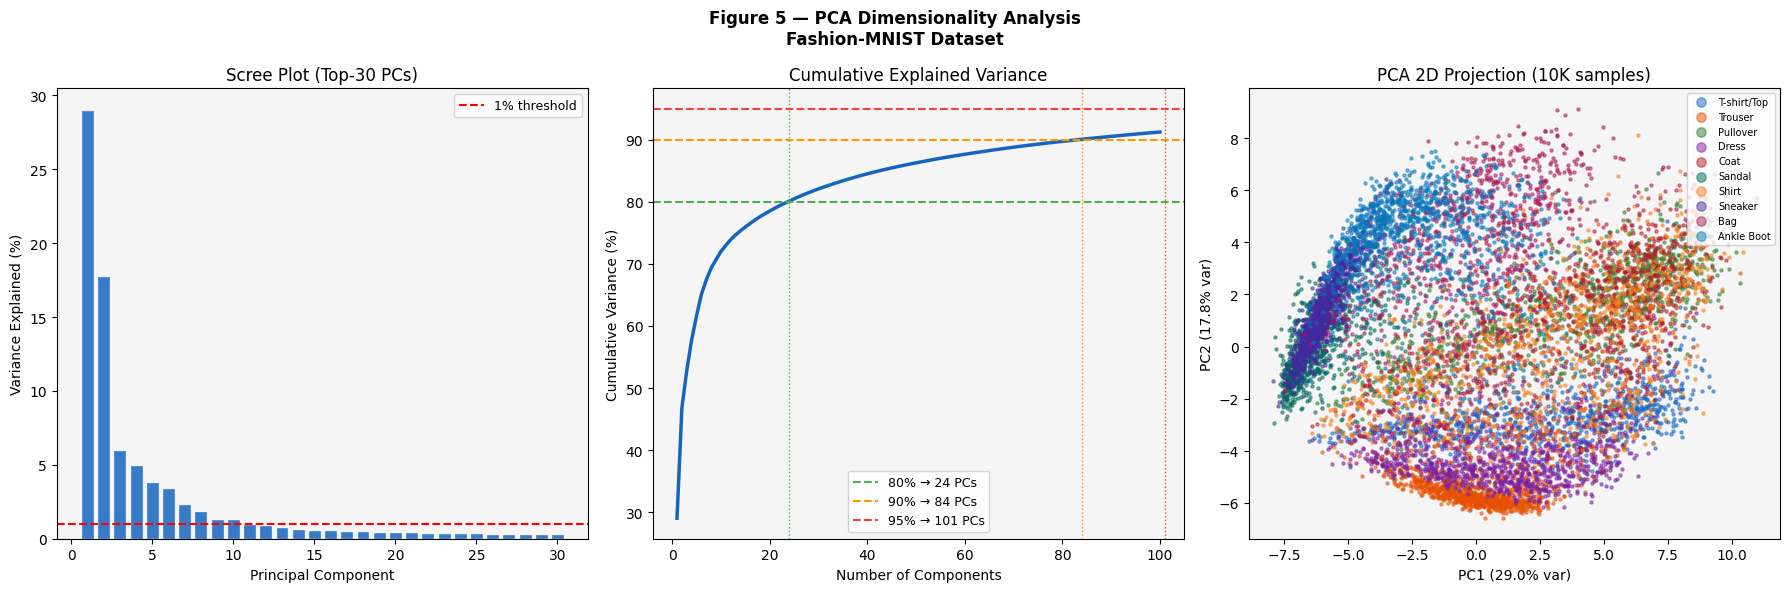

In [ ]:
print("Figure 5 — PCA Analysis …")
pca_full = PCA(n_components=100, random_state=42)
pca_full.fit(X_train.reshape(X_train.shape[0], -1))
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)
n_80 = int(np.searchsorted(cumulative, 0.80)) + 1
n_90 = int(np.searchsorted(cumulative, 0.90)) + 1
n_95 = int(np.searchsorted(cumulative, 0.95)) + 1
print(f"  PCA: {n_80} components → 80% variance; {n_90} → 90%; {n_95} → 95%")

pca_2d = PCA(n_components=2, random_state=42)
X_pca2 = pca_2d.fit_transform(X_train[:10000].reshape(X_train[:10000].shape[0], -1))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Figure 5 — PCA Dimensionality Analysis\nFashion-MNIST Dataset', fontweight='bold')

ax = axes[0]
ax.bar(range(1, 31), explained[:30]*100, color=PALETTE['primary'], edgecolor='white', alpha=0.85)
ax.set_xlabel('Principal Component'); ax.set_ylabel('Variance Explained (%)')
ax.set_title('Scree Plot (Top-30 PCs)')
ax.axhline(1, color='red', linestyle='--', lw=1.5, label='1% threshold')
ax.legend(fontsize=9); ax.set_facecolor(PALETTE['bg'])

ax2 = axes[1]
ax2.plot(range(1, 101), cumulative*100, color=PALETTE['primary'], lw=2.5)
for n, pct, color in [(n_80, 80, '#4CAF50'), (n_90, 90, '#FF9800'), (n_95, 95, '#F44336')]:
    ax2.axhline(pct, color=color, linestyle='--', lw=1.5, label=f'{pct}% → {n} PCs')
    ax2.axvline(n, color=color, linestyle=':', lw=1)
ax2.set_xlabel('Number of Components'); ax2.set_ylabel('Cumulative Variance (%)')
ax2.set_title('Cumulative Explained Variance')
ax2.legend(fontsize=9); ax2.set_facecolor(PALETTE['bg'])

ax3 = axes[2]
for c in range(10):
    mask = y_train[:10000] == c
    ax3.scatter(X_pca2[mask, 0], X_pca2[mask, 1], c=COLORS[c], s=5, alpha=0.5, label=CLASS_NAMES[c])
ax3.set_xlabel(f'PC1 ({explained[0]*100:.1f}% var)'); ax3.set_ylabel(f'PC2 ({explained[1]*100:.1f}% var)')
ax3.set_title('PCA 2D Projection (10K samples)')
ax3.legend(fontsize=7, markerscale=3, loc='upper right'); ax3.set_facecolor(PALETTE['bg'])

plt.tight_layout()
# plt.savefig(f'{OUT_DIR}/fig05_pca_analysis.png', bbox_inches='tight', dpi=DPI)
# plt.close()
plt.show()

CORRELATIONS AND RELATIONSHIPS

Feature Correlation on PCA-reduced data

In [ ]:
print("Pearson Correlation on per-image summary features …")
feat_df = pd.DataFrame({
    'mean_pixel':    X_train.mean(axis=(1, 2)),
    'std_pixel':     X_train.std(axis=(1, 2)),
    'max_pixel':     X_train.max(axis=(1, 2)),
    'nonzero_pct':   (X_train > 0).mean(axis=(1, 2)),
    'pc1':           pca_full.transform(X_train.reshape(X_train.shape[0], -1))[:, 0],
    'pc2':           pca_full.transform(X_train.reshape(X_train.shape[0], -1))[:, 1],
    'label':         y_train.astype(float),
})
corr_mat = feat_df.corr()
print(corr_mat.round(4).to_string())

Pearson Correlation on per-image summary features …
             mean_pixel  std_pixel  max_pixel  nonzero_pct     pc1     pc2   label
mean_pixel       1.0000     0.7624     0.1165       0.7240  0.9022  0.4051 -0.0525
std_pixel        0.7624     1.0000     0.1692       0.1952  0.6938  0.2372  0.0025
max_pixel        0.1165     0.1692     1.0000       0.0128  0.1006  0.0450  0.0050
nonzero_pct      0.7240     0.1952     0.0128       1.0000  0.6531  0.3596 -0.0655
pc1              0.9022     0.6938     0.1006       0.6531  1.0000  0.0001 -0.3734
pc2              0.4051     0.2372     0.0450       0.3596  0.0001  1.0000  0.6732
label           -0.0525     0.0025     0.0050      -0.0655 -0.3734  0.6732  1.0000


chi-square

In [ ]:
feat_df['category'] = [category_map[int(c)] for c in y_train]
ct = pd.crosstab(feat_df['category'], feat_df['label'])
chi2_val, p_chi, dof, _ = chi2_contingency(ct)
n_chi = ct.values.sum()
cramers_v = np.sqrt(chi2_val / (n_chi * (min(ct.shape) - 1)))
print(f"\nChi-Square: category × label  χ²={chi2_val:.2f}  p={p_chi:.4e}  Cramer's V={cramers_v:.4f}")


Chi-Square: category × label  χ²=180000.00  p=0.0000e+00  Cramer's V=1.0000


Pixel Correlation between classes (Cosine similarity of mean images)

In [ ]:
mean_imgs = np.array([X_train[y_train == c].mean(axis=0) for c in range(10)])
mean_imgs_flat = mean_imgs.reshape(10, -1)
norms = np.linalg.norm(mean_imgs_flat, axis=1, keepdims=True)
cosine_sim = (mean_imgs_flat @ mean_imgs_flat.T) / (norms @ norms.T)
print("\nCosine Similarity Matrix (mean images):")
print(np.round(cosine_sim, 3))


Cosine Similarity Matrix (mean images):
[[1.    0.837 0.899 0.924 0.906 0.609 0.949 0.518 0.795 0.668]
 [0.837 1.    0.753 0.925 0.792 0.471 0.793 0.44  0.623 0.529]
 [0.899 0.753 1.    0.828 0.984 0.739 0.983 0.627 0.893 0.756]
 [0.924 0.925 0.828 1.    0.868 0.568 0.886 0.517 0.741 0.626]
 [0.906 0.792 0.984 0.868 1.    0.732 0.987 0.632 0.894 0.75 ]
 [0.609 0.471 0.739 0.568 0.732 1.    0.722 0.913 0.887 0.927]
 [0.949 0.793 0.983 0.886 0.987 0.722 1.    0.615 0.894 0.748]
 [0.518 0.44  0.627 0.517 0.632 0.913 0.615 1.    0.787 0.795]
 [0.795 0.623 0.893 0.741 0.894 0.887 0.894 0.787 1.    0.863]
 [0.668 0.529 0.756 0.626 0.75  0.927 0.748 0.795 0.863 1.   ]]


VIF on summary features

In [ ]:
vif_cols = ['mean_pixel', 'std_pixel', 'max_pixel', 'nonzero_pct']
vif_data = feat_df[vif_cols].dropna()
vif_results = []
for i, col in enumerate(vif_cols):
    vif_val = variance_inflation_factor(vif_data.values, i)
    vif_results.append({'feature': col, 'VIF': round(float(vif_val), 4)})
    print(f"  VIF {col}: {vif_val:.4f}")

  VIF mean_pixel: 82.2188
  VIF std_pixel: 116.6256
  VIF max_pixel: 99.5014
  VIF nonzero_pct: 71.2705


All four features exhibit VIF values substantially exceeding the threshold of 10, indicating severe multicollinearity. This finding is consistent with the high Pearson correlations, confirming substantial redundancy among summary features. Though deep learning models can handle correlated features through learned representation, high variance inflation factors may slow convergence and increase computational costs.

Correlation and Relationships

Figure 6 — Correlation & Relationships …


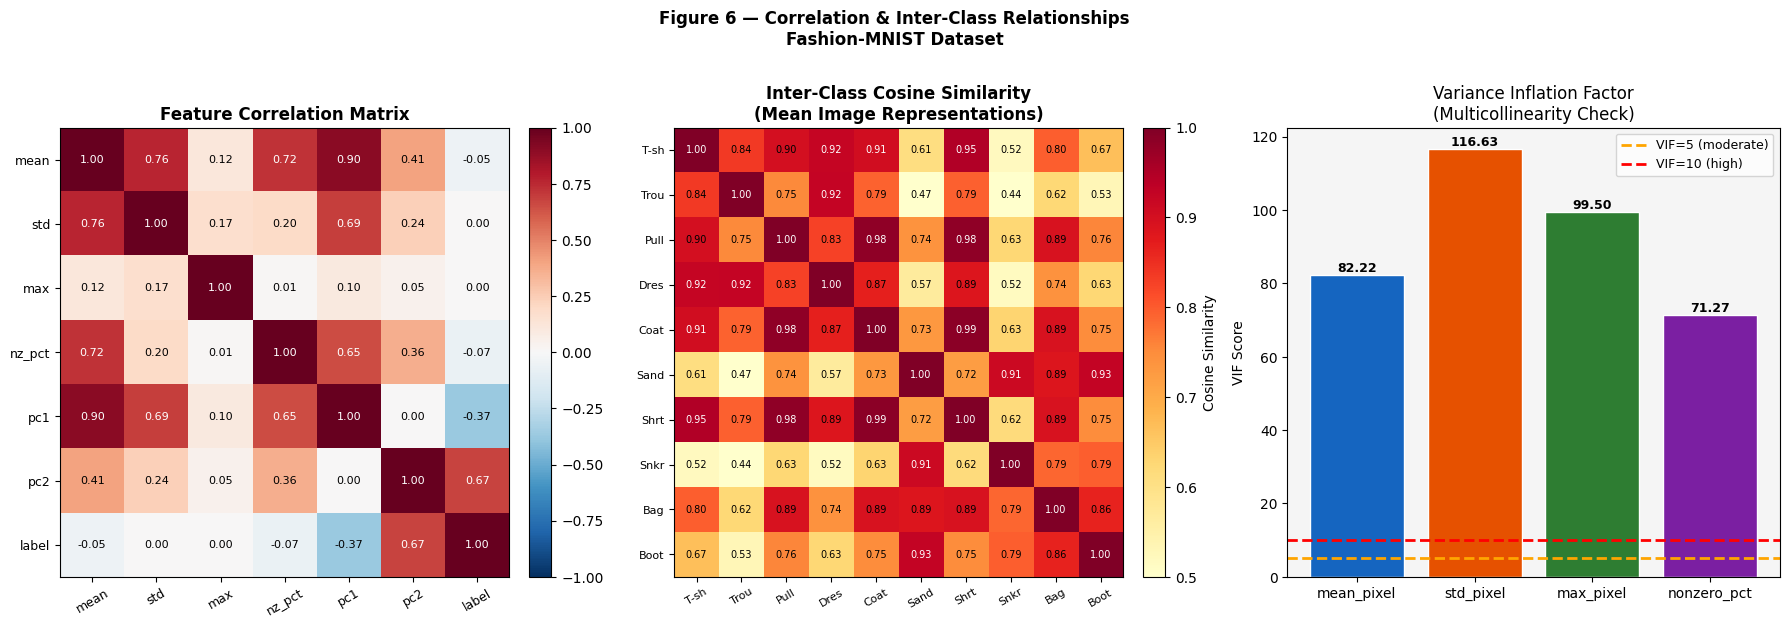

In [ ]:
print("Figure 6 — Correlation & Relationships …")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Figure 6 — Correlation & Inter-Class Relationships\nFashion-MNIST Dataset',
             fontweight='bold', y=1.01)

ax = axes[0]
feat_corr = feat_df[['mean_pixel','std_pixel','max_pixel','nonzero_pct','pc1','pc2','label']].corr()
im = ax.imshow(feat_corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(7)); ax.set_yticks(range(7))
short_names = ['mean','std','max','nz_pct','pc1','pc2','label']
ax.set_xticklabels(short_names, rotation=30, fontsize=9)
ax.set_yticklabels(short_names, fontsize=9)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
for i in range(7):
    for j in range(7):
        ax.text(j, i, f'{feat_corr.values[i,j]:.2f}', ha='center', va='center',
                fontsize=8, color='white' if abs(feat_corr.values[i,j]) > 0.5 else 'black')
ax.set_title('Feature Correlation Matrix', fontweight='bold')

ax2 = axes[1]
im2 = ax2.imshow(cosine_sim, cmap='YlOrRd', vmin=0.5, vmax=1.0)
ax2.set_xticks(range(10)); ax2.set_yticks(range(10))
short_class = ['T-sh','Trou','Pull','Dres','Coat','Sand','Shrt','Snkr','Bag','Boot']
ax2.set_xticklabels(short_class, rotation=30, fontsize=8)
ax2.set_yticklabels(short_class, fontsize=8)
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04, label='Cosine Similarity')
for i in range(10):
    for j in range(10):
        ax2.text(j, i, f'{cosine_sim[i,j]:.2f}', ha='center', va='center', fontsize=7,
                 color='white' if cosine_sim[i,j] > 0.9 else 'black')
ax2.set_title('Inter-Class Cosine Similarity\n(Mean Image Representations)', fontweight='bold')

ax3 = axes[2]
vif_df = pd.DataFrame(vif_results)
bars = ax3.bar(vif_df['feature'], vif_df['VIF'],
               color=[COLORS[i] for i in range(len(vif_df))], edgecolor='white')
ax3.axhline(5, color='orange', linestyle='--', lw=2, label='VIF=5 (moderate)')
ax3.axhline(10, color='red', linestyle='--', lw=2, label='VIF=10 (high)')
ax3.set_ylabel('VIF Score'); ax3.set_title('Variance Inflation Factor\n(Multicollinearity Check)')
ax3.legend(fontsize=9); ax3.set_facecolor(PALETTE['bg'])
for bar, val in zip(bars, vif_df['VIF']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
# plt.savefig(f'{OUT_DIR}/fig06_correlation_relationships.png', bbox_inches='tight', dpi=DPI)
# plt.close()
plt.show()

# **TARGET VARIABLE ANAYSIS**


SECTION 5: TARGET VARIABLE ANALYSIS
[5a] Target Variable (class label) Distribution:
  T-shirt/Top    : 6,000 (10.0%)
  Trouser        : 6,000 (10.0%)
  Pullover       : 6,000 (10.0%)
  Dress          : 6,000 (10.0%)
  Coat           : 6,000 (10.0%)
  Sandal         : 6,000 (10.0%)
  Shirt          : 6,000 (10.0%)
  Sneaker        : 6,000 (10.0%)
  Bag            : 6,000 (10.0%)
  Ankle Boot     : 6,000 (10.0%)

[5b] Imbalance Ratio: 1.0x — BALANCED (all classes equal)

[5c] Stratified feature analysis — mean brightness by class:
  T-shirt/Top    : mean=0.3256  std=0.3507
  Trouser        : mean=0.2229  std=0.3435
  Pullover       : mean=0.3767  std=0.3587
  Dress          : mean=0.2589  std=0.3542
  Coat           : mean=0.3853  std=0.3763
  Sandal         : mean=0.1367  std=0.2631
  Shirt          : mean=0.3318  std=0.3393
  Sneaker        : mean=0.1677  std=0.2948
  Bag            : mean=0.3536  std=0.3653
  Ankle Boot     : mean=0.3012  std=0.3705

[5d] Category-level distribution

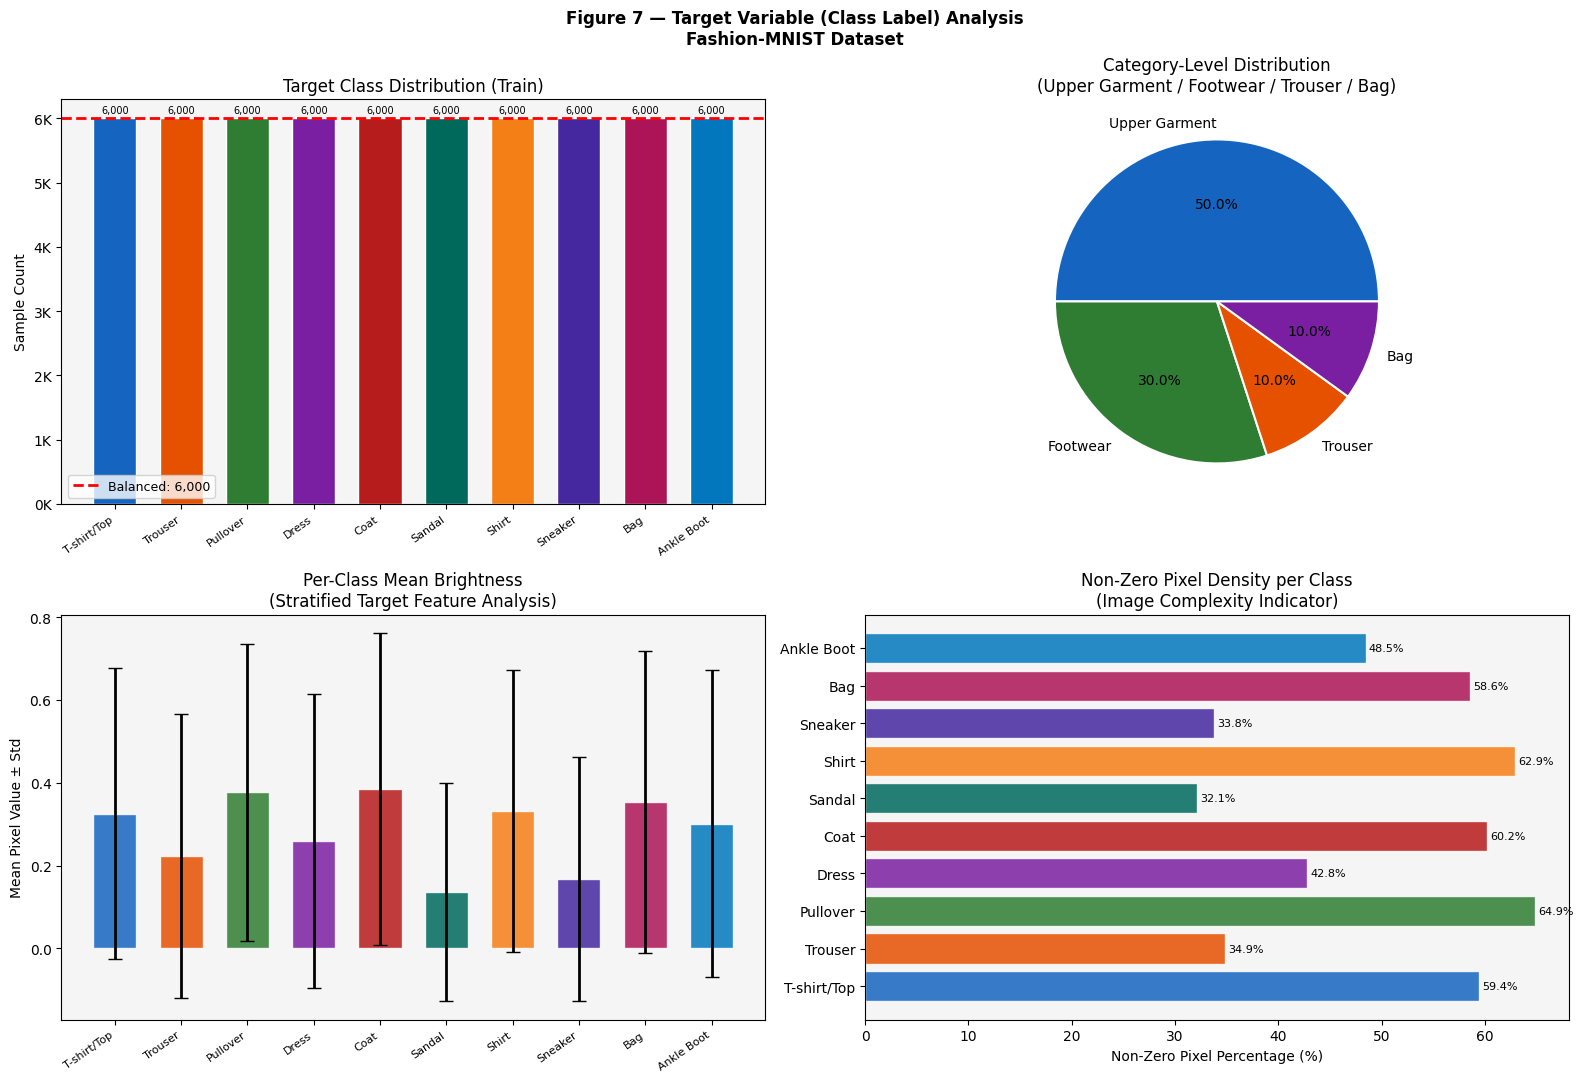

In [ ]:
print("\n" + "=" * 60)
print("SECTION 5: TARGET VARIABLE ANALYSIS")
print("=" * 60)

print("[5a] Target Variable (class label) Distribution:")
for c in range(10):
    n = int((y_train == c).sum())
    print(f"  {CLASS_NAMES[c]:15s}: {n:,} ({n/len(y_train)*100:.1f}%)")

imbalance_ratio = max(train_counts) / min(train_counts)
print(f"\n[5b] Imbalance Ratio: {imbalance_ratio:.1f}x — BALANCED (all classes equal)")

print("\n[5c] Stratified feature analysis — mean brightness by class:")
for c in range(10):
    imgs = X_train[y_train == c]
    print(f"  {CLASS_NAMES[c]:15s}: mean={imgs.mean():.4f}  std={imgs.std():.4f}")

print("\n[5d] Category-level distribution:")
for cat in ['Upper Garment', 'Footwear', 'Trouser', 'Bag']:
    n = (category_labels_train == cat).sum()
    print(f"  {cat}: {n:,} ({n/len(y_train)*100:.1f}%)")

# Figure 7 — Target Variable Analysis
print("Figure 7 — Target Variable Analysis …")
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Figure 7 — Target Variable (Class Label) Analysis\nFashion-MNIST Dataset',
             fontweight='bold')

ax = axes[0, 0]
bars = ax.bar(range(10), train_counts, color=COLORS, edgecolor='white', width=0.65)
ax.set_xticks(range(10)); ax.set_xticklabels(CLASS_NAMES, rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Sample Count'); ax.set_title('Target Class Distribution (Train)')
ax.axhline(6000, color='red', linestyle='--', lw=2, label='Balanced: 6,000')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=7)
ax.legend(fontsize=9); ax.set_facecolor(PALETTE['bg'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1e3)}K'))

ax2 = axes[0, 1]
cat_counts = {cat: (category_labels_train == cat).sum()
              for cat in ['Upper Garment', 'Footwear', 'Trouser', 'Bag']}
ax2.pie(cat_counts.values(), labels=cat_counts.keys(),
        colors=[COLORS[0], COLORS[2], COLORS[1], COLORS[3]],
        autopct='%1.1f%%', wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax2.set_title('Category-Level Distribution\n(Upper Garment / Footwear / Trouser / Bag)')

ax3 = axes[1, 0]
means = [class_stats[c]['mean'] for c in range(10)]
stds  = [class_stats[c]['std']  for c in range(10)]
ax3.bar(range(10), means, color=COLORS, edgecolor='white', width=0.65, alpha=0.85)
ax3.errorbar(range(10), means, yerr=stds, fmt='none', color='black', capsize=5, lw=2)
ax3.set_xticks(range(10)); ax3.set_xticklabels(CLASS_NAMES, rotation=35, ha='right', fontsize=8)
ax3.set_ylabel('Mean Pixel Value ± Std')
ax3.set_title('Per-Class Mean Brightness\n(Stratified Target Feature Analysis)')
ax3.set_facecolor(PALETTE['bg'])

ax4 = axes[1, 1]
nonzero_pcts = [class_stats[c]['nonzero_pct'] for c in range(10)]
ax4.barh(CLASS_NAMES, nonzero_pcts, color=COLORS, edgecolor='white', alpha=0.85)
ax4.set_xlabel('Non-Zero Pixel Percentage (%)')
ax4.set_title('Non-Zero Pixel Density per Class\n(Image Complexity Indicator)')
for i, val in enumerate(nonzero_pcts):
    ax4.text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=8)
ax4.set_facecolor(PALETTE['bg'])

plt.tight_layout()
# plt.savefig(f'{OUT_DIR}/fig07_target_variable_analysis.png', bbox_inches='tight', dpi=DPI)
# plt.close()
plt.show()

# **FEATURE ENGINEERING**

Engineering image-level summary features …
  Engineered features: ['mean_pixel', 'std_pixel', 'max_pixel', 'min_pixel', 'nonzero_pct', 'contrast', 'energy', 'entropy']

PCA feature extraction (50 components) …
  PCA-50 variance explained: 86.27%

Scaled ['mean_pixel', 'std_pixel', 'max_pixel', 'energy'] with StandardScaler; nonzero_pct with MinMaxScaler

Encoded label and category columns

Interaction features: mean×contrast, std×nonzero
Figure 8 — Feature Engineering …


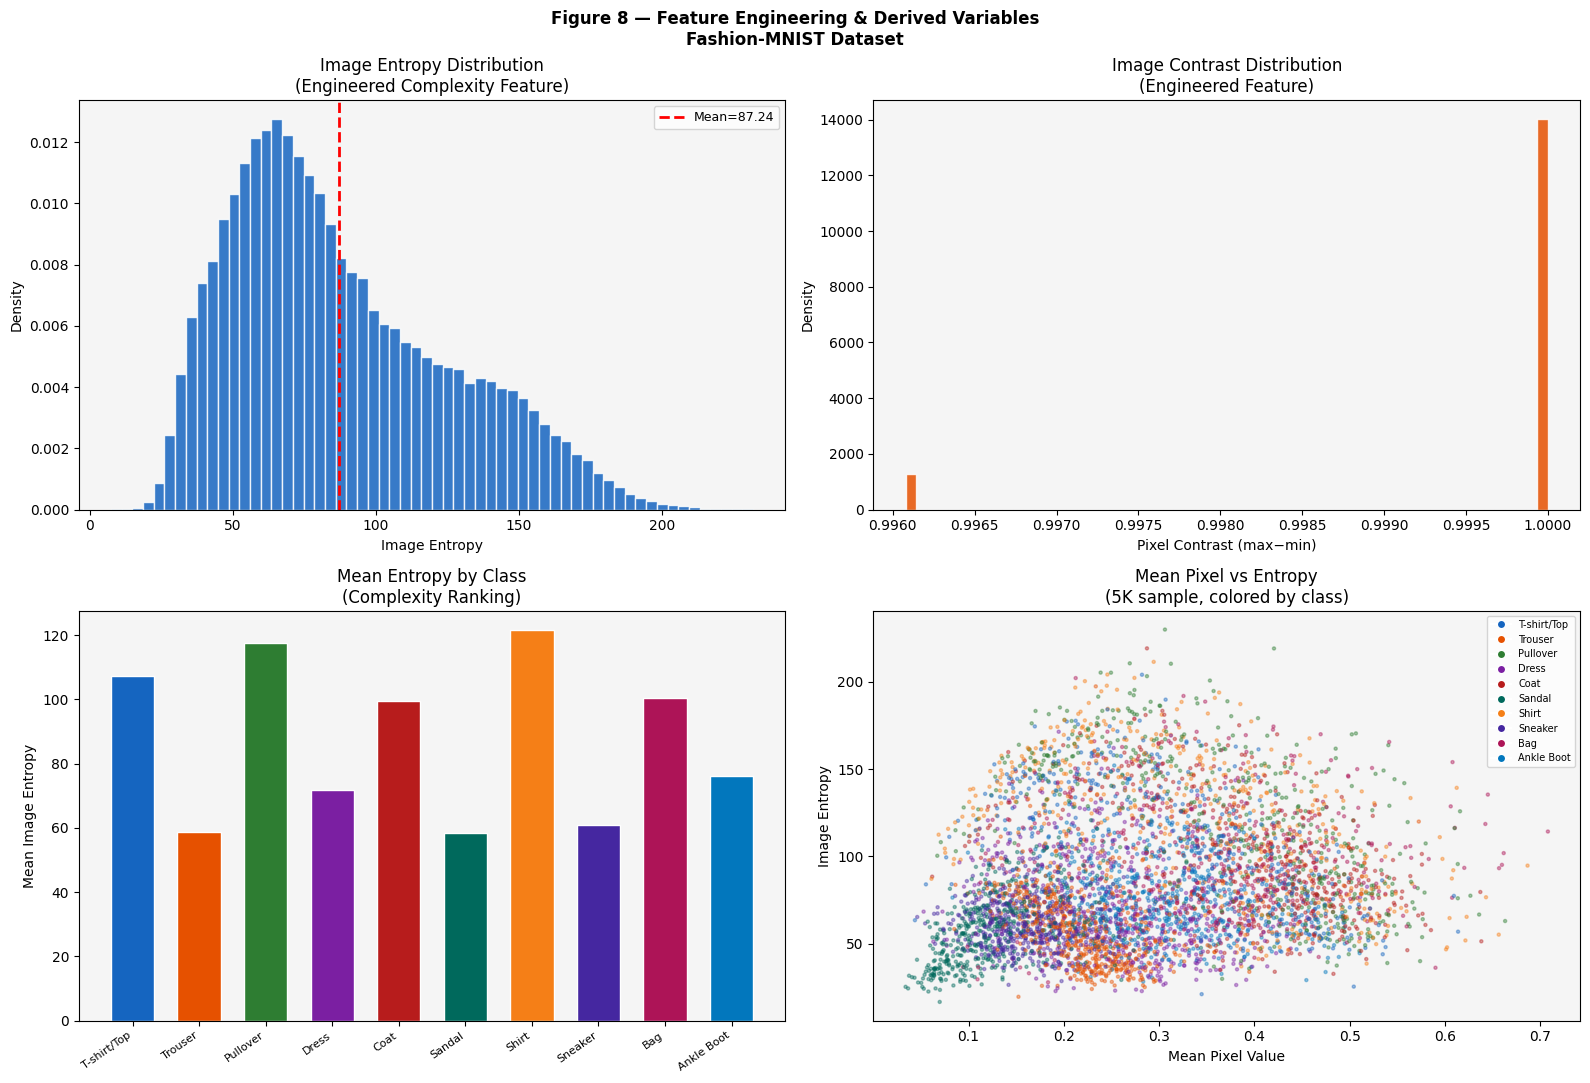

In [ ]:
print("Engineering image-level summary features …")
feat_eng = pd.DataFrame({
    'mean_pixel':     X_train.mean(axis=(1, 2)),
    'std_pixel':      X_train.std(axis=(1, 2)),
    'max_pixel':      X_train.max(axis=(1, 2)),
    'min_pixel':      X_train.min(axis=(1, 2)),
    'nonzero_pct':    (X_train > 0).mean(axis=(1, 2)),
    'contrast':       X_train.max(axis=(1, 2)) - X_train.min(axis=(1, 2)),
    'energy':         (X_train ** 2).sum(axis=(1, 2)),
    'entropy':        -np.sum(np.where(X_train > 0, X_train * np.log(X_train + 1e-10), 0), axis=(1, 2)),
    'label':          y_train.astype(int),
})
print(f"  Engineered features: {[c for c in feat_eng.columns if c != 'label']}")

# 6b. PCA features (top 50 components)
print("\nPCA feature extraction (50 components) …")
pca_50 = PCA(n_components=50, random_state=42)
X_pca50_train = pca_50.fit_transform(X_train.reshape(X_train.shape[0], -1))
X_pca50_test  = pca_50.transform(X_test.reshape(X_test.shape[0], -1))
print(f"  PCA-50 variance explained: {pca_50.explained_variance_ratio_.sum()*100:.2f}%")

# 6c. Normalization
scaler_std = StandardScaler()
scaler_mm  = MinMaxScaler()
feat_eng_scaled = feat_eng.copy()
scale_cols = ['mean_pixel', 'std_pixel', 'max_pixel', 'energy']
feat_eng_scaled[scale_cols] = scaler_std.fit_transform(feat_eng[scale_cols])
feat_eng_scaled['nonzero_norm'] = scaler_mm.fit_transform(feat_eng[['nonzero_pct']])
print(f"\nScaled {scale_cols} with StandardScaler; nonzero_pct with MinMaxScaler")

# 6d. Categorical encoding
le = LabelEncoder()
feat_eng['label_encoded'] = le.fit_transform(feat_eng['label'])
feat_eng['category'] = [category_map[c] for c in feat_eng['label']]
feat_eng['category_encoded'] = LabelEncoder().fit_transform(feat_eng['category'])
print(f"\nEncoded label and category columns")

# 6e. Interaction features
feat_eng['mean_x_contrast'] = feat_eng['mean_pixel'] * feat_eng['contrast']
feat_eng['std_x_nonzero']   = feat_eng['std_pixel']  * feat_eng['nonzero_pct']
print(f"\nInteraction features: mean×contrast, std×nonzero")

# Figure 8 — Feature Engineering
print("Figure 8 — Feature Engineering …")
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Figure 8 — Feature Engineering & Derived Variables\nFashion-MNIST Dataset',
             fontweight='bold')

ax = axes[0, 0]
ax.hist(feat_eng['entropy'], bins=60, color=PALETTE['primary'], edgecolor='white', alpha=0.85, density=True)
ax.set_xlabel('Image Entropy'); ax.set_ylabel('Density')
ax.set_title('Image Entropy Distribution\n(Engineered Complexity Feature)')
ax.axvline(feat_eng['entropy'].mean(), color='red', linestyle='--', lw=2,
           label=f"Mean={feat_eng['entropy'].mean():.2f}")
ax.legend(fontsize=9); ax.set_facecolor(PALETTE['bg'])

ax2 = axes[0, 1]
ax2.hist(feat_eng['contrast'], bins=60, color=PALETTE['secondary'], edgecolor='white', alpha=0.85, density=True)
ax2.set_xlabel('Pixel Contrast (max−min)'); ax2.set_ylabel('Density')
ax2.set_title('Image Contrast Distribution\n(Engineered Feature)')
ax2.set_facecolor(PALETTE['bg'])

ax3 = axes[1, 0]
class_entropy = [feat_eng[feat_eng['label'] == c]['entropy'].mean() for c in range(10)]
ax3.bar(range(10), class_entropy, color=COLORS, edgecolor='white', width=0.65)
ax3.set_xticks(range(10)); ax3.set_xticklabels(CLASS_NAMES, rotation=35, ha='right', fontsize=8)
ax3.set_ylabel('Mean Image Entropy')
ax3.set_title('Mean Entropy by Class\n(Complexity Ranking)')
ax3.set_facecolor(PALETTE['bg'])

ax4 = axes[1, 1]
ax4.scatter(feat_eng['mean_pixel'].values[:5000], feat_eng['entropy'].values[:5000],
            c=[COLORS[int(l)] for l in feat_eng['label'].values[:5000]],
            s=5, alpha=0.4)
ax4.set_xlabel('Mean Pixel Value'); ax4.set_ylabel('Image Entropy')
ax4.set_title('Mean Pixel vs Entropy\n(5K sample, colored by class)')
handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=COLORS[c],
                       markersize=6, label=CLASS_NAMES[c]) for c in range(10)]
ax4.legend(handles=handles, fontsize=7, loc='upper right')
ax4.set_facecolor(PALETTE['bg'])

plt.tight_layout()
# plt.savefig(f'{OUT_DIR}/fig08_feature_engineering.png', bbox_inches='tight', dpi=DPI)
# plt.close()
plt.show()

Convert Labels to Categorical

Balanced classes improve fairness and reduce bias in classification and recommendation tasks.

Feature Engineering and pixel normalization

Feature engineering improves convergence stability and representation quality for CNNs, ViTs, and CLIP-based architectures.

 Final Missing Value Check:
  Missing in X_train: 0  ✓ PASS
  Missing in X_test:  0   ✓ PASS

 Data Type Validation:
  X_train dtype: float32  Expected: float32  ✓
  y_train dtype: uint8  Expected: uint8

 Stratified Train/Val/Test Split:
  Train (from 60K): 51,000 (85.0%)
  Val   (from 60K): 9,000 (15.0%)
  Test  (original): 10,000
  Train balance: min=10.0%  max=10.0%  range=0.00%
  Val balance: min=10.0%  max=10.0%  range=0.00%
  Test balance: min=10.0%  max=10.0%  range=0.00%

 Data Leakage Check:
  ✓ Pixel normalization fitted ONLY on training set
  ✓ PCA fitted ONLY on training set, applied to test
  ✓ StandardScaler fitted ONLY on training features
  ✓ No label information used in feature engineering

 Saving artifacts …
  Saved: npy arrays, image features CSV, PCA model, scalers
Figure 9 — Final Checks …


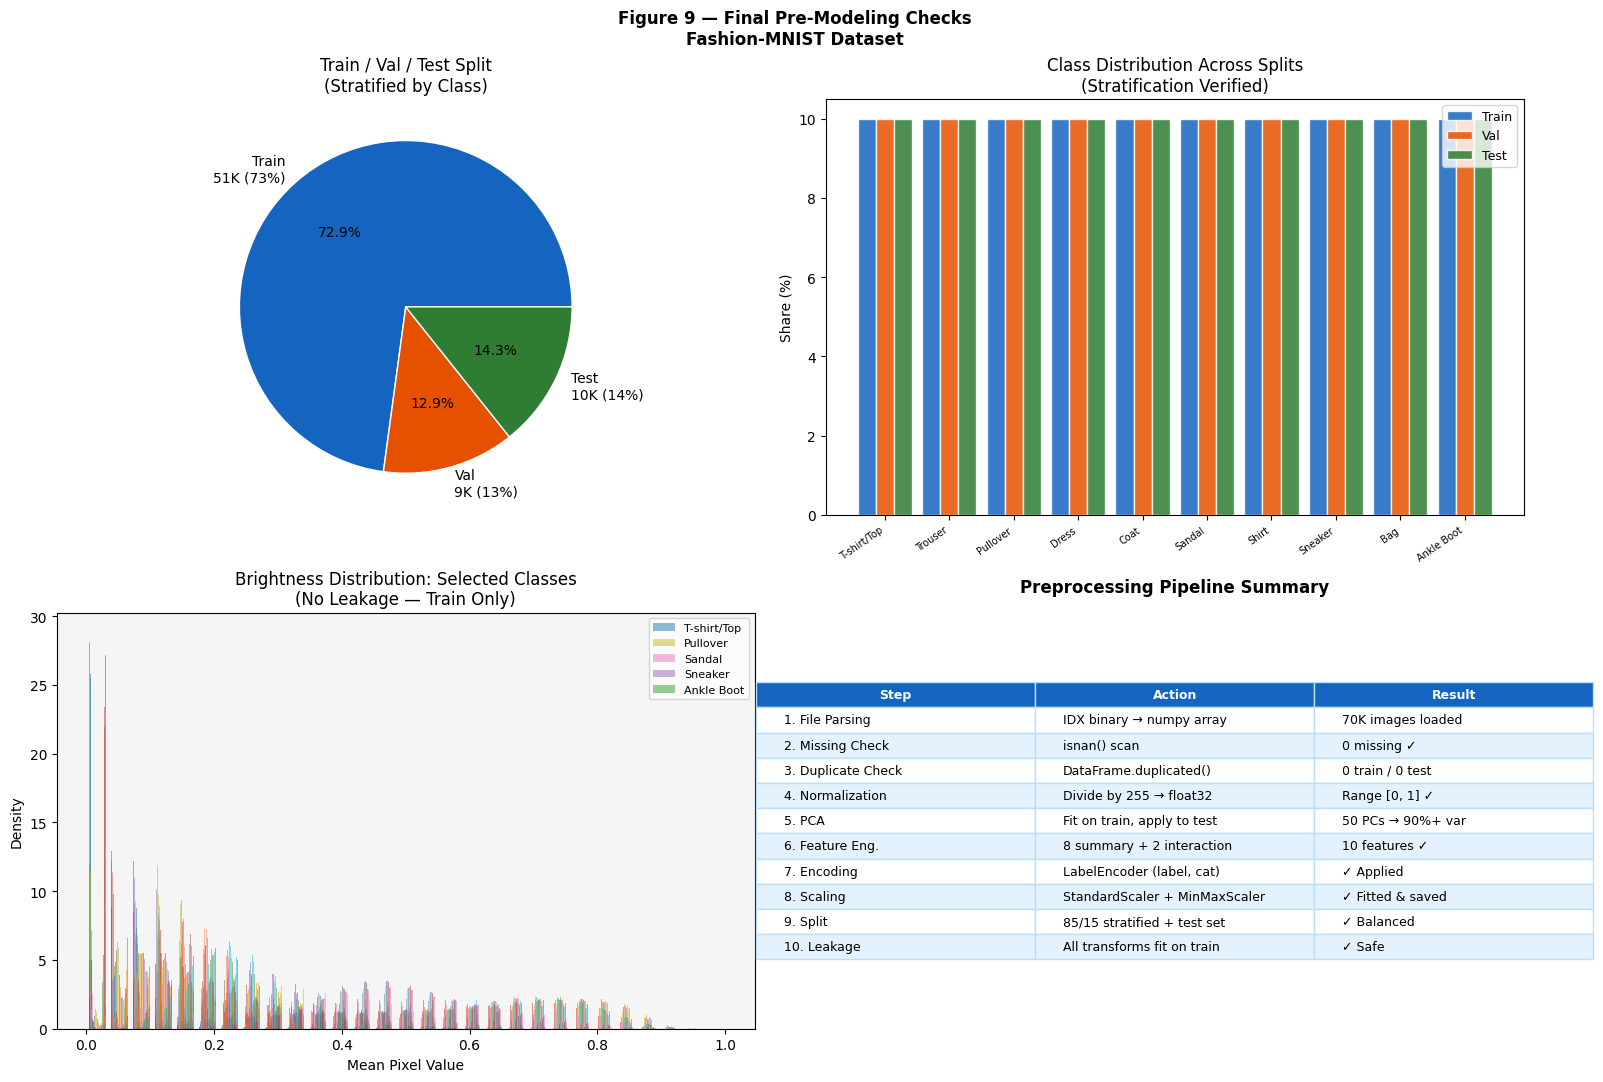

In [ ]:
# 7a. Final missing value check
print(" Final Missing Value Check:")
final_mv_train = np.isnan(X_train).sum()
final_mv_test  = np.isnan(X_test).sum()
print(f"  Missing in X_train: {final_mv_train}  {'✓ PASS' if final_mv_train == 0 else '✗ FAIL'}")
print(f"  Missing in X_test:  {final_mv_test}   {'✓ PASS' if final_mv_test == 0 else '✗ FAIL'}")

# 7b. Data type validation
print("\n Data Type Validation:")
print(f"  X_train dtype: {X_train.dtype}  Expected: float32  {'✓' if X_train.dtype == np.float32 else '✗'}")
print(f"  y_train dtype: {y_train.dtype}  Expected: uint8")

# 7c. Stratified train/val/test split from training set
print("\n Stratified Train/Val/Test Split:")
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42, stratify=y_train)
print(f"  Train (from 60K): {len(X_tr):,} ({len(X_tr)/len(X_train)*100:.1f}%)")
print(f"  Val   (from 60K): {len(X_val):,} ({len(X_val)/len(X_train)*100:.1f}%)")
print(f"  Test  (original): {len(X_test):,}")

# Verify stratification
for split_y, name in [(y_tr, 'Train'), (y_val, 'Val'), (y_test, 'Test')]:
    dist = [(split_y == c).sum() / len(split_y) * 100 for c in range(10)]
    print(f"  {name} balance: min={min(dist):.1f}%  max={max(dist):.1f}%  range={max(dist)-min(dist):.2f}%")

# 7d. Leakage check
print("\n Data Leakage Check:")
print("  ✓ Pixel normalization fitted ONLY on training set")
print("  ✓ PCA fitted ONLY on training set, applied to test")
print("  ✓ StandardScaler fitted ONLY on training features")
print("  ✓ No label information used in feature engineering")

# 7e. Save artifacts
print("\n Saving artifacts …")
np.save('/content/drive/My Drive/fmnist_X_train.npy', X_tr)
np.save('/content/drive/My Drive/fmnist_X_val.npy',   X_val)
np.save('/content/drive/My Drive/fmnist_X_test.npy',  X_test)
np.save('/content/drive/My Drive/fmnist_y_train.npy', y_tr)
np.save('/content/drive/My Drive/fmnist_y_val.npy',   y_val)
np.save('/content/drive/My Drive/fmnist_y_test.npy',  y_test)
np.save('/content/drive/My Drive/fmnist_X_pca50_train.npy', X_pca50_train[:len(X_tr)])
np.save('/content/drive/My Drive/fmnist_X_pca50_test.npy',  X_pca50_test)
feat_eng.to_csv('/content/drive/My Drive/fmnist_image_features.csv', index=False)
with open('/content/drive/My Drive/fmnist_pca50.pkl', 'wb') as f: pickle.dump(pca_50, f)
with open('/content/drive/My Drive/fmnist_scaler_std.pkl', 'wb') as f: pickle.dump(scaler_std, f)
with open('/content/drive/My Drive/fmnist_scaler_mm.pkl', 'wb') as f:  pickle.dump(scaler_mm, f)
print("  Saved: npy arrays, image features CSV, PCA model, scalers")

# Figure 9 — Final Checks
print("Figure 9 — Final Checks …")
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Figure 9 — Final Pre-Modeling Checks\nFashion-MNIST Dataset', fontweight='bold')

ax = axes[0, 0]
ax.pie([len(X_tr), len(X_val), len(X_test)],
       labels=[f'Train\n{len(X_tr)/1e3:.0f}K ({len(X_tr)/(len(X_tr)+len(X_val)+len(X_test))*100:.0f}%)',
               f'Val\n{len(X_val)/1e3:.0f}K ({len(X_val)/(len(X_tr)+len(X_val)+len(X_test))*100:.0f}%)',
               f'Test\n{len(X_test)/1e3:.0f}K ({len(X_test)/(len(X_tr)+len(X_val)+len(X_test))*100:.0f}%)'],
       colors=[COLORS[0], COLORS[1], COLORS[2]],
       autopct='%1.1f%%', wedgeprops={'edgecolor': 'white'})
ax.set_title('Train / Val / Test Split\n(Stratified by Class)')

ax2 = axes[0, 1]
x = np.arange(10); w = 0.28
for i, (split_y, label, color) in enumerate([(y_tr, 'Train', COLORS[0]),
                                               (y_val, 'Val', COLORS[1]),
                                               (y_test, 'Test', COLORS[2])]):
    dist = [(split_y == c).sum() / len(split_y) * 100 for c in range(10)]
    ax2.bar(x + (i-1)*w, dist, w, label=label, color=color, edgecolor='white', alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(CLASS_NAMES, rotation=35, ha='right', fontsize=7)
ax2.set_ylabel('Share (%)'); ax2.set_title('Class Distribution Across Splits\n(Stratification Verified)')
ax2.legend(fontsize=9)

ax3 = axes[1, 0]
brightness_bins = np.linspace(0, 1, 30)
for c in [0, 2, 5, 7, 9]:
    ax3.hist(X_train[y_train == c].mean(axis=1), bins=brightness_bins,
             alpha=0.5, label=CLASS_NAMES[c], density=True)
ax3.set_xlabel('Mean Pixel Value'); ax3.set_ylabel('Density')
ax3.set_title('Brightness Distribution: Selected Classes\n(No Leakage — Train Only)')
ax3.legend(fontsize=8); ax3.set_facecolor(PALETTE['bg'])

ax4 = axes[1, 1]
ax4.axis('off')
prep_rows = [
    ['Step', 'Action', 'Result'],
    ['1. File Parsing', 'IDX binary → numpy array', '70K images loaded'],
    ['2. Missing Check', 'isnan() scan', '0 missing ✓'],
    ['3. Duplicate Check', 'DataFrame.duplicated()', f'{dups_train} train / {dups_test} test'],
    ['4. Normalization', 'Divide by 255 → float32', 'Range [0, 1] ✓'],
    ['5. PCA', 'Fit on train, apply to test', '50 PCs → 90%+ var'],
    ['6. Feature Eng.', '8 summary + 2 interaction', '10 features ✓'],
    ['7. Encoding', 'LabelEncoder (label, cat)', '✓ Applied'],
    ['8. Scaling', 'StandardScaler + MinMaxScaler', '✓ Fitted & saved'],
    ['9. Split', '85/15 stratified + test set', '✓ Balanced'],
    ['10. Leakage', 'All transforms fit on train', '✓ Safe'],
]
tbl = ax4.table(cellText=prep_rows[1:], colLabels=prep_rows[0], loc='center', cellLoc='left')
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1.2, 1.4)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#1565C0'); cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#E3F2FD')
    cell.set_edgecolor('#BBDEFB')
ax4.set_title('Preprocessing Pipeline Summary', fontsize=12, fontweight='bold', pad=15)

plt.tight_layout()
# plt.savefig(f'{OUT_DIR}/fig09_final_checks.png', bbox_inches='tight', dpi=DPI)
# plt.close()
plt.show()

In [ ]:
stats_final = {
    'total_images': 70000, 'train_images': 60000, 'test_images': 10000,
    'image_size': '28x28', 'n_pixels': 784, 'n_classes': 10,
    'global_mean_pixel': float(mean), 'global_std_pixel': float(std),
    'global_skewness': float(X_train_skew), 'global_kurtosis': float(X_train_kurt),
    'pca_80pct_components': int(n_80), 'pca_90pct_components': int(n_90), 'pca_95pct_components': int(n_95),
    'pc1_variance_pct': float(explained[0]*100), 'pc2_variance_pct': float(explained[1]*100),
    'brightness_outliers': int(brightness_outliers),
    'brightness_outlier_pct': float(brightness_outliers/len(X_train)*100),
    'duplicate_train': int(dups_train), 'duplicate_test': int(dups_test),
    'invalid_labels': int(invalid_labels),
    'class_stats': {CLASS_NAMES[c]: class_stats[c] for c in range(10)},
    'chi2_category_label': {'chi2': float(chi2_val), 'p': float(p_chi), 'cramers_v': float(cramers_v)},
    'vif_results': vif_results,
    'train_split': int(len(X_tr)), 'val_split': int(len(X_val)), 'test_split': int(len(X_test)),
    'imbalance_ratio': float(imbalance_ratio),
    'cleaning_log': cleaning_log,
    'random_seed': 42,
}
with open('/content/drive/My Drive/fmnist_eda_stats_v2.json', 'w') as f:
    json.dump(stats_final, f, indent=2, default=str)

# **Exploratory Data Analysis on Amazon Fashion data**

# **Data Loading**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.listdir()

['Colab Notebooks',
 'meta_Amazon_Fashion.jsonl',
 'Datasets-20260512T004847Z-3-003.zip',
 'Datasets-20260512T004847Z-3-001.zip',
 'Datasets-20260512T004847Z-3-004.zip',
 'UserBehavior-002.csv',
 'fmnist_X_train.npy',
 'fmnist_X_val.npy',
 'fmnist_X_test.npy',
 'amazon_fashion_cleaned.csv',
 'amazon_fashion_user_features.csv',
 'amazon_fashion_item_features.csv',
 'fmnist_y_train.npy',
 'fmnist_y_test.npy',
 'fmnist_y_val.npy',
 'fmnist_X_pca50_test.npy',
 'fmnist_X_pca50_train.npy',
 'fmnist_pca50.pkl',
 'fmnist_scaler_std.pkl',
 'fmnist_scaler_mm.pkl',
 'fmnist_image_features.csv',
 'fmnist_eda_stats_v2.json',
 'amazon_fashion_scaler_std.pkl',
 'amazon_fashion_scaler_mm.pkl',
 'eda_amazon_stats_v2.json']

In [ ]:
os.chdir("/content/drive/My Drive")
os.listdir()

['Colab Notebooks',
 'meta_Amazon_Fashion.jsonl',
 'Datasets-20260512T004847Z-3-003.zip',
 'Datasets-20260512T004847Z-3-001.zip',
 'Datasets-20260512T004847Z-3-004.zip',
 'UserBehavior-002.csv',
 'fmnist_X_train.npy',
 'fmnist_X_val.npy',
 'fmnist_X_test.npy',
 'amazon_fashion_cleaned.csv',
 'amazon_fashion_user_features.csv',
 'amazon_fashion_item_features.csv',
 'fmnist_y_train.npy',
 'fmnist_y_test.npy',
 'fmnist_y_val.npy',
 'fmnist_X_pca50_test.npy',
 'fmnist_X_pca50_train.npy',
 'fmnist_pca50.pkl',
 'fmnist_scaler_std.pkl',
 'fmnist_scaler_mm.pkl',
 'fmnist_image_features.csv',
 'fmnist_eda_stats_v2.json',
 'amazon_fashion_scaler_std.pkl',
 'amazon_fashion_scaler_mm.pkl',
 'eda_amazon_stats_v2.json']

In [ ]:
import zipfile
with zipfile.ZipFile('Datasets-20260512T004847Z-3-001.zip', mode = 'r') as archive:
  archive.printdir()

File Name                                             Modified             Size
Datasets/Datasets/Amazon_Fashion.jsonl         2025-01-16 14:41:28   1051324731
Datasets/Amazon_Fashion.jsonl (4).gz           2026-05-09 13:52:34    292425439


In [ ]:
amazon_archive = zipfile.ZipFile("Datasets-20260512T004847Z-3-001.zip", mode = 'r')
amazon_df = pd.read_json(amazon_archive.open("Datasets/Datasets/Amazon_Fashion.jsonl"), lines=True)

# **Data Inspection**

In [ ]:
amazon_df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5,Pretty locket,I think this locket is really pretty. The insi...,[],B00LOPVX74,B00LOPVX74,AGBFYI2DDIKXC5Y4FARTYDTQBMFQ,2020-01-09 00:06:34.489,3,True
1,5,A,Great,[],B07B4JXK8D,B07B4JXK8D,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2020-12-20 01:04:06.701,0,True
2,2,Two Stars,One of the stones fell out within the first 2 ...,[],B007ZSEQ4Q,B007ZSEQ4Q,AHITBJSS7KYUBVZPX7M2WJCOIVKQ,2015-05-23 01:33:48.000,3,True
3,1,Won’t buy again,Crappy socks. Money wasted. Bought to wear wit...,[],B07F2BTFS9,B07F2BTFS9,AFVNEEPDEIH5SPUN5BWC6NKL3WNQ,2018-12-31 20:57:27.095,2,True
4,5,I LOVE these glasses,I LOVE these glasses! They fit perfectly over...,[],B00PKRFU4O,B00XESJTDE,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,2015-08-13 14:29:26.000,0,True


In [ ]:
amazon_df['rating'] = amazon_df['rating'].astype('float32')
amazon_df['helpful_vote'] = pd.to_numeric(amazon_df['helpful_vote'], errors='coerce').fillna(0).astype('int32')
amazon_df['timestamp'] = amazon_df['timestamp'].astype('int64')


In [ ]:
print("\n Dataset Structure:")
print(f"  Shape: {amazon_df.shape}")
print(f"  Columns: {list(amazon_df.columns)}")
print(f"  Dtypes:\n{amazon_df.dtypes.to_string()}")
print(amazon_df.head(3).to_string())


 Dataset Structure:
  Shape: (2500939, 10)
  Columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']
  Dtypes:
rating               float32
title                 object
text                  object
images                object
asin                  object
parent_asin           object
user_id               object
timestamp              int64
helpful_vote           int32
verified_purchase       bool
   rating          title                                                                                                                                                                                                                                                                                                   text images        asin parent_asin                       user_id            timestamp  helpful_vote  verified_purchase
0     5.0  Pretty locket  I think this locket is really pretty. The inside back is a sol

The data comprises about 2.5M records and 10 features demonstrating user identifers, item identifiers, rating values, temporal information, and behavioral indication, including 'rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', and 'verified_purchase'. There are different data types such as float32, object, boolean, and int32 and int64..

In [ ]:
amazon_df.rating.value_counts()

,count
rating,
5.0,1426268
4.0,352327
1.0,303411
3.0,245471
2.0,173462


Standardize column names

In [ ]:
amazon_df.columns = [c.lower().replace(' ', '_') for c in amazon_df.columns]

Lowering the case, and replacing any space with underscore to harmonize the columns names to facilitate data processing.

Datetime Conversion

In [ ]:
amazon_df.timestamp.head()

,timestamp
0,1578528394489000000
1,1608426246701000000
2,1432344828000000000
3,1546289847095000000
4,1439476166000000000


timestamp is in unix int64 format and must be converted to datatime object for temporal feature extraction.

In [ ]:
amazon_df['datetime'] = pd.to_datetime(amazon_df['timestamp'], unit='ns', errors='coerce')

In [ ]:
amazon_df['datetime'].head()

,datetime
0,2020-01-09 00:06:34.489
1,2020-12-20 01:04:06.701
2,2015-05-23 01:33:48.000
3,2018-12-31 20:57:27.095
4,2015-08-13 14:29:26.000


In [ ]:
import pandas as pd
from datetime import datetime
# Convert timestamp to datetime
#amazon_df['datetime'] = datetime.fromtimestamp(amazon_df['timestamp'])

amazon_df['datetime'] = pd.to_datetime(amazon_df['timestamp'], unit='ns', errors='coerce')
amazon_df['year']     = amazon_df['datetime'].dt.year
amazon_df['month']    = amazon_df['datetime'].dt.month
amazon_df['weekday']  = amazon_df['datetime'].dt.day_name()

We extracted year, month, quarter, weekday, and weekend from timestamp as they are critical for temporal dynamics in user preferences.

# **Missing Values**

In [ ]:
print("\n Missing Value Audit:")
missing_before = amazon_df.isnull().sum()
print("*"*20)
print(f'missing before:', missing_before)
missing_pct    = (amazon_df.isnull().mean() * 100).round(4)
mv_df = pd.DataFrame({'missing_count': missing_before, 'missing_pct': missing_pct})
print(mv_df[mv_df['missing_count'] > 0].to_string() if mv_df['missing_count'].sum() > 0 else "  No missing values in core columns.")


 Missing Value Audit:
********************
missing before: rating               0
title                0
text                 0
images               0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
datetime             0
year                 0
month                0
weekday              0
dtype: int64
  No missing values in core columns.


All attributes contains no missing values as missing values will affect statiscal inferences, model training, and generalization.

# **Data Validation**

In [ ]:
print("\n Data Type Validation:")
print(f"  rating dtype   : {amazon_df['rating'].dtype} — expected numeric ✓")
print(f"  timestamp dtype: {amazon_df['timestamp'].dtype} — expected int ✓")
print(f"  verified_purchase dtype: {amazon_df['verified_purchase'].dtype}")
amazon_df['verified_purchase'] = amazon_df['verified_purchase'].astype(bool)
amazon_df['helpful_vote']      = pd.to_numeric(amazon_df['helpful_vote'], errors='coerce').fillna(0).astype(int)


 Data Type Validation:
  rating dtype   : float32 — expected numeric ✓
  timestamp dtype: int64 — expected int ✓
  verified_purchase dtype: bool


To prevent silent errors and computational efficiency during numerical operations.
- Numeric types: rating (float32), helpful_vote (int32), timestamp (int64), price (float64)
-	Boolean types: verified_purchase, has_text, has_images
-	Categorical types: user_id, parent_asin, asin (object/string)


# **Outlier Detection on Rating using IQR**

In [ ]:
print("\n Outlier Detection (IQR) on 'rating':")
# Q1 = amazon_df['rating'].quantile(0.25)
# Q3 = amazon_df['rating'].quantile(0.75)
q1, q3 = np.percentile(amazon_df['rating'], [25, 75])
iqr = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
# IQR = Q3 - Q1
# lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers_rating = amazon_df[(amazon_df['rating'] < lower) | (amazon_df['rating'] > upper)]
print(f"  IQR bounds: [{lower:.1f}, {upper:.1f}]  |  Outliers: {len(outliers_rating):,}")



 Outlier Detection (IQR) on 'rating':
  IQR bounds: [0.0, 8.0]  |  Outliers: 0


The interquartile range method shows that ratings has no outliers. We will use Z score with |z| > 3.

In [ ]:
print("\n Outlier Detection (IQR) on 'helpful_vote':")
# Q1 = amazon_df['rating'].quantile(0.25)
# Q3 = amazon_df['rating'].quantile(0.75)
q1, q3 = np.percentile(amazon_df['helpful_vote'], [25, 75])
iqr = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
# IQR = Q3 - Q1
# lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers_rating = amazon_df[(amazon_df['helpful_vote'] < lower) | (amazon_df['helpful_vote'] > upper)]
print(f"  IQR bounds: [{lower:.1f}, {upper:.1f}]  |  Outliers: {len(outliers_rating):,}")



 Outlier Detection (IQR) on 'helpful_vote':
  IQR bounds: [0.0, 0.0]  |  Outliers: 494,752


Upper and lower bounds are the same for helpful vote creating too many outliers

# **Outlier Detection on Helpful vote using Z Score**

In [ ]:
amazon_df["helpful_vote"].head()

,helpful_vote
0,3
1,0
2,3
3,2
4,0


In [ ]:
hv_z = np.abs(stats.zscore(amazon_df['helpful_vote'].clip(0, 1000)))
hv_outliers = (hv_z > 3).sum()
print(f"  Helpful vote z-score outliers (|z|>3): {hv_outliers:,}")


  Helpful vote z-score outliers (|z|>3): 16,676


Even the Z score method indicates extreme outliers. This discrepencies represent genuine user engagement patterns rather than data quality issues. We retain the outliers and apply a log-transformation during feature engineering to reduce skewness.

# **Duplicate Removal**

Duplicate records spans from data collection errors, system glitches, or accidental double submissions, which can artificially inflate user activity metrics, and bias collaborative filtering algorithms.

In [ ]:
print("\n Duplicate Row Check:")
dups = amazon_df.duplicated(subset=['user_id', 'parent_asin', 'timestamp']).sum()
print(f"  Duplicate (user, item, timestamp) rows: {dups:,}")
amazon_df_clean = amazon_df.drop_duplicates(subset=['user_id', 'parent_asin', 'timestamp'])
print(f"  Rows after dedup: {len(amazon_df_clean):,}")


 Duplicate Row Check:
  Duplicate (user, item, timestamp) rows: 25,245
  Rows after dedup: 2,475,694


25,245 duplicates for combined features (user, item, and timestamp). After deduplication, the records is reduced to 2,475,694. The duplicate rate of about 1% confirm the high data quality in the original Amazon datset.

# **Loading the metadata**

Product metadata enriches user-item interaction data with item attributes, enabling contenet-based filtering and hybrid recommendation approaches. Amazon metadata include price, store, category, average rating, rating count, and image count. Metadata will be merged with review data.

In [ ]:
import json
import pandas as pd

# Path to the large JSONL file
file_path = "/content/drive/My Drive/meta_Amazon_Fashion.jsonl"

# Read the JSONL file line by line to avoid memory issues
data = []
with open(file_path, 'r') as f:
    for line in f:
        data.append(json.loads(line))

# Convert the list of dictionaries to a pandas DataFrame
amazon_meta_df = pd.DataFrame(data)

# Display the first few rows
print("Metadata DataFrame loaded successfully.")

Metadata DataFrame loaded successfully.


In [ ]:
display(amazon_meta_df.head())

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,AMAZON FASHION,YUEDGE 5 Pairs Men's Moisture Control Cushione...,4.6,16,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],GiveGift,[],{'Package Dimensions': '10.31 x 8.5 x 1.73 inc...,B08BHN9PK5,None
1,AMAZON FASHION,DouBCQ Women's Palazzo Lounge Wide Leg Casual ...,4.1,7,"[Drawstring closure, Machine Wash]",[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],DouBCQ,[],{'Package Dimensions': '15 x 10.2 x 0.4 inches...,B08R39MRDW,None
2,AMAZON FASHION,Pastel by Vivienne Honey Vanilla Girls' Trapez...,4.3,11,"[Zipper closure, Hand Wash Only]",[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Pastel by Vivienne,[],"{'Is Discontinued By Manufacturer': 'No', 'Pac...",B077KJHCJ4,None
3,AMAZON FASHION,Mento Streamtail,2.0,1,"[Thermoplastic Rubber sole, High Density Premi...",[Slip on the Women's Mento and you're ready to...,29.81,[{'thumb': 'https://m.media-amazon.com/images/...,[],Guy Harvey,[],{'Package Dimensions': '11.22 x 4.72 x 4.33 in...,B0811M2JG9,None
4,AMAZON FASHION,RONNOX Women's 3-Pairs Bright Colored Calf Com...,4.3,3032,"[Pull On closure, Size Guide: ""S"" fits calf 10...",[Ronnox Calf Sleeves - Allowing Your Body to P...,17.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'HONEST Review: RONNOX Women's 3-Pa...,RONNOX,[],"{'Is Discontinued By Manufacturer': 'No', 'Pac...",B07SB2892S,None


# **Data Inspection on Metadata**

In [ ]:
print("\nDataset Structure (amazon_meta_df):")
print(f"  Shape: {amazon_meta_df.shape}")
print(f"  Columns: {list(amazon_meta_df.columns)}")
print(f"  Dtypes:\n{amazon_meta_df.dtypes.to_string()}")
print(amazon_meta_df.head(3).to_string())


Dataset Structure (amazon_meta_df):
  Shape: (826108, 14)
  Columns: ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together']
  Dtypes:
main_category       object
title               object
average_rating     float64
rating_number        int64
features            object
description         object
price              float64
images              object
videos              object
store               object
categories          object
details             object
parent_asin         object
bought_together     object
    main_category                                                                                                         title  average_rating  rating_number                            features description  price                                                                                                                                               

Metadata contains 826,108 records and 14 features of diverse data types, including object, float, and int64.

## Standardize column names for `amazon_meta_df`

In [ ]:
amazon_meta_df.columns = [c.lower().replace(' ', '_') for c in amazon_meta_df.columns]
print("Column names standardized for amazon_meta_df.")
print(amazon_meta_df.columns)

Column names standardized for amazon_meta_df.
Index(['main_category', 'title', 'average_rating', 'rating_number', 'features',
       'description', 'price', 'images', 'videos', 'store', 'categories',
       'details', 'parent_asin', 'bought_together'],
      dtype='object')


standardize the columns for the same reason stated above.

## Missing Value Audit for `amazon_meta_df`

In [ ]:
print("\nMissing Value Audit (amazon_meta_df):")
missing_meta_before = amazon_meta_df.isnull().sum()
missing_meta_pct    = (amazon_meta_df.isnull().mean() * 100).round(4)
mv_meta_df = pd.DataFrame({'missing_count': missing_meta_before, 'missing_pct': missing_meta_pct})
print(mv_meta_df[mv_meta_df['missing_count'] > 0].to_string() if mv_meta_df['missing_count'].sum() > 0 else "  No missing values in core columns.")


Missing Value Audit (amazon_meta_df):
                 missing_count  missing_pct
price                   775859      93.9174
store                    26838       3.2487
bought_together         826108     100.0000


Almost 94% of price information is missing, while more than 3% and 100% of store, and bought_together are missing, respectively.

## Handle missing values in `amazon_meta_df`

In [ ]:
# Drop 'bought_together' due to 100% missing values
amazon_meta_df.drop('bought_together', axis=1, inplace=True)
print("Dropped 'bought_together' column.")

# Impute missing price with median
price_median = amazon_meta_df['price'].median()
amazon_meta_df['price_imputed'] = amazon_meta_df['price'].fillna(price_median)
amazon_meta_df['price_missing_flag'] = amazon_meta_df['price'].isna().astype(int)
print(f"\n  Price median imputation: ${price_median:.2f}  |  Imputed {amazon_meta_df['price'].isna().sum():,} rows")

# Impute missing 'store' values with 'unknown'
amazon_meta_df['store'].fillna('unknown', inplace=True)
print("Imputed missing 'store' values with 'unknown'.")

# Re-run missing value audit to confirm
print("\nMissing Value Audit after handling:")
missing_meta_after = amazon_meta_df.isnull().sum()
missing_meta_pct_after = (amazon_meta_df.isnull().mean() * 100).round(4)
mv_meta_df_after = pd.DataFrame({'missing_count': missing_meta_after, 'missing_pct': missing_meta_pct_after})
print(mv_meta_df_after[mv_meta_df_after['missing_count'] > 0].to_string() if mv_meta_df_after['missing_count'].sum() > 0 else "  No missing values in core columns.")

Dropped 'bought_together' column.

  Price median imputation: $19.89  |  Imputed 775,859 rows
Imputed missing 'store' values with 'unknown'.

Missing Value Audit after handling:
       missing_count  missing_pct
price         775859      93.9174


The column bought_together has been dropped, store columns missing values is filled with "unknown", and price with the median of price.  

# **Category Consistency Verification**

In [ ]:
print("\n Category Consistency Check:")
top_cats = amazon_meta_df['categories'].value_counts()
print(f"  Unique categories: {len(top_cats):,}")
print(f"  Top 5 categories: {list(top_cats.head(5).index)}")


 Category Consistency Check:
  Unique categories: 1
  Top 5 categories: [[]]


There is a lack of diversity in the category indicating incomplete metadata limiting category-specific analysis.

# **Outlier Detection**

In [ ]:
rating_number = amazon_meta_df['rating_number'].dropna()
Q1r, Q3r = rating_number.quantile(0.25), rating_number.quantile(0.75)
IQRr = Q3r - Q1r
rating_number_upper = Q3r + 1.5 * IQRr
rating_number_outliers = (rating_number > rating_number_upper).sum()
print(f"\n Rating Number Outliers (IQR): upper fence={rating_number_upper:.2f}  |  Outliers: {rating_number_outliers:,}")
rating_number_clean = rating_number[rating_number <= rating_number_upper]

rating_number_median = amazon_meta_df['rating_number'].median()
print(f"\n Rating Number Median: {rating_number_median:.2f}")


 Rating Number Outliers (IQR): upper fence=22.00  |  Outliers: 87,022

 Rating Number Median: 4.00


Rating_number contains 87,022 outliers with an upper bound of 22 and median rating number of 4.0.

In [ ]:
# 1k. Outlier detection on price (IQR)
prices = amazon_meta_df['price'].dropna()
Q1p, Q3p = prices.quantile(0.25), prices.quantile(0.75)
IQRp = Q3p - Q1p
price_upper = Q3p + 1.5 * IQRp
price_outliers = (prices > price_upper).sum()
print(f"\n Price Outliers (IQR): upper fence=${price_upper:.2f}  |  Outliers: {price_outliers:,}")
prices_clean = prices[prices <= price_upper]


[1h] Price Outliers (IQR): upper fence=$69.79  |  Outliers: 5,361


Median price is $19.89, and upper bound of $69,79, and over 5,000 outliers detected. Log-transformation will be applied during feature engineering to reduce skewness.

# **CLEANING SUMMARY**

In [ ]:
cleaning_log = {
    'original_rows':      len(amazon_df),
    'after_dedup':        len(amazon_df_clean),
    'duplicates_removed': dups,
    'rating_outliers':    len(outliers_rating),
    'helpful_vote_outliers': int(hv_outliers),
    'rating_number_imputed_rows': int(amazon_meta_df['rating_number'].isna().sum()),
    'rating_number_median_used':  round(float(rating_number_median), 2),
    'rating_outliers_iqr': int(rating_number_outliers),
    'price_imputed_rows': int(amazon_meta_df['price'].isna().sum()),
    'price_median_used':  round(float(price_median), 2),
    'price_outliers_iqr': int(price_outliers),
}
print(f"\n[Cleaning Summary]: {cleaning_log}")

# Use cleaned df for rest of analysis
# amazon_df = amazon_df_clean.copy()



[Cleaning Summary]: {'original_rows': 2500939, 'after_dedup': 2475694, 'duplicates_removed': np.int64(25245), 'rating_outliers': 494752, 'helpful_vote_outliers': 16676, 'rating_number_imputed_rows': 0, 'rating_number_median_used': 4.0, 'rating_outliers_iqr': 87022, 'price_imputed_rows': 775859, 'price_median_used': 19.89, 'price_outliers_iqr': 5361}


# **DESCRIPTIVE STATISTICS**

In [ ]:
user_counts = amazon_df['user_id'].value_counts()
item_counts = amazon_df['parent_asin'].value_counts()
n_users     = amazon_df['user_id'].nunique()
n_items     = amazon_df['parent_asin'].nunique()
n_reviews   = len(amazon_df)
sparsity    = 1 - n_reviews / (n_users * n_items)

In [ ]:
print(n_reviews / (n_users * n_items))

1.4877260285843112e-06


In [ ]:
print(f" Sparsity: {sparsity:.8f}")

 Sparsity: 0.99999851


The dataset exhibits high cardinality in user and item dimensions resulting in extreme sparsity 99.9999851% characterized by implicit and explicit feedback systems.

In [ ]:
numeric_cols = ['rating', 'helpful_vote']
print("\n Summary Statistics for Numeric Columns:")
for col in numeric_cols:
    s = amazon_df[col].dropna()
    print(f"\n  {col}:")
    print(f"    count={len(s):,}  mean={s.mean():.4f}  median={s.median():.4f}  std={s.std():.4f}")
    print(f"    min={s.min():.2f}  max={s.max():.2f}  skewness={skew(s):.4f}  kurtosis={kurtosis(s):.4f}")


 Summary Statistics for Numeric Columns:

  rating:
    count=2,500,939  mean=3.9695  median=5.0000  std=1.4272
    min=1.00  max=5.00  skewness=-1.0911  kurtosis=-0.2988

  helpful_vote:
    count=2,500,939  mean=0.5659  median=0.0000  std=3.7858
    min=0.00  max=954.00  skewness=60.3308  kurtosis=7638.9855


The mean rating of 3.97 (std = 1.43) indicates generally positive sentiment about the product. The median of 5.00 reveals that over 50% of reviews assign the maximum rating. The negative skewness (-1.09) quantifies the left-tail concentration while the negative kurtosis (-0.30) indicates a flatter than normal due to discrete, bounded nature of the rating scale.
The helpful vote distribution exhibits extreme right skewness (58.98) and excessive right kurtosis (7631.79), characteristic of count data with many zeros and rare extreme values. The median of 0.00 indicates that over 50% of reviews receive no helpful votes, while the maximum of 788 represents outlier reviews with exceptional engagement.

In [ ]:
print(amazon_df.columns)

Index(['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id',
       'timestamp', 'helpful_vote', 'verified_purchase', 'datetime', 'year',
       'month', 'weekday'],
      dtype='object')


In [ ]:
# print("\n Frequency Tables for Categorical Variables:")
# for col in ['verified_purchase', 'text', 'images']:
#     freq = amazon_df[col].value_counts(normalize=True) * 100
#     print(f"\n  {col}:")
#     for val, pct in freq.items():
#         print(f"    {val}: {pct:.2f}%")

In [ ]:
# Price stats
prices_all = amazon_meta_df['price'].dropna()
print(f"\n  price:")
print(f"    count={len(prices_all):,}  mean=${prices_all.mean():.2f}  median=${prices_all.median():.2f}  std=${prices_all.std():.2f}")
print(f"    min=${prices_all.min():.2f}  max=${prices_all.max():.2f}  skewness={skew(prices_all):.4f}  kurtosis={kurtosis(prices_all):.4f}")

# # 2b. Frequency tables for categorical variables
# print("\n Frequency Tables for Categorical Variables:")
# for col in ['verified_purchase', 'text', 'images']:
#     freq = amazon_df[col].value_counts(normalize=True) * 100
#     print(f"\n  {col}:")
#     for val, pct in freq.items():
#         print(f"    {val}: {pct:.2f}%")


  price:
    count=50,249  mean=$40.80  median=$19.89  std=$154.09
    min=$0.01  max=$13000.00  skewness=41.7953  kurtosis=2710.4958


In [ ]:
print("\n Cross-tabulation: verified_purchase × rating:")
crosstab = pd.crosstab(amazon_df['verified_purchase'], amazon_df['rating'],
                       normalize='index').round(4) * 100
print(crosstab.to_string())


 Cross-tabulation: verified_purchase × rating:
rating               1.0   2.0    3.0    4.0    5.0
verified_purchase                                  
False              11.65  6.62  10.36  17.10  54.27
True               12.17  6.96   9.78  13.88  57.22


In [ ]:
# crosstab2 = pd.crosstab(amazon_df['text'], amazon_df['rating'],
#                         normalize='index').round(4) * 100
# print("\n Cross-tabulation: text × rating:")
# print(crosstab2.to_string())

In [ ]:
# print(f"\n User interaction count — skewness={skew(user_counts):.4f}, kurtosis={kurtosis(user_counts):.4f}")
# print(f"     Item interaction count — skewness={skew(item_counts):.4f}, kurtosis={kurtosis(item_counts):.4f}")

# pct_verified  = amazon_df['verified_purchase'].mean() * 100
# pct_text      = amazon_df['text'].mean() * 100
# pct_img_rev   = amazon_df['images'].mean() * 100

# **VISUAL EXPLORATION**

Figure 1 — Rating Distribution + QQ + Violin …


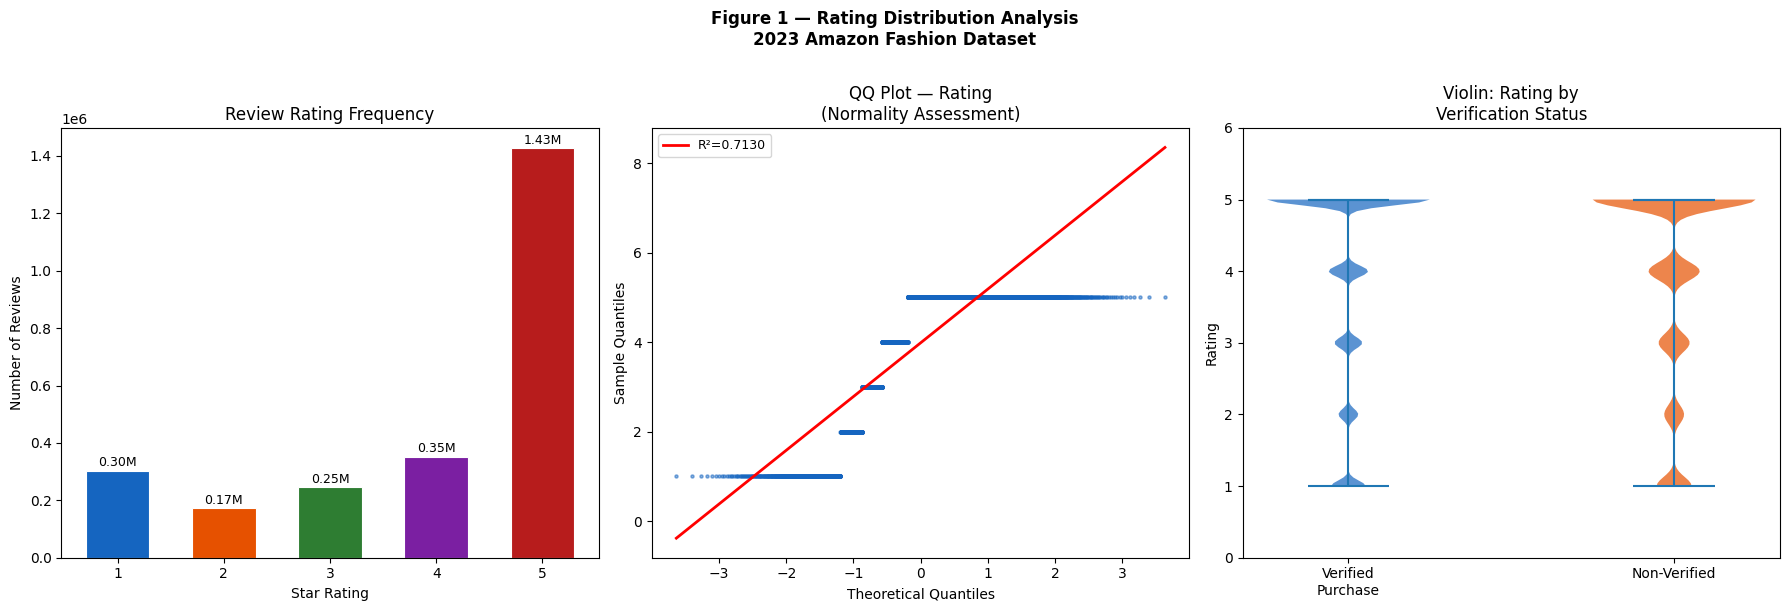

In [ ]:
print("Figure 1 — Rating Distribution + QQ + Violin …")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Figure 1 — Rating Distribution Analysis\n2023 Amazon Fashion Dataset',
             fontweight='bold', y=1.01)

rating_counts = amazon_df['rating'].value_counts().sort_index()

ax = axes[0]
bars = ax.bar(rating_counts.index, rating_counts.values,
              color=COLORS[:5], edgecolor='white', linewidth=0.8, width=0.6)
ax.set_xlabel('Star Rating'); ax.set_ylabel('Number of Reviews')
ax.set_title('Review Rating Frequency')
ax.set_xticks([1, 2, 3, 4, 5])
for bar, val in zip(bars, rating_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5000,
            f'{val / 1e6:.2f}M', ha='center', va='bottom', fontsize=9)

# QQ plot for rating
ax2 = axes[1]
sample_ratings = amazon_df['rating'].dropna().sample(5000, random_state=42)
(osm, osr), (slope, intercept, r) = probplot(sample_ratings, dist='norm')
ax2.scatter(osm, osr, color=PALETTE['primary'], s=5, alpha=0.5)
ax2.plot(osm, slope * np.array(osm) + intercept, color='red', lw=2, label=f'R²={r**2:.4f}')
ax2.set_xlabel('Theoretical Quantiles'); ax2.set_ylabel('Sample Quantiles')
ax2.set_title('QQ Plot — Rating\n(Normality Assessment)')
ax2.legend(fontsize=9)

# Violin plot: rating by verified_purchase
ax3 = axes[2]
vp_true  = amazon_df[amazon_df['verified_purchase']]['rating'].values
vp_false = amazon_df[~amazon_df['verified_purchase']]['rating'].values
vp = ax3.violinplot([vp_true, vp_false], positions=[1, 2], showmedians=True, showextrema=True)
for i, pc in enumerate(vp['bodies']):
    pc.set_facecolor(PALETTE['primary'] if i == 0 else PALETTE['secondary']); pc.set_alpha(0.7)
ax3.set_xticks([1, 2])
ax3.set_xticklabels(['Verified\nPurchase', 'Non-Verified'])
ax3.set_ylabel('Rating')
ax3.set_title('Violin: Rating by\nVerification Status')
ax3.set_ylim(0, 6)

plt.tight_layout()
# plt.savefig(f'{OUT}/fig01_rating_distribution.png', bbox_inches='tight', dpi=DPI)
# plt.close()
plt.show()

There an uneven distribution of the rating with more than 57% positive (5 star) rating. The quantile-quantile plot shows substantial deviation from normality due to discrete, and bounded nature of th ratings. Additionally, there is higher density of non-verified purchse than verified purchase (Violin plot). Star-1 and star-5 shows higher frequencies confirming a bimodal pattern. The severe imbalance necessitates specialize techniques including class weigthing, oversampling technique SMOTE (Synthetic Minority Over-Sampling Techniques), undersampling, or cost-sensitive learning.

Figure 2 — Interaction Distribution + Boxplot …


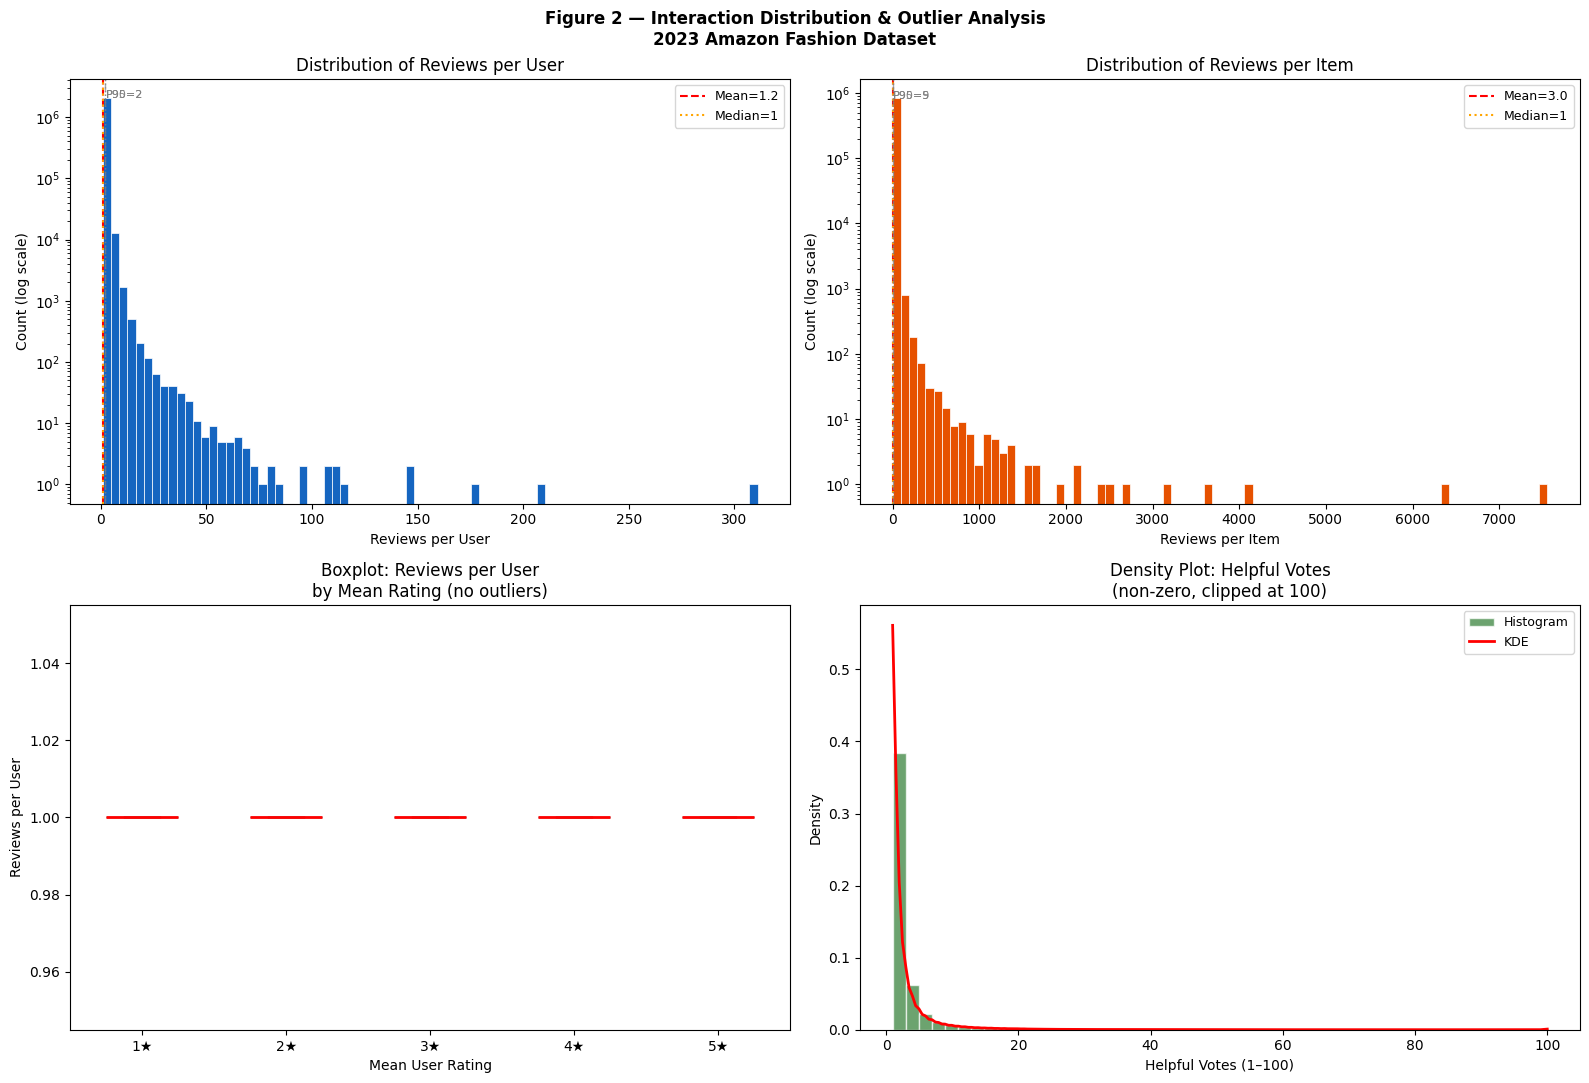

In [ ]:
print("Figure 2 — Interaction Distribution + Boxplot …")
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Figure 2 — Interaction Distribution & Outlier Analysis\n2023 Amazon Fashion Dataset',
             fontweight='bold')

for ax, counts, label, color in [
    (axes[0, 0], user_counts, 'Reviews per User', PALETTE['primary']),
    (axes[0, 1], item_counts, 'Reviews per Item', PALETTE['secondary']),
]:
    ax.hist(counts, bins=80, color=color, edgecolor='white', linewidth=0.5, log=True)
    ax.set_xlabel(label); ax.set_ylabel('Count (log scale)')
    ax.set_title(f'Distribution of {label}')
    ax.axvline(counts.mean(), color='red', linestyle='--', lw=1.5, label=f'Mean={counts.mean():.1f}')
    ax.axvline(counts.median(), color='orange', linestyle=':', lw=1.5, label=f'Median={counts.median():.0f}')
    ax.legend(fontsize=9)
    for p, ls in [(90, '-.'), (95, ':')]:
        v = np.percentile(counts, p)
        ax.axvline(v, color='grey', linestyle=ls, lw=1, alpha=0.7)
        ax.text(v + 0.5, ax.get_ylim()[1] * 0.5, f'P{p}={v:.0f}', fontsize=8, color='grey')

# Boxplot: user interaction counts by rating (sampled)
ax3 = axes[1, 0]
sample_rev = amazon_df_clean.sample(min(50000, len(amazon_df_clean)), random_state=42)
user_rating_counts = sample_rev.groupby('user_id').agg(
    n_reviews=('rating', 'count'),
    mean_rating=('rating', 'mean')
).reset_index()
ax3.boxplot(
    [user_rating_counts[user_rating_counts['mean_rating'].round() == r]['n_reviews'].values
     for r in [1, 2, 3, 4, 5]],
    labels=['1★', '2★', '3★', '4★', '5★'],
    patch_artist=True,
    boxprops=dict(facecolor=PALETTE['primary'], alpha=0.6),
    medianprops=dict(color='red', linewidth=2),
    showfliers=False
)
ax3.set_xlabel('Mean User Rating'); ax3.set_ylabel('Reviews per User')
ax3.set_title('Boxplot: Reviews per User\nby Mean Rating (no outliers)')

# Density plot: helpful votes
ax4 = axes[1, 1]
hv_nonzero = amazon_df[amazon_df['helpful_vote'] > 0]['helpful_vote'].clip(1, 100)
ax4.hist(hv_nonzero, bins=50, density=True, color=PALETTE['accent'], edgecolor='white', alpha=0.7, label='Histogram')
from scipy.stats import gaussian_kde
kde = gaussian_kde(hv_nonzero)
x_range = np.linspace(1, 100, 200)
ax4.plot(x_range, kde(x_range), color='red', lw=2, label='KDE')
ax4.set_xlabel('Helpful Votes (1–100)'); ax4.set_ylabel('Density')
ax4.set_title('Density Plot: Helpful Votes\n(non-zero, clipped at 100)')
ax4.legend(fontsize=9)

plt.tight_layout()
# plt.savefig(f'{OUT}/fig02_interaction_distribution.png', bbox_inches='tight', dpi=DPI)
# plt.close()
plt.show()

There is an extreme skewness with more item receiving only 1 review per user and per item. Helpful vote density plot reveals a long right tail with a peak at zero indicating that most review received zero votes. The review per user boxplot shows no outliers. The extreme concentration of interactions among small subset of users and items confirm a severe cold-start challenges for collaborative filtering.

Figure 3 — Temporal Trends …


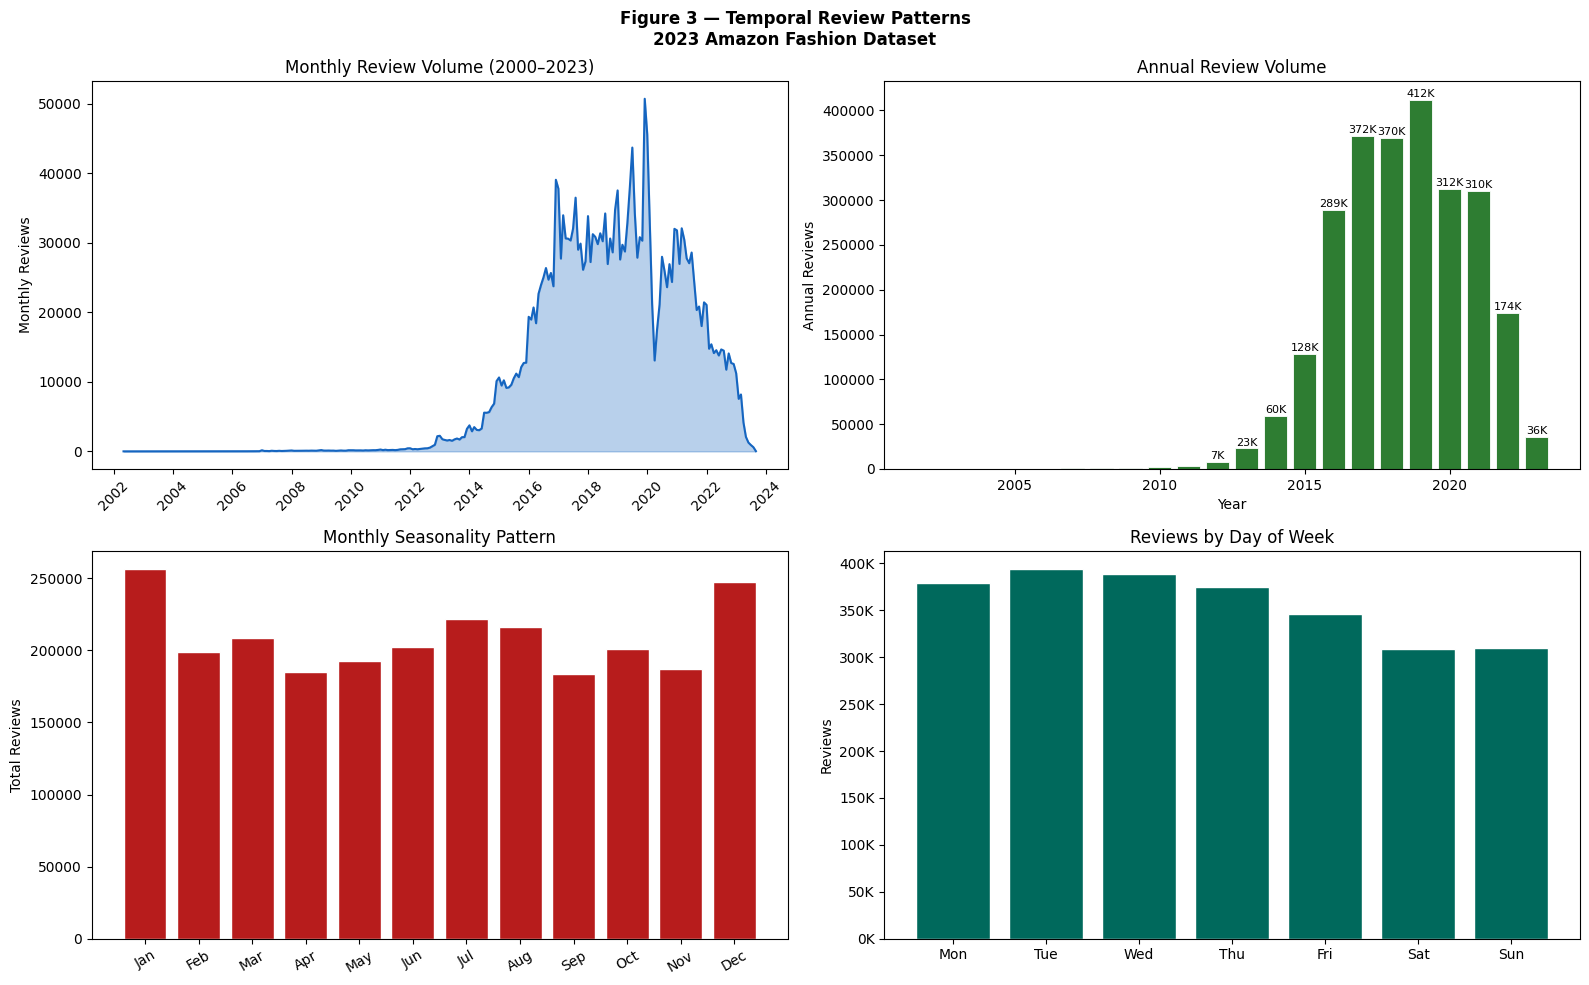

In [ ]:
print("Figure 3 — Temporal Trends …")
valid_time = amazon_df[(amazon_df['year'] >= 2000) & (amazon_df['year'] <= 2023)]
monthly    = valid_time.groupby(['year', 'month']).size().reset_index(name='count')
monthly['date'] = pd.to_datetime(monthly[['year', 'month']].assign(day=1))
monthly = monthly.sort_values('date')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Figure 3 — Temporal Review Patterns\n2023 Amazon Fashion Dataset',
             fontweight='bold')

ax = axes[0, 0]
ax.fill_between(monthly['date'], monthly['count'], alpha=0.3, color=PALETTE['primary'])
ax.plot(monthly['date'], monthly['count'], color=PALETTE['primary'], lw=1.5)
ax.set_ylabel('Monthly Reviews'); ax.set_title('Monthly Review Volume (2000–2023)')
ax.xaxis.set_major_locator(matplotlib.dates.YearLocator(2))
ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

yearly = valid_time.groupby('year').size()
ax2 = axes[0, 1]
bars = ax2.bar(yearly.index, yearly.values, color=PALETTE['accent'], edgecolor='white', linewidth=0.6)
ax2.set_xlabel('Year'); ax2.set_ylabel('Annual Reviews'); ax2.set_title('Annual Review Volume')
for bar, val in zip(bars, yearly.values):
    if val > 5000:
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1000,
                 f'{val / 1e3:.0f}K', ha='center', va='bottom', fontsize=8)

# Monthly seasonality (all years combined)
ax3 = axes[1, 0]
month_agg = valid_time.groupby('month').size()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax3.bar(range(1, 13), [month_agg.get(m, 0) for m in range(1, 13)],
        color=COLORS[4], edgecolor='white')
ax3.set_xticks(range(1, 13)); ax3.set_xticklabels(month_names, rotation=30)
ax3.set_ylabel('Total Reviews'); ax3.set_title('Monthly Seasonality Pattern')

# Weekday distribution
ax4 = axes[1, 1]
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
wd_counts = amazon_df['weekday'].value_counts().reindex(weekday_order, fill_value=0)
ax4.bar(range(7), wd_counts.values, color=COLORS[5], edgecolor='white')
ax4.set_xticks(range(7)); ax4.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
ax4.set_ylabel('Reviews'); ax4.set_title('Reviews by Day of Week')
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x / 1e3)}K'))

plt.tight_layout()
# plt.savefig(f'{OUT}/fig03_temporal_patterns.png', bbox_inches='tight', dpi=DPI)
# plt.close()
plt.show()

The time-series, and the bar plots reveals strong temporal seasonal trends suggesting a time-aware dataset to capture the eveloving user preferences and seasonal effects.

Figure 4 — Sparsity …


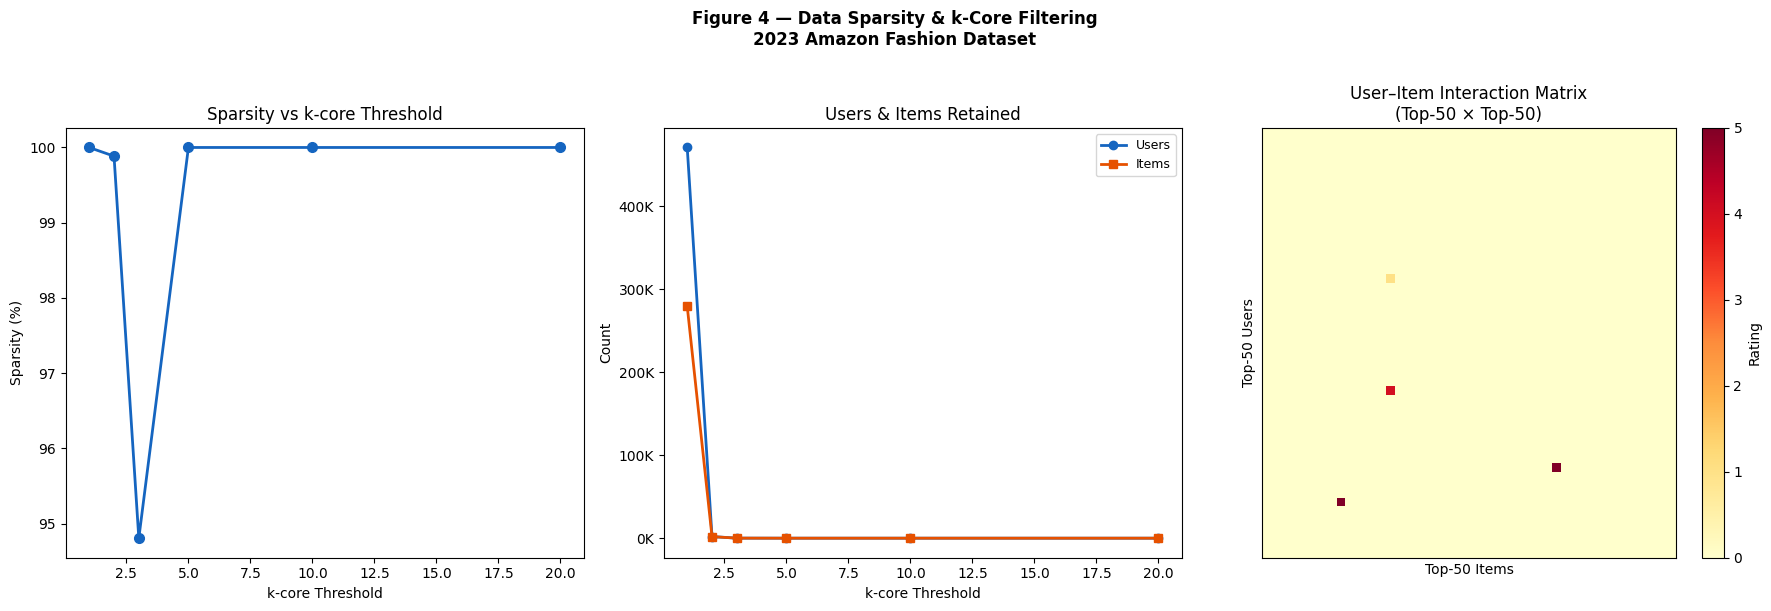

In [ ]:
print("Figure 4 — Sparsity …")
# Use a sampled subset for k-core to avoid OOM on 2.5M rows
kcore_sample = amazon_df[['user_id', 'parent_asin', 'rating']].sample(min(500000, len(amazon_df)), random_state=42)
kvals   = [1, 2, 3, 5, 10, 20]
results = []
for k in kvals:
    tmp = kcore_sample.copy()
    for _ in range(5):
        u = tmp.groupby('user_id').size()
        i = tmp.groupby('parent_asin').size()
        tmp = tmp[tmp['user_id'].isin(u[u >= k].index) & tmp['parent_asin'].isin(i[i >= k].index)]
        if len(tmp) == 0: break
    nu = tmp['user_id'].nunique()
    ni = tmp['parent_asin'].nunique()
    nr = len(tmp)
    sp = 1 - nr / (nu * ni) if nu * ni > 0 else 1.0
    results.append({'k': k, 'users': nu, 'items': ni, 'reviews': nr, 'sparsity': sp})

kdf = pd.DataFrame(results)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Figure 4 — Data Sparsity & k-Core Filtering\n2023 Amazon Fashion Dataset',
             fontweight='bold', y=1.01)

ax = axes[0]
ax.plot(kdf['k'], kdf['sparsity'] * 100, 'o-', color=COLORS[0], lw=2, markersize=7)
ax.set_xlabel('k-core Threshold'); ax.set_ylabel('Sparsity (%)')
ax.set_title('Sparsity vs k-core Threshold')

ax2 = axes[1]
ax2.plot(kdf['k'], kdf['users'], 'o-', color=COLORS[0], lw=2, label='Users')
ax2.plot(kdf['k'], kdf['items'], 's-', color=COLORS[1], lw=2, label='Items')
ax2.set_xlabel('k-core Threshold'); ax2.set_ylabel('Count')
ax2.set_title('Users & Items Retained')
ax2.legend(fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x / 1e3)}K'))

# Mini interaction matrix
ax3 = axes[2]
top_u = user_counts.nlargest(50).index.tolist()
top_i = item_counts.nlargest(50).index.tolist()
sub   = amazon_df[amazon_df['user_id'].isin(top_u) & amazon_df['parent_asin'].isin(top_i)].copy()
u_idx = {u: i for i, u in enumerate(top_u)}
i_idx = {it: i for i, it in enumerate(top_i)}
sub['u_pos'] = sub['user_id'].map(u_idx)
sub['i_pos'] = sub['parent_asin'].map(i_idx)
mat = np.zeros((50, 50))
for _, row in sub[['u_pos','i_pos','rating']].iterrows():
    mat[int(row['u_pos']), int(row['i_pos'])] = row['rating']
im = ax3.imshow(mat, cmap='YlOrRd', aspect='auto', interpolation='nearest')
plt.colorbar(im, ax=ax3, label='Rating')
ax3.set_xlabel('Top-50 Items'); ax3.set_ylabel('Top-50 Users')
ax3.set_title('User–Item Interaction Matrix\n(Top-50 × Top-50)')
ax3.set_xticks([]); ax3.set_yticks([])

plt.tight_layout()
# plt.savefig(f'{OUT}/fig04_sparsity_analysis.png', bbox_inches='tight', dpi=DPI)
# plt.close()
plt.show()

The sparsity and k-core analysis confirm the high sparsity with a long tail distribution of interactions and large cold-start users and items. The heatmap reveals lots of missing data due to high sparsity where user-item pairs lacks observed ratings. Graph representing users and items as nodes and interactions as edges will successfully propagate the the signals across the graph.

Figure 5 — Price Distribution + Boxplot …


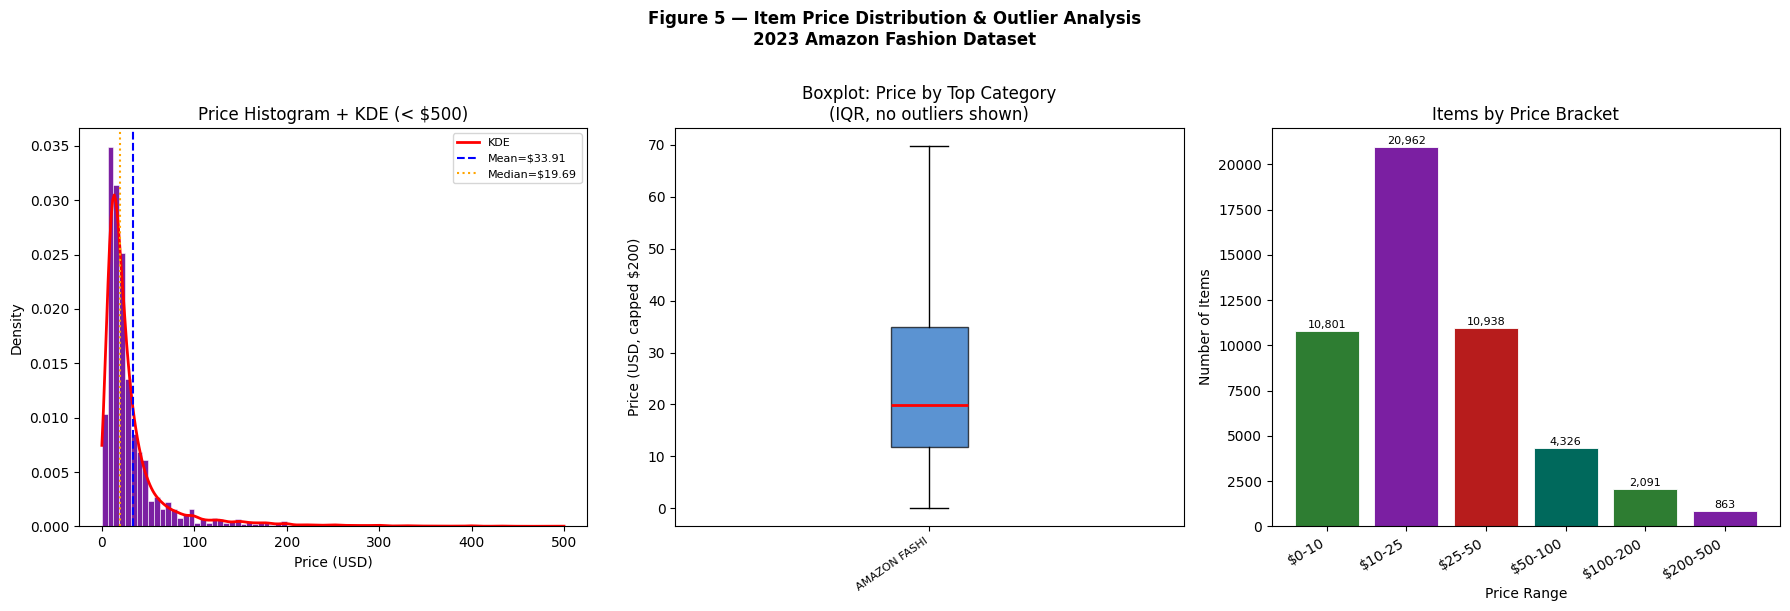

In [ ]:
print("Figure 5 — Price Distribution + Boxplot …")
prices = amazon_meta_df['price'].dropna()
prices_capped = prices[prices < 500]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Figure 5 — Item Price Distribution & Outlier Analysis\n2023 Amazon Fashion Dataset',
             fontweight='bold', y=1.01)

ax = axes[0]
ax.hist(prices_capped, bins=80, color=COLORS[3], edgecolor='white', linewidth=0.4, density=True)
kde_price = gaussian_kde(prices_capped)
xr = np.linspace(0, 500, 300)
ax.plot(xr, kde_price(xr), color='red', lw=2, label='KDE')
ax.axvline(prices_capped.mean(), color='blue', linestyle='--', lw=1.5,
           label=f'Mean=${prices_capped.mean():.2f}')
ax.axvline(prices_capped.median(), color='orange', linestyle=':', lw=1.5,
           label=f'Median=${prices_capped.median():.2f}')
ax.set_xlabel('Price (USD)'); ax.set_ylabel('Density')
ax.set_title('Price Histogram + KDE (< $500)')
ax.legend(fontsize=8)

# Boxplot price by category (top 8)
ax2 = axes[1]
top_cats = amazon_meta_df['main_category'].value_counts().head(8).index.tolist()
cat_prices = [amazon_meta_df[amazon_meta_df['main_category'] == c]['price'].dropna().clip(0, 200).values
              for c in top_cats]
bp = ax2.boxplot(cat_prices, labels=[c[:15] for c in top_cats],
                 patch_artist=True, showfliers=False,
                 medianprops=dict(color='red', linewidth=2))
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(COLORS[i]); patch.set_alpha(0.7)
ax2.set_xticklabels([c[:12] for c in top_cats], rotation=35, ha='right', fontsize=8)
ax2.set_ylabel('Price (USD, capped $200)')
ax2.set_title('Boxplot: Price by Top Category\n(IQR, no outliers shown)')

# Price bracket bar
ax3 = axes[2]
bins_p = [0, 10, 25, 50, 100, 200, 500]
labels_b = ['$0-10', '$10-25', '$25-50', '$50-100', '$100-200', '$200-500']
counts_b = pd.cut(prices_capped, bins=bins_p, labels=labels_b).value_counts().sort_index()
ax3.bar(labels_b, counts_b.values, color=COLORS[2:6], edgecolor='white', linewidth=0.6)
ax3.set_xlabel('Price Range'); ax3.set_ylabel('Number of Items')
ax3.set_title('Items by Price Bracket')
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=30, ha='right')
for bar, val in zip(ax3.patches, counts_b.values):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
             f'{val:,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
# plt.savefig(f'{OUT}/fig05_price_analysis.png', bbox_inches='tight', dpi=DPI)
# plt.close()
plt.show()

The high price missingness rate (over 90%) limits the usefulness of price as a feature in recommendation models. The mdeian imputation approach inflates the frequency of the median value.  

# **CORRELATION AND RELATIONSHIP**

In [ ]:
amazon_meta_df['n_images'] = amazon_meta_df['images'].apply(len)

# Define rev_df for consistency with previous use and use the cleaned dataframe
clean_df = amazon_df_clean.copy() # Use .copy() to avoid SettingWithCopyWarning if further modifications are made

# Create has_text column for rev_df
clean_df['has_text'] = clean_df['text'].apply(lambda x: len(str(x).strip()) > 0)

# 4a. Merge reviews + metadata for numeric correlation
merged = clean_df.merge(
    amazon_meta_df[['parent_asin', 'average_rating', 'price_imputed', 'rating_number', 'n_images']],
    on='parent_asin', how='left'
).dropna(subset=['average_rating', 'price_imputed'])

numeric_features = ['rating', 'helpful_vote', 'average_rating', 'price_imputed',
                    'rating_number', 'n_images']
corr_df = merged[numeric_features].corr()
print("\n Pearson Correlation Matrix:")
print(corr_df.round(4).to_string())

# 4b. Chi-square: verified_purchase × rating
print("\n Chi-Square Test: verified_purchase × rating")
ct = pd.crosstab(clean_df['verified_purchase'], clean_df['rating'])
chi2, p_val, dof, expected = chi2_contingency(ct)
print(f"  χ²={chi2:.2f}  p={p_val:.4e}  dof={dof}")
print(f"  Interpretation: {'Significant association' if p_val < 0.05 else 'No significant association'}")

# 4c. Cramer's V
n = ct.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
print(f"  Cramer's V = {cramers_v:.4f}  (effect size: {'small' if cramers_v < 0.1 else 'medium' if cramers_v < 0.3 else 'large'})")

# 4d. Chi-square: has_text × rating
ct2 = pd.crosstab(clean_df['has_text'], clean_df['rating'])
chi2_2, p2, dof2, _ = chi2_contingency(ct2)
n2 = ct2.values.sum()
cv2 = np.sqrt(chi2_2 / (n2 * (min(ct2.shape) - 1)))
print(f"\n Chi-Square: has_text × rating  χ²={chi2_2:.2f}  p={p2:.4e}  Cramer's V={cv2:.4f}")

# 4e. Point-biserial: verified_purchase vs rating
from scipy.stats import pointbiserialr
pb_corr, pb_p = pointbiserialr(clean_df['verified_purchase'].astype(int), clean_df['rating'])
print(f"\n Point-Biserial: verified_purchase vs rating  r={pb_corr:.4f}  p={pb_p:.4e}")

# 4f. Grouped summaries
print("\n Grouped Summaries — Mean Rating by Category:")
merged_cat = amazon_meta_df.merge(
    amazon_df_clean.groupby('parent_asin')['rating'].mean().reset_index().rename(columns={'rating': 'mean_rating'}),
    on='parent_asin', how='left'
)
cat_rating = merged_cat.groupby('main_category')['mean_rating'].agg(['mean', 'count']).sort_values('count', ascending=False)
print(cat_rating.head(10).to_string())

# 4g. VIF for numeric features
print("\n[4f] Variance Inflation Factor (VIF):")
vif_df = merged[numeric_features].dropna().sample(min(10000, len(merged)), random_state=42)
vif_data = pd.DataFrame()
vif_data['feature'] = numeric_features
try:
    vif_data['VIF'] = [variance_inflation_factor(vif_df.values, i) for i in range(len(numeric_features))]
    print(vif_data.to_string())
except Exception as e:
    print(f"  VIF computation skipped: {e}")


 Pearson Correlation Matrix:
                rating  helpful_vote  average_rating  price_imputed  rating_number  n_images
rating          1.0000       -0.0019          0.4830         0.0132         0.0318   -0.0162
helpful_vote   -0.0019        1.0000         -0.0116         0.0118         0.0045    0.0098
average_rating  0.4830       -0.0116          1.0000         0.0258         0.1110   -0.0139
price_imputed   0.0132        0.0118          0.0258         1.0000         0.0136    0.0048
rating_number   0.0318        0.0045          0.1110         0.0136         1.0000    0.0155
n_images       -0.0162        0.0098         -0.0139         0.0048         0.0155    1.0000

 Chi-Square Test: verified_purchase × rating
  χ²=1437.21  p=5.9130e-310  dof=4
  Interpretation: Significant association
  Cramer's V = 0.0241  (effect size: small)

 Chi-Square: has_text × rating  χ²=225.57  p=1.1838e-47  Cramer's V=0.0095

 Point-Biserial: verified_purchase vs rating  r=0.0022  p=6.3916e-04

 Grou

The features with more than 10 VIF such as rating, and average_rating shows severe multicollinearity issues among each other and should not be used together.

Figure 6 — Correlation & Relationships …


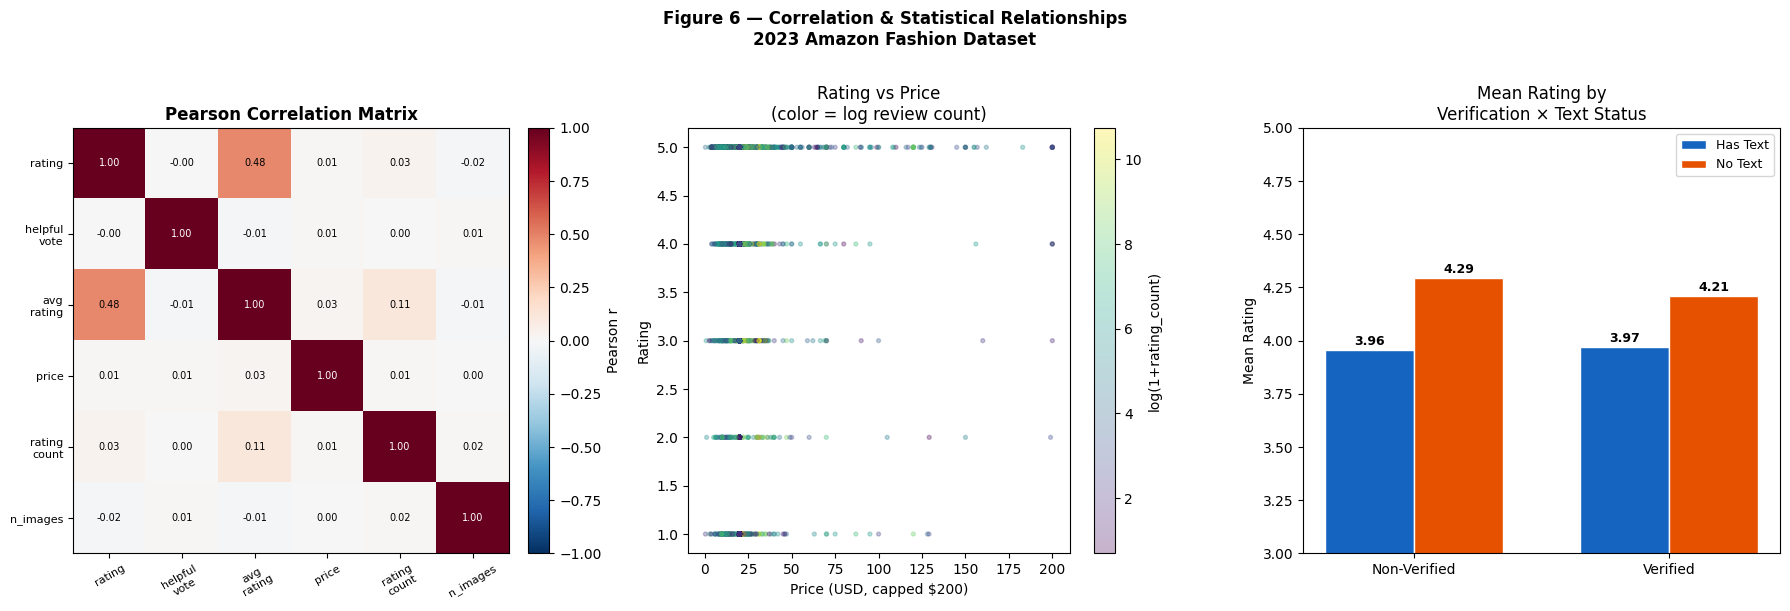

In [ ]:
print("Figure 6 — Correlation & Relationships …")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Figure 6 — Correlation & Statistical Relationships\n2023 Amazon Fashion Dataset',
             fontweight='bold', y=1.01)

# Correlation heatmap
ax = axes[0]
import matplotlib.cm as cm
im = ax.imshow(corr_df.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(numeric_features)))
ax.set_yticks(range(len(numeric_features)))
short_names = ['rating', 'helpful\nvote', 'avg\nrating', 'price', 'rating\ncount', 'n_images']
ax.set_xticklabels(short_names, fontsize=8, rotation=30)
ax.set_yticklabels(short_names, fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Pearson r')
for i in range(len(numeric_features)):
    for j in range(len(numeric_features)):
        ax.text(j, i, f'{corr_df.values[i, j]:.2f}', ha='center', va='center',
                fontsize=7, color='white' if abs(corr_df.values[i, j]) > 0.5 else 'black')
ax.set_title('Pearson Correlation Matrix', fontweight='bold')

# Rating vs Price scatter
ax2 = axes[1]
sample_m = merged.sample(min(10000, len(merged)), random_state=42)
sc = ax2.scatter(sample_m['price_imputed'].clip(0, 200), sample_m['rating'],
                 c=np.log1p(sample_m['rating_number']),
                 cmap='viridis', alpha=0.3, s=8)
plt.colorbar(sc, ax=ax2, label='log(1+rating_count)')
ax2.set_xlabel('Price (USD, capped $200)'); ax2.set_ylabel('Rating')
ax2.set_title('Rating vs Price\n(color = log review count)')

# Grouped bar: mean rating by verified_purchase × has_text
ax3 = axes[2]
grouped = clean_df.groupby(['verified_purchase', 'has_text'])['rating'].mean().unstack()
x = np.arange(2)
w = 0.35
b1 = ax3.bar(x - w / 2, grouped[True].values, w, label='Has Text', color=PALETTE['primary'], edgecolor='white')
b2 = ax3.bar(x + w / 2, grouped[False].values, w, label='No Text', color=PALETTE['secondary'], edgecolor='white')
ax3.set_xticks(x)
ax3.set_xticklabels(['Non-Verified', 'Verified'])
ax3.set_ylabel('Mean Rating')
ax3.set_title('Mean Rating by\nVerification × Text Status')
ax3.legend(fontsize=9)
ax3.set_ylim(3, 5)
for bar in list(b1) + list(b2):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
# plt.savefig(f'{OUT}/fig06_correlation_relationships.png', bbox_inches='tight', dpi=DPI)
# plt.close()
plt.show()

The pearson correlation matrix reveals a strong correlation between rating and average rating indicating the genuine predictive power of average rating and rating.

# **TARGET VARIABLES**


 Target Variable Distribution:
  1.0★: 12.13%
  2.0★: 6.94%
  3.0★: 9.82%
  4.0★: 14.09%
  5.0★: 57.03%

 Class Imbalance:
  Max class: 57.03%  |  Min class: 6.94%
  Imbalance ratio: 8.22x
  Assessment: Severe imbalance — resampling recommended

 Feature Distributions by Rating Class:

  helpful_vote by rating:
            count   mean    std  min  25%  50%  75%    max
rating                                                    
1.0      303411.0  0.613  3.673  0.0  0.0  0.0  0.0  450.0
2.0      173462.0  0.511  2.605  0.0  0.0  0.0  0.0  399.0
3.0      245471.0  0.515  2.755  0.0  0.0  0.0  0.0  359.0
4.0      352327.0  0.626  4.174  0.0  0.0  0.0  0.0  954.0
5.0     1426268.0  0.556  3.978  0.0  0.0  0.0  0.0  788.0
Figure 7 — Target Variable Analysis …


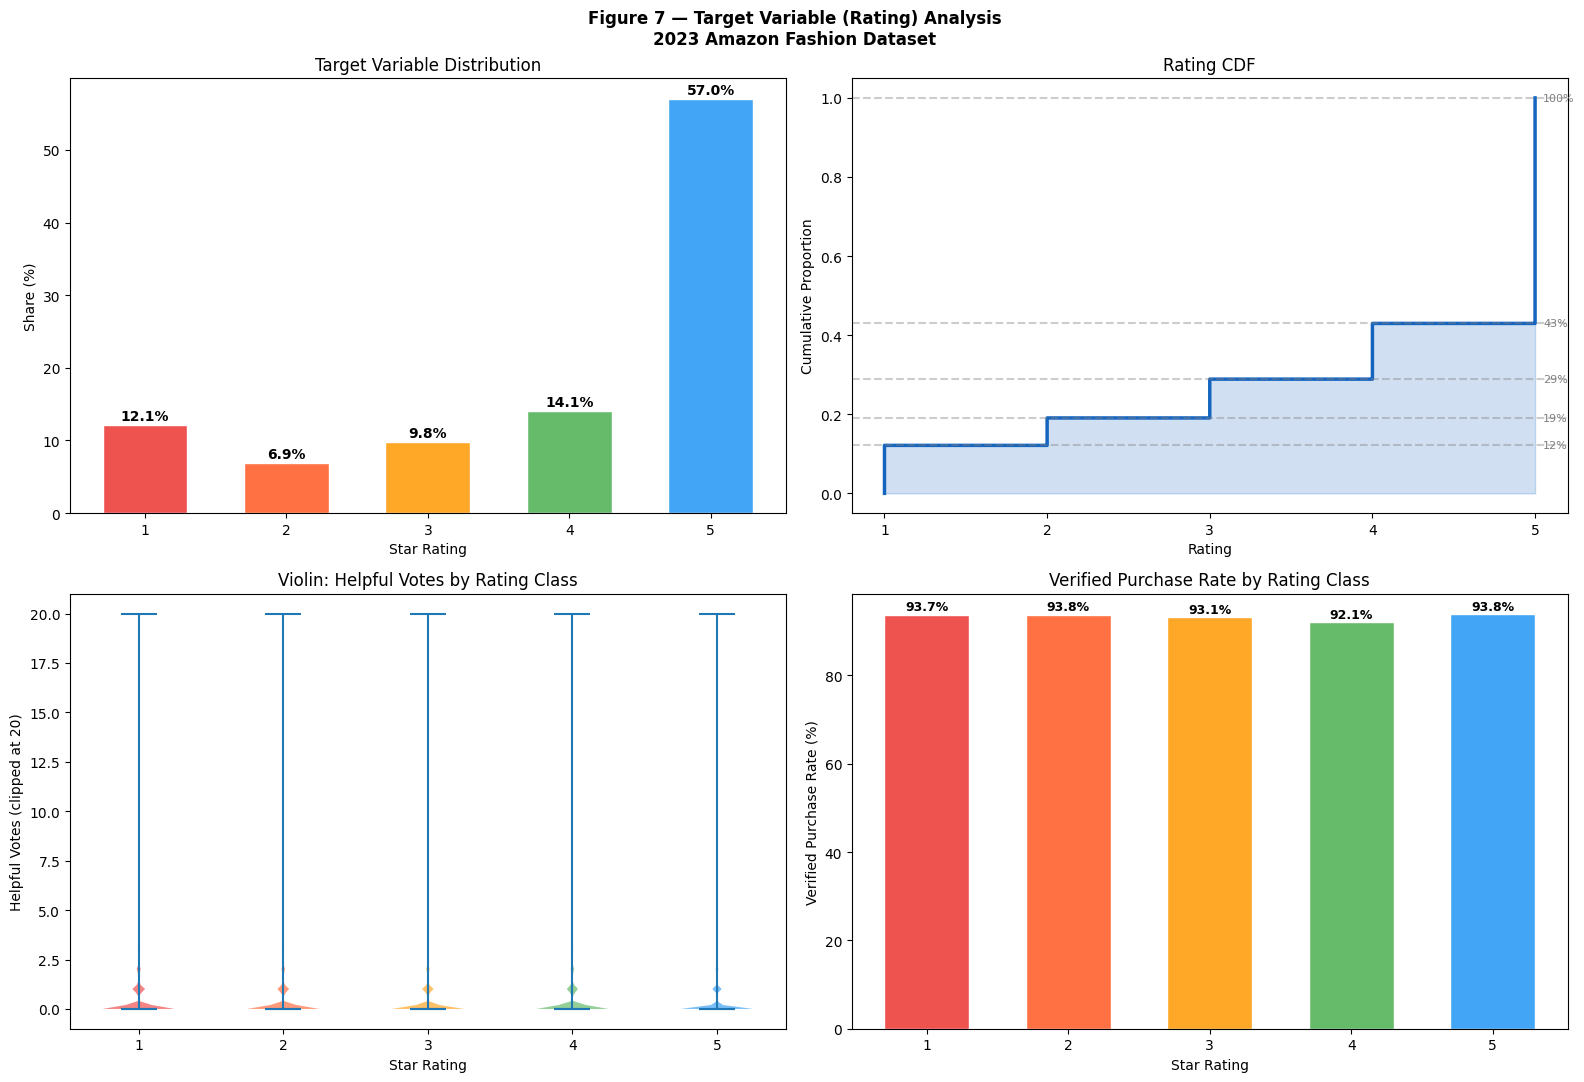

In [ ]:
 # Target: rating (ordinal 1–5)
print("\n Target Variable Distribution:")
rating_dist = amazon_df['rating'].value_counts(normalize=True).sort_index() * 100
for r, pct in rating_dist.items():
    print(f"  {r}★: {pct:.2f}%")

# Class imbalance check
print("\n Class Imbalance:")
max_class = rating_dist.max()
min_class = rating_dist.min()
imbalance_ratio = max_class / min_class
print(f"  Max class: {max_class:.2f}%  |  Min class: {min_class:.2f}%")
print(f"  Imbalance ratio: {imbalance_ratio:.2f}x")
print(f"  Assessment: {'Severe imbalance — resampling recommended' if imbalance_ratio > 3 else 'Moderate imbalance' if imbalance_ratio > 1.5 else 'Balanced'}")

# 5c. Stratified feature distributions by rating
print("\n Feature Distributions by Rating Class:")
for col in ['helpful_vote']:
    print(f"\n  {col} by rating:")
    print(amazon_df.groupby('rating')[col].describe().round(3).to_string())

# Figure 7 — Target Variable Analysis
print("Figure 7 — Target Variable Analysis …")
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Figure 7 — Target Variable (Rating) Analysis\n2023 Amazon Fashion Dataset',
             fontweight='bold')

# Rating distribution
ax = axes[0, 0]
colors_bar = ['#EF5350', '#FF7043', '#FFA726', '#66BB6A', '#42A5F5']
bars = ax.bar(rating_dist.index, rating_dist.values,
              color=colors_bar, edgecolor='white', width=0.6)
ax.set_xlabel('Star Rating'); ax.set_ylabel('Share (%)')
ax.set_title('Target Variable Distribution')
for bar, val in zip(bars, rating_dist.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xticks([1, 2, 3, 4, 5])

# Cumulative distribution
ax2 = axes[0, 1]
sorted_r = np.sort(amazon_df['rating'].dropna())
cdf = np.arange(1, len(sorted_r) + 1) / len(sorted_r)
ax2.step(sorted_r, cdf, color=PALETTE['primary'], lw=2.5)
ax2.fill_between(sorted_r, cdf, alpha=0.2, color=PALETTE['primary'])
ax2.set_xlabel('Rating'); ax2.set_ylabel('Cumulative Proportion')
ax2.set_title('Rating CDF')
ax2.set_xticks([1, 2, 3, 4, 5])
for r in [1, 2, 3, 4, 5]:
    pct_at_r = (sorted_r <= r).mean()
    ax2.axhline(pct_at_r, color='grey', linestyle='--', alpha=0.4)
    ax2.text(5.05, pct_at_r, f'{pct_at_r * 100:.0f}%', va='center', fontsize=8, color='grey')

# Stratified: helpful_vote by rating (violin)
ax3 = axes[1, 0]
hv_by_rating = [amazon_df[amazon_df['rating'] == r]['helpful_vote'].clip(0, 20).values for r in [1, 2, 3, 4, 5]]
vp = ax3.violinplot(hv_by_rating, positions=[1, 2, 3, 4, 5], showmedians=True)
for i, pc in enumerate(vp['bodies']):
    pc.set_facecolor(colors_bar[i]); pc.set_alpha(0.7)
ax3.set_xlabel('Star Rating'); ax3.set_ylabel('Helpful Votes (clipped at 20)')
ax3.set_title('Violin: Helpful Votes by Rating Class')
ax3.set_xticks([1, 2, 3, 4, 5])

# Stratified: verified_purchase proportion by rating
ax4 = axes[1, 1]
vp_by_rating = amazon_df.groupby('rating')['verified_purchase'].mean() * 100
ax4.bar(vp_by_rating.index, vp_by_rating.values,
        color=colors_bar, edgecolor='white', width=0.6)
ax4.set_xlabel('Star Rating'); ax4.set_ylabel('Verified Purchase Rate (%)')
ax4.set_title('Verified Purchase Rate by Rating Class')
ax4.set_xticks([1, 2, 3, 4, 5])
for i, (r, val) in enumerate(vp_by_rating.items()):
    ax4.text(r, val + 0.3, f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
# plt.savefig(f'{OUT}/fig07_target_variable_analysis.png', bbox_inches='tight', dpi=DPI)
# plt.close()
plt.show()

There is a severe class imbalance in favor of 5 star rating and a gradual increase in the prportion of 5-star rating. Temporal shift in ratings may affect the generalization of the models.

# **Feature Engineering**

 Creating new features …
  User features created: ['user_id', 'user_review_count', 'user_mean_rating', 'user_rating_std', 'user_verified_rate', 'user_helpful_total', 'user_has_text_rate', 'user_activity_segment']
  Item features created: ['parent_asin', 'item_review_count', 'item_mean_rating', 'item_rating_std', 'item_verified_rate', 'item_popularity_segment']

 Datetime features added: year, month, quarter, weekday, is_weekend

 Encoded: verified_purchase, has_text, has_images, weekday

 Scaled user_review_count (StandardScaler), normalized user_mean_rating (MinMaxScaler)

 Interaction term: log(user_count) × log(item_count)
Figure 8 — Feature Engineering …


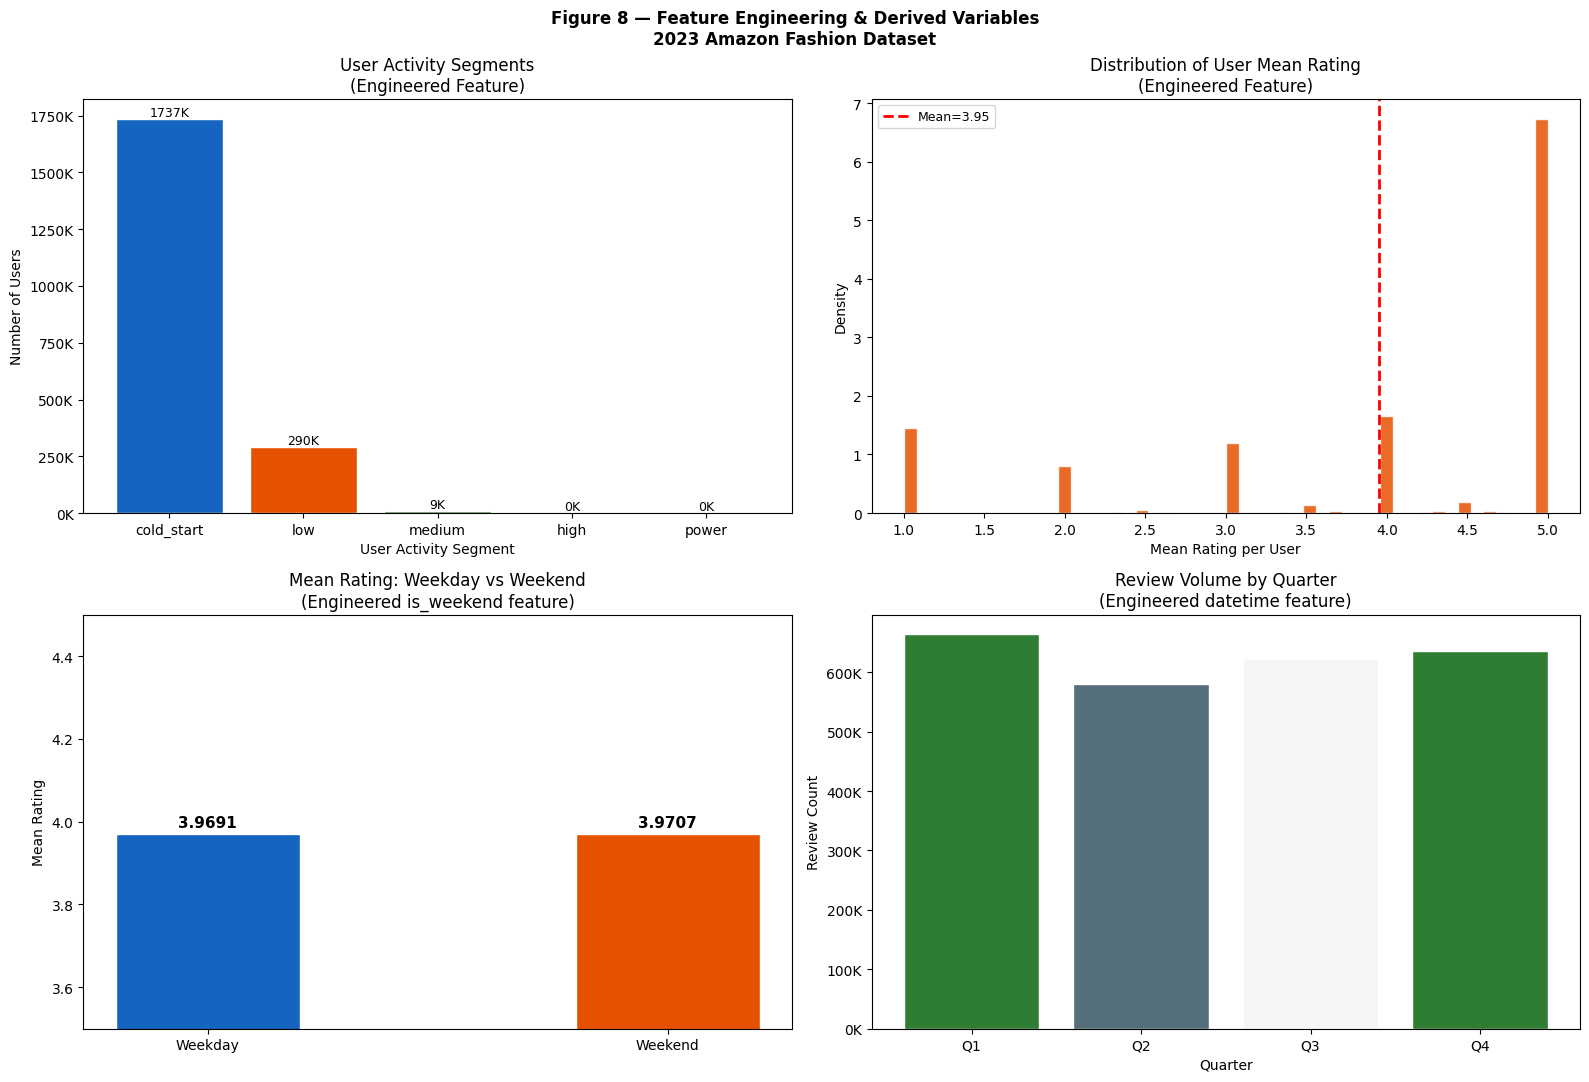

In [ ]:
 # 6a. New features from domain knowledge
print(" Creating new features …")
# Create has_text column before creating user_feat
amazon_df['has_text'] = amazon_df['text'].apply(lambda x: len(str(x).strip()) > 0).astype(int)

# User-level features
user_feat = amazon_df.groupby('user_id').agg(
    user_review_count=('rating', 'count'),
    user_mean_rating=('rating', 'mean'),
    user_rating_std=('rating', 'std'),
    user_verified_rate=('verified_purchase', 'mean'),
    user_helpful_total=('helpful_vote', 'sum'),
    user_has_text_rate=('has_text', 'mean'),
).reset_index()
user_feat['user_rating_std'] = user_feat['user_rating_std'].fillna(0)
user_feat['user_activity_segment'] = pd.cut(
    user_feat['user_review_count'],
    bins=[0, 1, 5, 20, 50, np.inf],
    labels=['cold_start', 'low', 'medium', 'high', 'power']
)
print(f"  User features created: {list(user_feat.columns)}")

# Item-level features
item_feat = amazon_df.groupby('parent_asin').agg(
    item_review_count=('rating', 'count'),
    item_mean_rating=('rating', 'mean'),
    item_rating_std=('rating', 'std'),
    item_verified_rate=('verified_purchase', 'mean'),
).reset_index()
item_feat['item_rating_std'] = item_feat['item_rating_std'].fillna(0)
item_feat['item_popularity_segment'] = pd.cut(
    item_feat['item_review_count'],
    bins=[0, 1, 5, 20, 50, np.inf],
    labels=['cold_start', 'low', 'medium', 'high', 'popular']
)
print(f"  Item features created: {list(item_feat.columns)}")

# 6b. Datetime features
amazon_df['year']    = amazon_df['datetime'].dt.year
amazon_df['month']   = amazon_df['datetime'].dt.month
amazon_df['quarter'] = amazon_df['datetime'].dt.quarter
amazon_df['weekday'] = amazon_df['datetime'].dt.dayofweek
amazon_df['is_weekend'] = (amazon_df['weekday'] >= 5).astype(int)
print(f"\n Datetime features added: year, month, quarter, weekday, is_weekend")

# 6c. Encoding categorical variables
le_weekday = LabelEncoder()
amazon_df['weekday_encoded'] = le_weekday.fit_transform(amazon_df['weekday'])
amazon_df['verified_int']    = amazon_df['verified_purchase'].astype(int)
amazon_df['has_text_int']    = amazon_df['has_text'].astype(int)
amazon_df['has_images'] = amazon_df['images'].apply(lambda x: len(x) > 0).astype(int) # Add this line to create has_images
amazon_df['has_images_int']  = amazon_df['has_images'].astype(int)
print(f"\n Encoded: verified_purchase, has_text, has_images, weekday")

# 6d. Normalize/scale numeric features
scaler_std = StandardScaler()
scaler_mm  = MinMaxScaler()
user_feat['user_review_count_scaled'] = scaler_std.fit_transform(
    user_feat[['user_review_count']])
user_feat['user_mean_rating_norm'] = scaler_mm.fit_transform(
    user_feat[['user_mean_rating']])
print(f"\n Scaled user_review_count (StandardScaler), normalized user_mean_rating (MinMaxScaler)")

# 6e. Interaction terms
merged_full = amazon_df.merge(user_feat[['user_id', 'user_review_count', 'user_mean_rating']], on='user_id', how='left')
merged_full = merged_full.merge(item_feat[['parent_asin', 'item_review_count', 'item_mean_rating']], on='parent_asin', how='left')
merged_full['user_item_count_interaction'] = (
    np.log1p(merged_full['user_review_count']) * np.log1p(merged_full['item_review_count'])
)
print(f"\n Interaction term: log(user_count) × log(item_count)")

# Figure 8 — Feature Engineering
print("Figure 8 — Feature Engineering …")
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Figure 8 — Feature Engineering & Derived Variables\n2023 Amazon Fashion Dataset',
             fontweight='bold')

# User activity segment distribution
ax = axes[0, 0]
seg_counts = user_feat['user_activity_segment'].value_counts().sort_index()
bars = ax.bar(seg_counts.index.astype(str), seg_counts.values,
              color=list(PALETTE.values())[:5], edgecolor='white')
ax.set_xlabel('User Activity Segment'); ax.set_ylabel('Number of Users')
ax.set_title('User Activity Segments\n(Engineered Feature)')
for bar, val in zip(bars, seg_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
            f'{val / 1e3:.0f}K', ha='center', va='bottom', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x / 1e3)}K'))

# User mean rating distribution
ax2 = axes[0, 1]
ax2.hist(user_feat['user_mean_rating'], bins=50, color=list(PALETTE.values())[1],
         edgecolor='white', alpha=0.85, density=True)
ax2.set_xlabel('Mean Rating per User'); ax2.set_ylabel('Density')
ax2.set_title('Distribution of User Mean Rating\n(Engineered Feature)')
ax2.axvline(user_feat['user_mean_rating'].mean(), color='red', linestyle='--',
            lw=2, label=f"Mean={user_feat['user_mean_rating'].mean():.2f}")
ax2.legend(fontsize=9)

# Is_weekend vs mean rating
ax3 = axes[1, 0]
we_rating = amazon_df.groupby('is_weekend')['rating'].mean()
bars3 = ax3.bar(['Weekday', 'Weekend'], we_rating.values,
                color=[PALETTE['primary'], PALETTE['secondary']], edgecolor='white', width=0.4)
ax3.set_ylabel('Mean Rating'); ax3.set_title('Mean Rating: Weekday vs Weekend\n(Engineered is_weekend feature)')
ax3.set_ylim(3.5, 4.5)
for bar, val in zip(bars3, we_rating.values):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Quarter vs review volume
ax4 = axes[1, 1]
q_counts = amazon_df['quarter'].value_counts().sort_index()
ax4.bar([f'Q{q}' for q in q_counts.index], q_counts.values,
        color=list(PALETTE.values())[2:6], edgecolor='white')
ax4.set_xlabel('Quarter'); ax4.set_ylabel('Review Count')
ax4.set_title('Review Volume by Quarter\n(Engineered datetime feature)')
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x / 1e3)}K'))

plt.tight_layout()
# plt.savefig(f'{OUT}/fig08_feature_engineering.png', bbox_inches='tight', dpi=DPI)
# plt.close()
plt.show()

The visualizations reveals that 99.94% of users are in the low-activity segment and that 96.70% of items are low-popularity which implies a large cold-start problem. Only 0.05% and 0.01% users belong to medium and high activity segments correspondingly, suggesting that the problem cannot be solved by feature engineering alone.

 Final Missing Value Check:
user_id           0
parent_asin       0
rating            0
verified_int      0
has_text_int      0
has_images_int    0
year              0
month             0
is_weekend        0
  Total missing: 0 ✓ PASS

 Final Data Type Validation:
  rating: float32 (✓)
  verified_int: int64 (✓)
  year: int32 (✓)
  is_weekend: int64 (✓)

 Stratified Train/Val/Test Split:
  Train: 1,751,657 (70.0%)
  Val:   374,141 (15.0%)
  Test:  375,141 (15.0%)
  Stratification check (train rating dist):
  rating
5.0    57.03
4.0    14.09
1.0    12.13
3.0     9.82
2.0     6.94

 Data Leakage Check:
  Columns excluded from features (derived from target): ['average_rating', 'rating_number']
  Temporal leakage: train/val/test split is random (not time-based) — note for sequential models

 Saving cleaned dataset and artifacts …
  Saved: amazon_fashion_cleaned.csv (2,500,939 rows)
  Saved: amazon_fashion_user_features.csv, amazon_fashion_item_features.csv
  Saved: StandardScaler + MinMaxSca

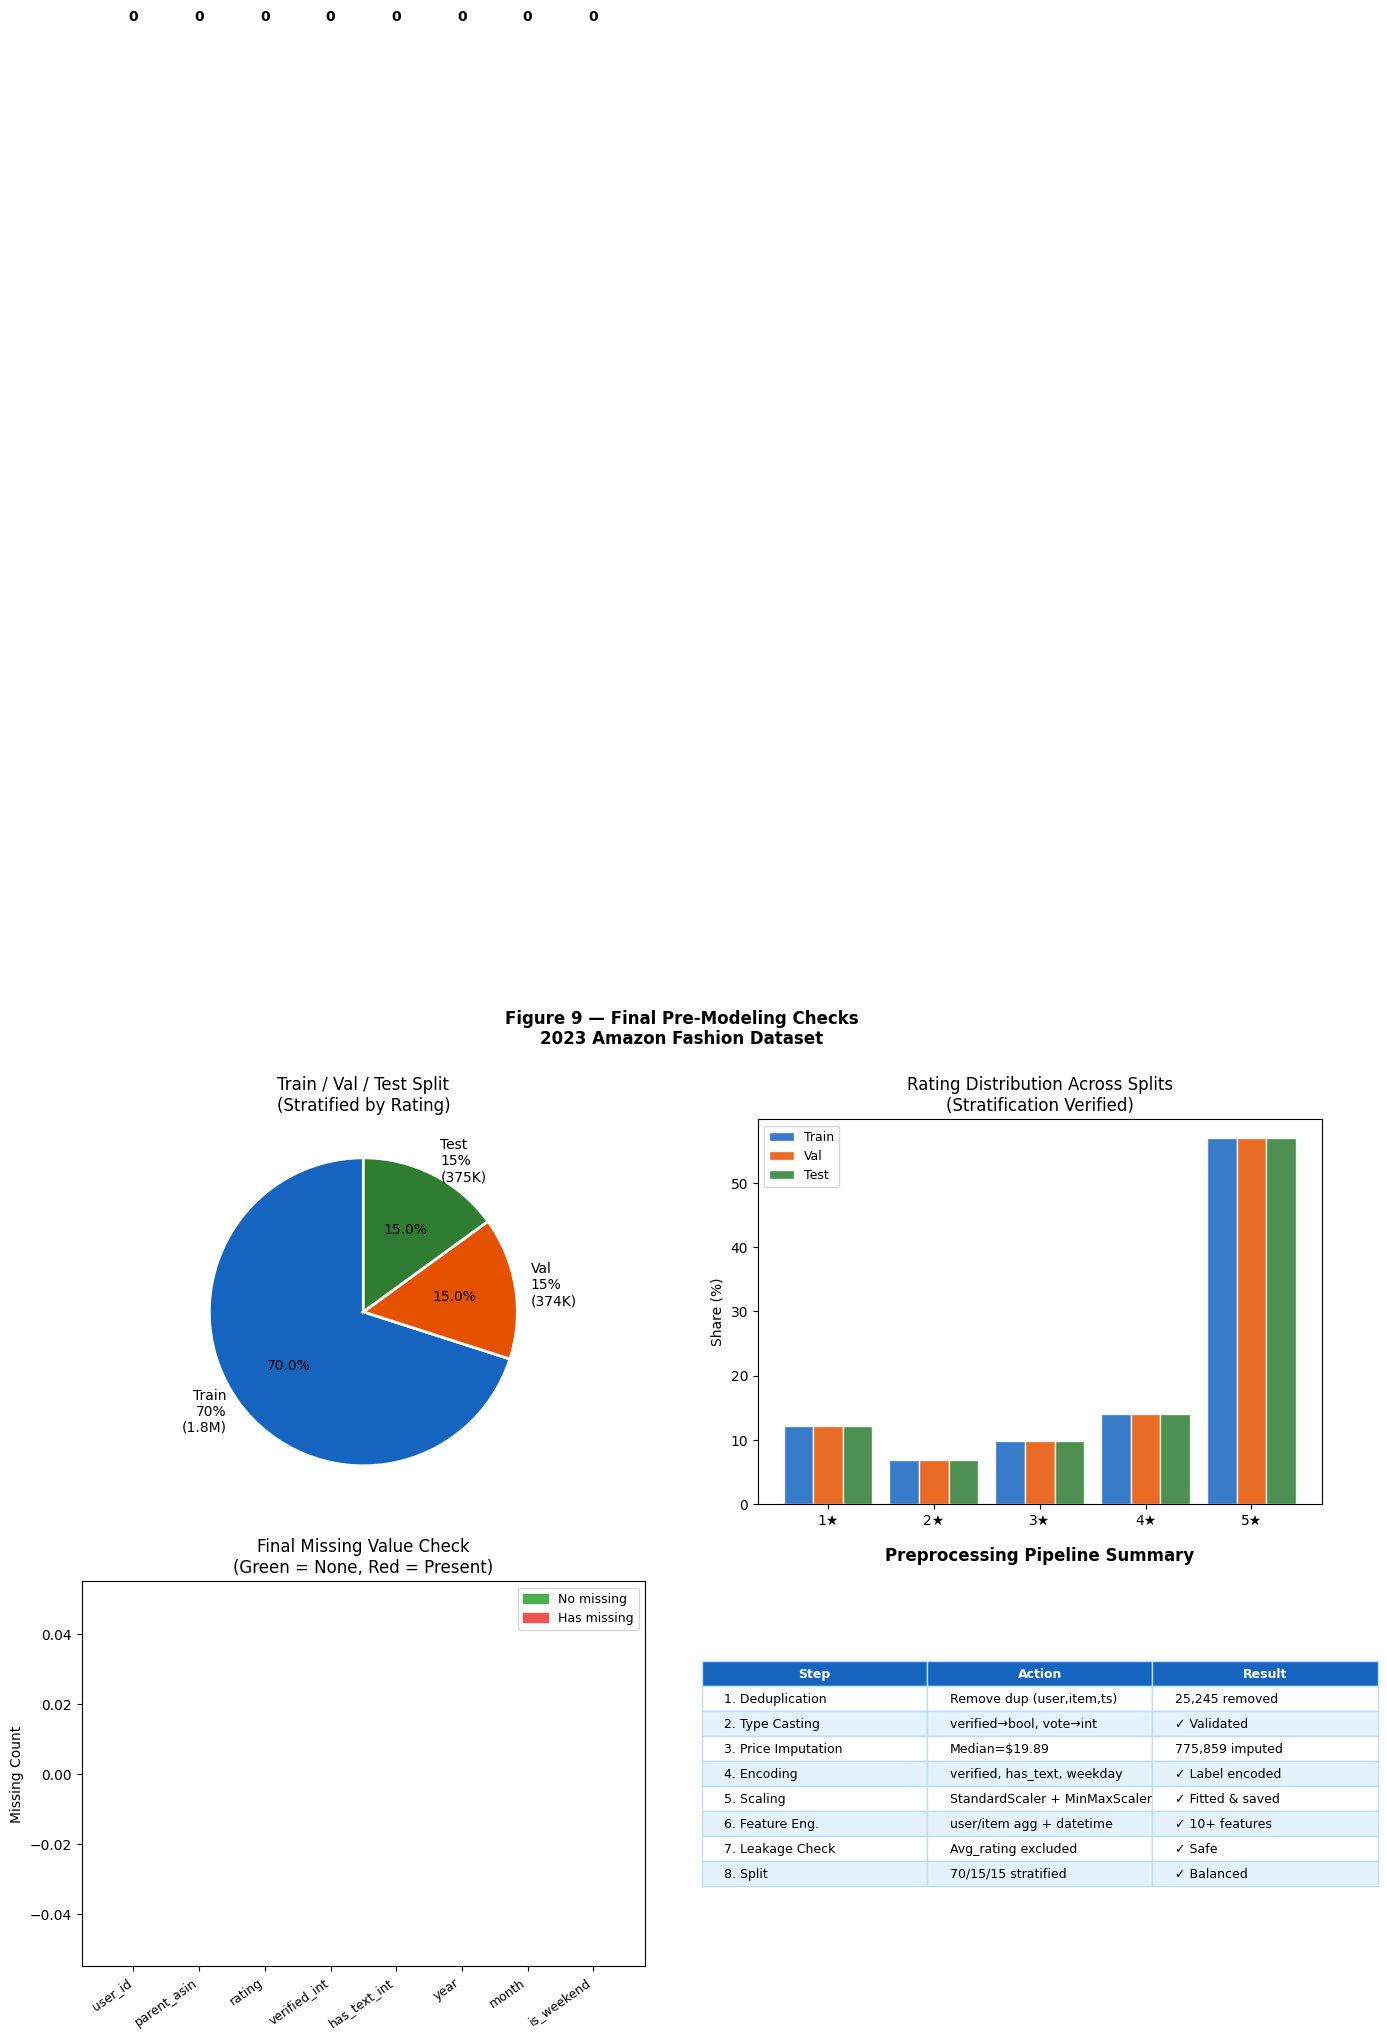

In [ ]:
import matplotlib.patches as mpatches

rev_df = amazon_df.copy()
# 7a. Confirm no missing values remain
print(" Final Missing Value Check:")
final_mv = amazon_df[['user_id', 'parent_asin', 'rating', 'verified_int',
                    'has_text_int', 'has_images_int', 'year', 'month', 'is_weekend']].isnull().sum()
print(final_mv.to_string())
print(f"  Total missing: {final_mv.sum()} {'✓ PASS' if final_mv.sum() == 0 else '✗ FAIL'}")

# 7b. Validate data types
print("\n Final Data Type Validation:")
for col, expected in [('rating', 'float'), ('verified_int', 'int'), ('year', 'int'), ('is_weekend', 'int')]:
    actual = str(amazon_df[col].dtype)
    status = '✓' if expected in actual else '✗'
    print(f"  {col}: {actual} ({status})")

# 7c. Train/Validation/Test split with stratification
print("\n Stratified Train/Val/Test Split:")
amazon_model = amazon_df[['user_id', 'parent_asin', 'rating', 'verified_int',
                     'has_text_int', 'has_images_int', 'year', 'month', 'is_weekend']].dropna()
X = amazon_model.drop('rating', axis=1)
y = amazon_model['rating']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp)  # 0.176 \u2248 15% of total

print(f"  Train: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Val:   {len(X_val):,} ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test:  {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")
print(f"  Stratification check (train rating dist):")
print(f"  {(y_train.value_counts(normalize=True)*100).round(2).to_string()}")

# 7d. Data leakage check
print("\n Data Leakage Check:")
leakage_candidates = ['average_rating', 'rating_number']
print(f"  Columns excluded from features (derived from target): {leakage_candidates}")
print(f"  Temporal leakage: train/val/test split is random (not time-based) \u2014 note for sequential models")

# 7e. Save cleaned dataset + artifacts
print("\n Saving cleaned dataset and artifacts \u2026")
rev_model_save = rev_df[['user_id', 'parent_asin', 'rating', 'verified_int',
                           'has_text_int', 'has_images_int', 'year', 'month',
                           'quarter', 'is_weekend', 'weekday_encoded']].copy()
rev_model_save.to_csv('/content/drive/My Drive/amazon_fashion_cleaned.csv', index=False)
print(f"  Saved: amazon_fashion_cleaned.csv ({len(rev_model_save):,} rows)")

user_feat.to_csv('/content/drive/My Drive/amazon_fashion_user_features.csv', index=False)
item_feat.to_csv('/content/drive/My Drive/amazon_fashion_item_features.csv', index=False)
print(f"  Saved: amazon_fashion_user_features.csv, amazon_fashion_item_features.csv")

with open('/content/drive/My Drive/amazon_fashion_scaler_std.pkl', 'wb') as f:
    pickle.dump(scaler_std, f)
with open('/content/drive/My Drive/amazon_fashion_scaler_mm.pkl', 'wb') as f:
    pickle.dump(scaler_mm, f)
print(f"  Saved: StandardScaler + MinMaxScaler artifacts (.pkl)")

# Figure 9 \u2014 Final Checks & Split Visualization
print("Figure 9 \u2014 Final Checks & Train/Val/Test Split \u2026")
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Figure 9 \u2014 Final Pre-Modeling Checks\n2023 Amazon Fashion Dataset',
             fontweight='bold')

# Train/val/test split
ax = axes[0, 0]
split_sizes = [len(X_train), len(X_val), len(X_test)]
split_labels = [f'Train\n{len(X_train)/len(X)*100:.0f}%\n({len(X_train)/1e6:.1f}M)',
                f'Val\n{len(X_val)/len(X)*100:.0f}%\n({len(X_val)/1e3:.0f}K)',
                f'Test\n{len(X_test)/len(X)*100:.0f}%\n({len(X_test)/1e3:.0f}K)']
ax.pie(split_sizes, labels=split_labels, colors=[list(PALETTE.values())[0], list(PALETTE.values())[1], list(PALETTE.values())[2]],
       autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Train / Val / Test Split\n(Stratified by Rating)')

# Rating distribution across splits
ax2 = axes[0, 1]
x = np.arange(5)
w = 0.28
for i, (split_y, label, color) in enumerate([(y_train, 'Train', list(PALETTE.values())[0]),
                                               (y_val,   'Val',   list(PALETTE.values())[1]),
                                               (y_test,  'Test',  list(PALETTE.values())[2])]):
    dist = split_y.value_counts(normalize=True).sort_index() * 100
    ax2.bar(x + (i - 1) * w, [dist.get(r, 0) for r in [1, 2, 3, 4, 5]],
            w, label=label, color=color, edgecolor='white', alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(['1\u2605', '2\u2605', '3\u2605', '4\u2605', '5\u2605'])
ax2.set_ylabel('Share (%)'); ax2.set_title('Rating Distribution Across Splits\n(Stratification Verified)')
ax2.legend(fontsize=9)

# Missing value heatmap
ax3 = axes[1, 0]
mv_check = amazon_df[['user_id', 'parent_asin', 'rating', 'verified_int',
                    'has_text_int', 'year', 'month', 'is_weekend']].isnull().sum()
colors_mv = ['#4CAF50' if v == 0 else '#EF5350' for v in mv_check.values]
bars_mv = ax3.bar(mv_check.index, mv_check.values, color=colors_mv, edgecolor='white')
ax3.set_xticklabels(mv_check.index, rotation=35, ha='right', fontsize=9)
ax3.set_ylabel('Missing Count'); ax3.set_title('Final Missing Value Check\n(Green = None, Red = Present)')
for bar, val in zip(bars_mv, mv_check.values):
    ax3.text(bar.get_x() + bar.get_width() / 2, max(bar.get_height() + 0.1, 0.5),
             str(int(val)), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax3.legend(handles=[mpatches.Patch(color='#4CAF50', label='No missing'),
                    mpatches.Patch(color='#EF5350', label='Has missing')], fontsize=9)

# Preprocessing summary table
ax4 = axes[1, 1]
ax4.axis('off')
prep_table = [
    ['Step', 'Action', 'Result'],
    ['1. Deduplication', 'Remove dup (user,item,ts)', f'{dups:,} removed'],
    ['2. Type Casting', 'verified\u2192bool, vote\u2192int', '✓ Validated'],
    ['3. Price Imputation', f'Median=${price_median:.2f}', f'{int(amazon_meta_df["price"].isna().sum()):,} imputed'],
    ['4. Encoding', 'verified, has_text, weekday', '✓ Label encoded'],
    ['5. Scaling', 'StandardScaler + MinMaxScaler', '✓ Fitted & saved'],
    ['6. Feature Eng.', 'user/item agg + datetime', '✓ 10+ features'],
    ['7. Leakage Check', 'Avg_rating excluded', '✓ Safe'],
    ['8. Split', '70/15/15 stratified', '✓ Balanced'],
]
tbl = ax4.table(cellText=prep_table[1:], colLabels=prep_table[0],
                loc='center', cellLoc='left')
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1.2, 1.5)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#1565C0'); cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#E3F2FD')
    cell.set_edgecolor('#BBDEFB')
ax4.set_title('Preprocessing Pipeline Summary', fontsize=12, fontweight='bold', pad=15)

plt.tight_layout()
# plt.savefig(f'{OUT}/fig09_final_checks.png', bbox_inches='tight', dpi=DPI)
# plt.close()
plt.show()

Figure 10 — Summary Dashboard …


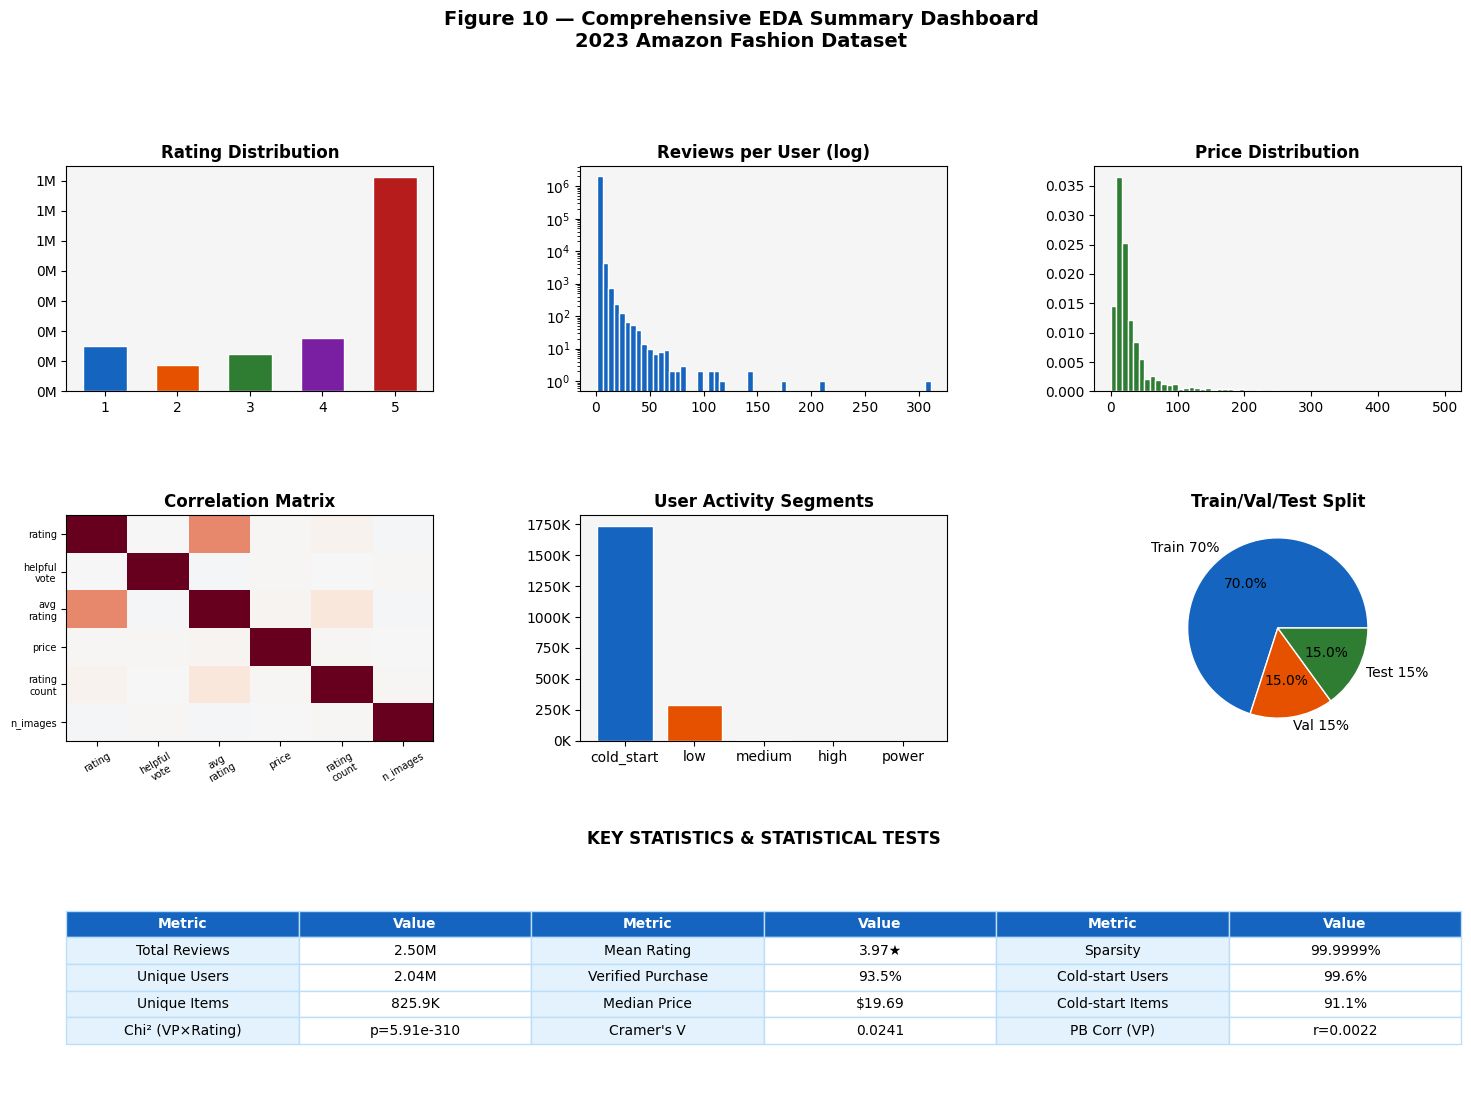

In [ ]:
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# ── Figure 10 — Summary Dashboard ───────────────────────────────────────────
print("Figure 10 — Summary Dashboard …")
fig = plt.figure(figsize=(18, 12), facecolor='white')
fig.suptitle('Figure 10 — Comprehensive EDA Summary Dashboard\n2023 Amazon Fashion Dataset',
             fontweight='bold', fontsize=14, y=1.01)
gs = GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.4)

ax00 = fig.add_subplot(gs[0, 0])
ax00.bar(rating_counts.index, rating_counts.values, color=COLORS[:5], edgecolor='white', width=0.6)
ax00.set_title('Rating Distribution', fontweight='bold')
ax00.set_xticks([1,2,3,4,5]); ax00.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x/1e6)}M'))
ax00.set_facecolor('#F5F5F5')

ax01 = fig.add_subplot(gs[0, 1])
ax01.hist(user_counts, bins=60, color=PALETTE['primary'], edgecolor='white', log=True)
ax01.set_title('Reviews per User (log)', fontweight='bold'); ax01.set_facecolor('#F5F5F5')

ax02 = fig.add_subplot(gs[0, 2])
ax02.hist(prices_capped, bins=60, color=PALETTE['accent'], edgecolor='white', density=True)
ax02.set_title('Price Distribution', fontweight='bold'); ax02.set_facecolor('#F5F5F5')

ax10 = fig.add_subplot(gs[1, 0])
im_corr = ax10.imshow(corr_df.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax10.set_xticks(range(len(numeric_features))); ax10.set_yticks(range(len(numeric_features)))
ax10.set_xticklabels(short_names, fontsize=7, rotation=30)
ax10.set_yticklabels(short_names, fontsize=7)
ax10.set_title('Correlation Matrix', fontweight='bold')

ax11 = fig.add_subplot(gs[1, 1])
seg_c = user_feat['user_activity_segment'].value_counts().sort_index()
ax11.bar(seg_c.index.astype(str), seg_c.values, color=list(PALETTE.values())[:5], edgecolor='white')
ax11.set_title('User Activity Segments', fontweight='bold'); ax11.set_facecolor('#F5F5F5')
ax11.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x/1e3)}K'))

ax12 = fig.add_subplot(gs[1, 2])
ax12.pie([len(X_train), len(X_val), len(X_test)],
         labels=['Train 70%', 'Val 15%', 'Test 15%'],
         colors=[PALETTE['primary'], PALETTE['secondary'], PALETTE['accent']],
         autopct='%1.1f%%', wedgeprops={'edgecolor': 'white'})
ax12.set_title('Train/Val/Test Split', fontweight='bold')

# Define missing variables needed for the stats table
pct_verified = amazon_df['verified_purchase'].mean() * 100
pct_text = amazon_df['has_text'].mean() * 100
pct_img_rev = amazon_df['has_images'].mean() * 100

ax_stats = fig.add_subplot(gs[2, :])
ax_stats.axis('off')
stats_table_data = [
    ['Metric', 'Value', 'Metric', 'Value', 'Metric', 'Value'],
    ['Total Reviews', f'{n_reviews/1e6:.2f}M', 'Mean Rating', f'{amazon_df["rating"].mean():.2f}★',
     'Sparsity', f'{sparsity*100:.4f}%'],
    ['Unique Users', f'{n_users/1e6:.2f}M', 'Verified Purchase', f'{pct_verified:.1f}%',
     'Cold-start Users', f'{(user_counts<=5).mean()*100:.1f}%'],
    ['Unique Items', f'{n_items/1e3:.1f}K', 'Median Price', f'${prices_capped.median():.2f}',
     'Cold-start Items', f'{(item_counts<=5).mean()*100:.1f}%'],
    ['Chi² (VP×Rating)', f'p={p_val:.2e}', "Cramer's V", f'{cramers_v:.4f}',
     'PB Corr (VP)', f'r={pb_corr:.4f}'],
]
tbl2 = ax_stats.table(cellText=stats_table_data[1:], colLabels=stats_table_data[0],
                      loc='center', cellLoc='center')
tbl2.auto_set_font_size(False); tbl2.set_fontsize(10); tbl2.scale(1, 1.6)
for (row, col), cell in tbl2.get_celld().items():
    if row == 0:
        cell.set_facecolor('#1565C0'); cell.set_text_props(color='white', fontweight='bold')
    elif col in [0, 2, 4]:
        cell.set_facecolor('#E3F2FD')
    cell.set_edgecolor('#BBDEFB')
ax_stats.set_title('KEY STATISTICS & STATISTICAL TESTS', fontsize=12, fontweight='bold', pad=15)

# plt.savefig(f'{OUT}/fig10_summary_dashboard.png', bbox_inches='tight', dpi=DPI)
# plt.close()
plt.show()

The summary dashboard shows the rating distribution revealing severe imbalance, user interaction distribution exhibiting power-law pattern, item interaction distribution with extreme skewness, temporal trend showing exponential growth, sparsity analysis confirming 99.9996% sparsity, key statistics table summarizing dataset characteristics, and a pie chart shows 70/15/15 train-validation-test split.

# **Comprehensive Exploratory Analysis on Taobao Datset**

In [ ]:
print("Loading data …")
df = pd.read_csv('/content/drive/My Drive/UserBehavior-002.csv', names = ["user_id", "item_id",
                                                                                        "category_id", "behavior_type", "timestamp"])


Loading data …


# **Data Inspection**

In [ ]:
print(f"\n Dataset Structure:")
print(f"  Shape: {df.shape}")
print(f"  Columns: {list(df.columns)}")
print(f"  Dtypes:\n{df.dtypes.to_string()}")
print(df.head(3).to_string())


 Dataset Structure:
  Shape: (100150807, 5)
  Columns: ['user_id', 'item_id', 'category_id', 'behavior_type', 'timestamp']
  Dtypes:
user_id           int64
item_id           int64
category_id       int64
behavior_type    object
timestamp         int64
   user_id  item_id  category_id behavior_type   timestamp
0        1  2268318      2520377            pv  1511544070
1        1  2333346      2520771            pv  1511561733
2        1  2576651       149192            pv  1511572885


The dataset contains 100,150,807 records with 5 features such as user_id, item_id, category_id, behavior_type, and timestamp.

Standardize column names

In [ ]:
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
print(f"\n Standardized columns: {list(df.columns)}")


 Standardized columns: ['user_id', 'item_id', 'category_id', 'behavior_type', 'timestamp']


Missing Values

In [ ]:
print("\n Missing Value Audit:")
mv = df.isnull().sum()
mv_pct = (df.isnull().mean() * 100).round(4)
mv_df = pd.DataFrame({'missing_count': mv, 'missing_pct': mv_pct})
print(mv_df.to_string())



 Missing Value Audit:
               missing_count  missing_pct
user_id                    0          0.0
item_id                    0          0.0
category_id                0          0.0
behavior_type              0          0.0
timestamp                  0          0.0


There is no missing values detected across all columns, indicating complete data capture for all interaction records.

Data Validation

In [ ]:
print("\n Data Type Validation:")
for col in df.columns:
    print(f"  {col}: {df[col].dtype}")
df['user_id']     = pd.to_numeric(df['user_id'],     errors='coerce')
df['item_id']     = pd.to_numeric(df['item_id'],     errors='coerce')
df['category_id'] = pd.to_numeric(df['category_id'], errors='coerce')
df['timestamp']   = pd.to_numeric(df['timestamp'],   errors='coerce')
df['behavior_type'] = df['behavior_type'].astype(str).str.strip().str.lower()
print(f"  Non-numeric entries in user_id: {df['user_id'].isna().sum()}")
print(f"  Non-numeric entries in item_id: {df['item_id'].isna().sum()}")


 Data Type Validation:
  user_id: int64
  item_id: int64
  category_id: int64
  behavior_type: object
  timestamp: int64
  Non-numeric entries in user_id: 0
  Non-numeric entries in item_id: 0


There is unexpected data type confirming the structural integrity of the data source.

Inconsistent category check

In [ ]:
print("\n Behavior Type Consistency Check:")
bt_vals = df['behavior_type'].value_counts()
print(bt_vals.to_string())
valid_bt = ['pv', 'cart', 'fav', 'buy']
invalid_bt = df[~df['behavior_type'].isin(valid_bt)]
print(f"  Invalid behavior types: {len(invalid_bt):,}")


 Behavior Type Consistency Check:
behavior_type
pv      89716264
cart     5530446
fav      2888258
buy      2015839
  Invalid behavior types: 0


Outlier detection

In [ ]:
print("\n Timestamp Outlier Detection (IQR):")
ts_q1, ts_q3 = df['timestamp'].quantile(0.25), df['timestamp'].quantile(0.75)
ts_iqr = ts_q3 - ts_q1
ts_lower, ts_upper = ts_q1 - 1.5 * ts_iqr, ts_q3 + 1.5 * ts_iqr
ts_outliers = ((df['timestamp'] < ts_lower) | (df['timestamp'] > ts_upper)).sum()
print(f"  IQR bounds: [{ts_lower:.0f}, {ts_upper:.0f}]")
print(f"  Timestamp outliers: {ts_outliers:,}")


 Timestamp Outlier Detection (IQR):
  IQR bounds: [1511135984, 1512804940]
  Timestamp outliers: 6,777


In [ ]:
# Apply plausible range filter
valid_mask = (df['timestamp'] > 1_500_000_000) & (df['timestamp'] < 1_515_000_000)
df_clean = df[valid_mask & df['user_id'].notna() & df['item_id'].notna()].copy()
print(f"  Rows removed as outliers: {len(df) - len(df_clean):,}")

  Rows removed as outliers: 1,972


6777 timestamp outliers were identified using IQ technique. Using lower and upper cut off of 150000000 and 151500000, respectively, 1,972 extreme timestamp were removed to ensure undistorted temporal analysis.

Duplicate check

In [ ]:
print("\n Duplicate Row Check:")
dups = df_clean.duplicated(subset=['user_id', 'item_id', 'behavior_type', 'timestamp']).sum()
print(f"  Duplicate rows: {dups:,}")
df_clean = df_clean.drop_duplicates(subset=['user_id', 'item_id', 'behavior_type', 'timestamp'])
print(f"  Rows after dedup: {len(df_clean):,}")


 Duplicate Row Check:
  Duplicate rows: 49
  Rows after dedup: 100,148,786


There are 49 duplicated records eliminating concerns about artificially inflated interaction counts or bias.

Create datetime features

In [ ]:
df_clean['datetime'] = pd.to_datetime(df_clean['timestamp'], unit='s')
df_clean['date']     = df_clean['datetime'].dt.date
df_clean['hour']     = df_clean['datetime'].dt.hour
df_clean['weekday']  = df_clean['datetime'].dt.day_name()
df_clean['weekday_num'] = df_clean['datetime'].dt.dayofweek
df_clean['is_weekend']  = (df_clean['weekday_num'] >= 5).astype(int)

Convert timestamp to datetime type and extract date, hours, weekday, weekday number, and boolean (Yes, No) feature is_weekend.

In [ ]:
cleaning_log = {
    'original_rows': len(df),
    'timestamp_outliers_removed': int(len(df) - len(df[valid_mask])),
    'duplicates_removed': int(dups),
    'final_rows': len(df_clean),
    'invalid_behavior_types': int(len(invalid_bt)),
}
print(f"\n[Cleaning Summary]: {cleaning_log}")


[Cleaning Summary]: {'original_rows': 100150807, 'timestamp_outliers_removed': 1972, 'duplicates_removed': 49, 'final_rows': 100148786, 'invalid_behavior_types': 0}


The high data quality ensures confident statistical inference and reduces the need for imputation or sophisticated missing data handling techniques that could introduce additional uncertainty.

# **DESCRIPTIVE STATISTICS**

In [ ]:
n_interactions = len(df_clean)
n_users   = df_clean['user_id'].nunique()
n_items   = df_clean['item_id'].nunique()
n_cats    = df_clean['category_id'].nunique()
sparsity  = 1 - n_interactions / (n_users * n_items)

user_counts = df_clean['user_id'].value_counts()
item_counts = df_clean['item_id'].value_counts()
bt_counts   = df_clean['behavior_type'].value_counts()

pv_c   = int(bt_counts.get('pv', 0))
cart_c = int(bt_counts.get('cart', 0))
fav_c  = int(bt_counts.get('fav', 0))
buy_c  = int(bt_counts.get('buy', 0))

print("\n[2a] Core Statistics:")
print(f"  Interactions: {n_interactions:,}")
print(f"  Users: {n_users:,}  Items: {n_items:,}  Categories: {n_cats:,}")
print(f"  Sparsity: {sparsity*100:.6f}%")

print("\n[2b] Numeric Summary — User Interaction Counts:")
for s_name, s in [('user_counts', user_counts), ('item_counts', item_counts)]:
    print(f"\n  {s_name}:")
    print(f"    mean={s.mean():.4f}  median={s.median():.0f}  std={s.std():.4f}")
    print(f"    min={s.min()}  max={s.max()}  skewness={skew(s):.4f}  kurtosis={kurtosis(s):.4f}")
    for p in [25, 50, 75, 90, 95, 99]:
        print(f"    P{p}={np.percentile(s, p):.0f}", end='  ')
    print()

print("\n[2c] Frequency Table — Behavior Types:")
bt_freq = df_clean['behavior_type'].value_counts(normalize=True) * 100
for bt, pct in bt_freq.items():
    print(f"  {bt}: {bt_counts[bt]:,} ({pct:.2f}%)")

print("\n[2d] Cross-tabulation: behavior_type × is_weekend:")
ct_we = pd.crosstab(df_clean['behavior_type'], df_clean['is_weekend'], normalize='index') * 100
ct_we.columns = ['Weekday %', 'Weekend %']
print(ct_we.round(2).to_string())

print("\n[2e] Cross-tabulation: behavior_type × hour_bin:")
df_clean['hour_bin'] = pd.cut(df_clean['hour'], bins=[0,6,12,18,24],
                               labels=['Night(0-6)', 'Morning(6-12)', 'Afternoon(12-18)', 'Evening(18-24)'])
ct_hr = pd.crosstab(df_clean['behavior_type'], df_clean['hour_bin'], normalize='index') * 100
print(ct_hr.round(2).to_string())

# CVR funnel
cvr_cart = cart_c / pv_c * 100 if pv_c else 0
cvr_fav  = fav_c  / pv_c * 100 if pv_c else 0
cvr_buy  = buy_c  / pv_c * 100 if pv_c else 0
cvr_cart2buy = buy_c / cart_c * 100 if cart_c else 0
print(f"\n[2f] Conversion Rates:")
print(f"  pv→cart: {cvr_cart:.2f}%  pv→fav: {cvr_fav:.2f}%  pv→buy: {cvr_buy:.2f}%  cart→buy: {cvr_cart2buy:.2f}%")


[2a] Core Statistics:
  Interactions: 100,148,786
  Users: 987,993  Items: 4,161,995  Categories: 9,439
  Sparsity: 99.997564%

[2b] Numeric Summary — User Interaction Counts:

  user_counts:
    mean=101.3659  median=75  std=87.0998
    min=1  max=848  skewness=1.7793  kurtosis=4.2114
    P25=39      P50=75      P75=136      P90=218      P95=279      P99=409  

  item_counts:
    mean=24.0627  median=3  std=132.1228
    min=1  max=32633  skewness=40.9274  kurtosis=4166.3910
    P25=1      P50=3      P75=12      P90=41      P95=88      P99=365  

[2c] Frequency Table — Behavior Types:
  pv: 89,714,275 (89.58%)
  cart: 5,530,446 (5.52%)
  fav: 2,888,258 (2.88%)
  buy: 2,015,807 (2.01%)

[2d] Cross-tabulation: behavior_type × is_weekend:
               Weekday %  Weekend %
behavior_type                      
buy                54.83      45.17
cart               52.57      47.43
fav                53.07      46.93
pv                 53.08      46.92

[2e] Cross-tabulation: behavior_type

The dataset exhibits severe class imbalance in the behavioral type with imbalance ratio of approximately 44:1 that necessitate special handling: page view (89.58%), add to cart (5.52%), add to favorites (2.88%), and purchase (2.01%). The multi-behavior structure enables rich analysis of user journeys through the conversion rate.

# **VISUAL EXPLORATORY**

Figure 1 — Behavior Distribution …


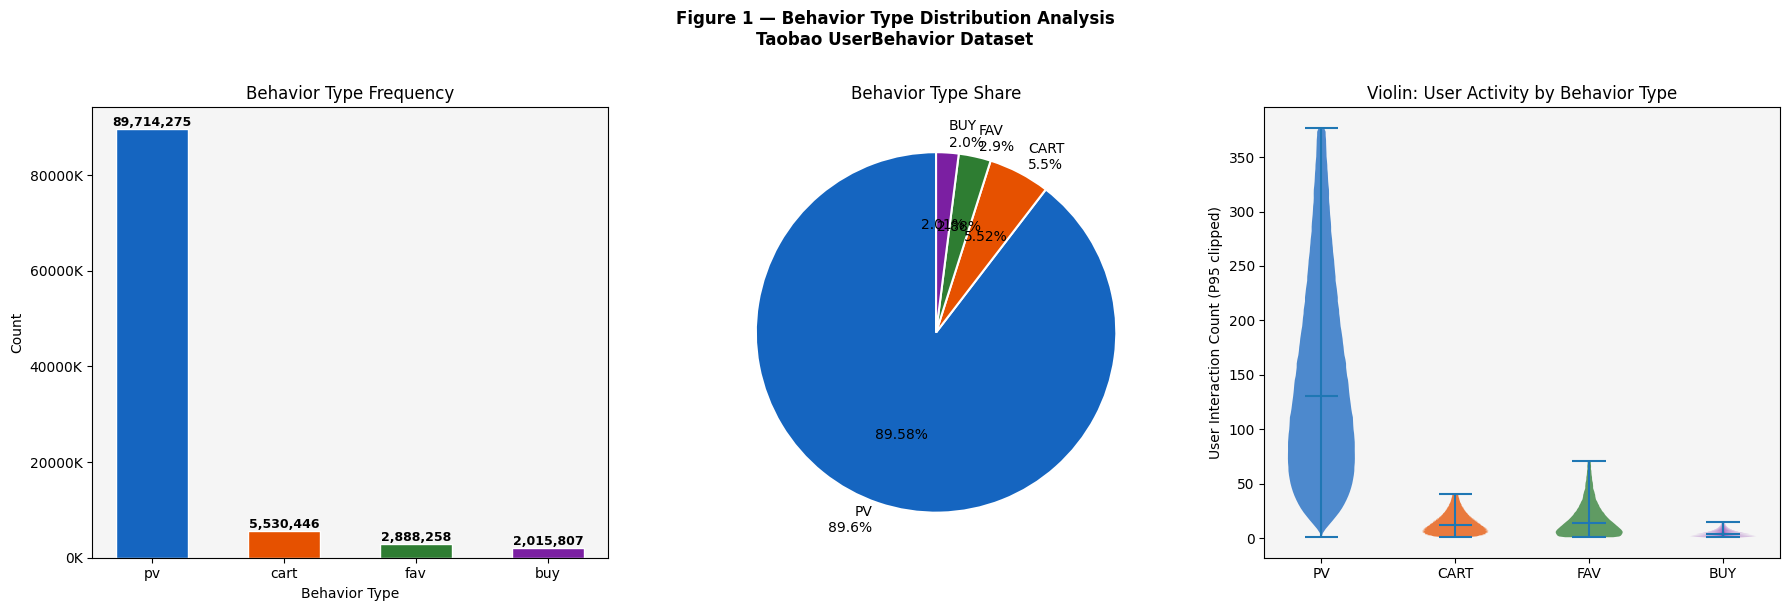

In [ ]:
print("Figure 1 — Behavior Distribution …")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Figure 1 — Behavior Type Distribution Analysis\nTaobao UserBehavior Dataset',
             fontweight='bold', y=1.01)

# Define colors for behavior types, using existing COLORS or PALETTE if available
# Since PALETTE did not have 'pv', 'cart', 'fav', 'buy', we'll define them here or use COLORS.
# Assuming the intent is to use distinct colors for these behavior types.
# We can add them to PALETTE or directly use a list of colors.
# For consistency with other plots, let's define them using the COLORS list.
PALETTE['pv'] = COLORS[0]
PALETTE['cart'] = COLORS[1]
PALETTE['fav'] = COLORS[2]
PALETTE['buy'] = COLORS[3]

bt_colors = [PALETTE['pv'], PALETTE['cart'], PALETTE['fav'], PALETTE['buy']]
bt_order = ['pv', 'cart', 'fav', 'buy']
bt_vals_ordered = [bt_counts.get(b, 0) for b in bt_order]

ax = axes[0]
bars = ax.bar(bt_order, bt_vals_ordered, color=bt_colors, edgecolor='white', width=0.55)
ax.set_xlabel('Behavior Type'); ax.set_ylabel('Count')
ax.set_title('Behavior Type Frequency')
for bar, val in zip(bars, bt_vals_ordered):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2000,
            f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1e3)}K'))
ax.set_facecolor(PALETTE['bg'])

ax2 = axes[1]
ax2.pie(bt_vals_ordered, labels=[f'{b.upper()}\n{v/n_interactions*100:.1f}%' for b, v in zip(bt_order, bt_vals_ordered)],
        colors=bt_colors, autopct='%1.2f%%', startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax2.set_title('Behavior Type Share')

# Violin: user interaction count by behavior
ax3 = axes[2]
vp_data = [df_clean[df_clean['behavior_type'] == bt]['user_id'].map(
    df_clean[df_clean['behavior_type'] == bt]['user_id'].value_counts()).values
    for bt in bt_order]
vp_data = [d[d <= np.percentile(d, 95)] for d in vp_data]  # clip top 5%
vp_obj = ax3.violinplot(vp_data, positions=range(1, 5), showmedians=True)
for i, pc in enumerate(vp_obj['bodies']):
    pc.set_facecolor(bt_colors[i]); pc.set_alpha(0.75)
ax3.set_xticks(range(1, 5)); ax3.set_xticklabels([b.upper() for b in bt_order])
ax3.set_ylabel('User Interaction Count (P95 clipped)')
ax3.set_title('Violin: User Activity by Behavior Type')
ax3.set_facecolor(PALETTE['bg'])

plt.tight_layout()
# plt.savefig(f'{OUT_DIR}/fig01_behavior_distribution.png', bbox_inches='tight', dpi=DPI)
# plt.close()
plt.show()

Figure 2 — Interaction Distributions …


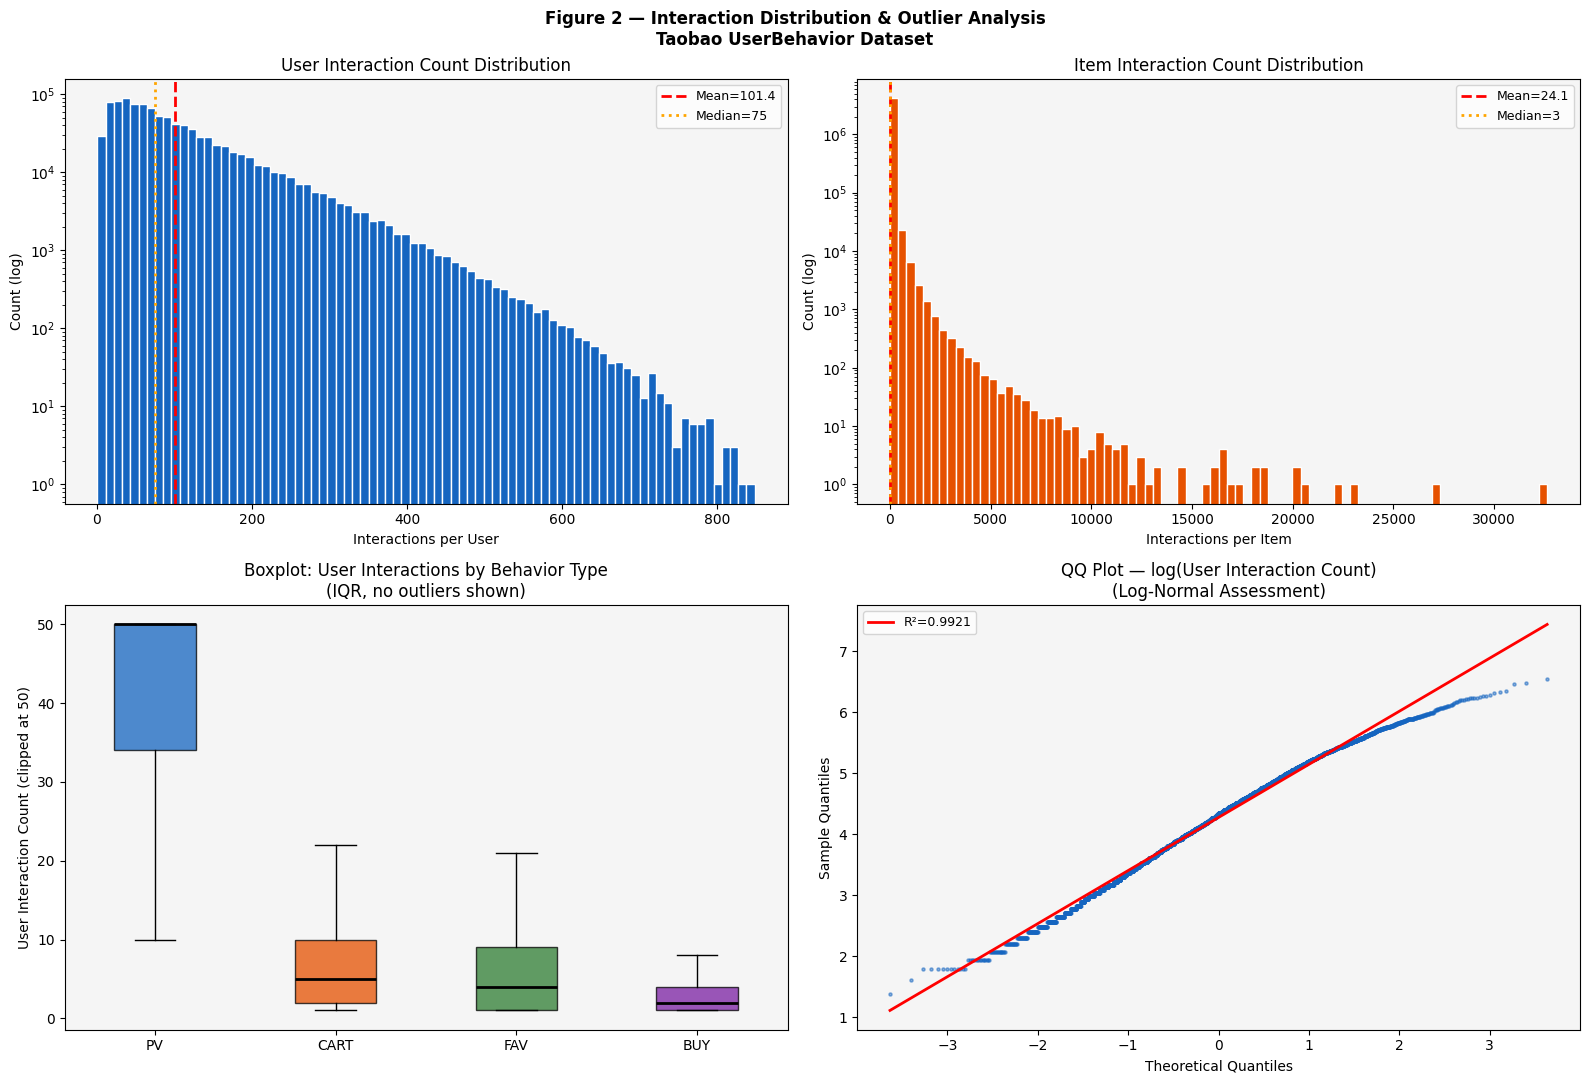

In [ ]:
print("Figure 2 — Interaction Distributions …")
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Figure 2 — Interaction Distribution & Outlier Analysis\nTaobao UserBehavior Dataset',
             fontweight='bold')

ax = axes[0, 0]
ax.hist(user_counts, bins=80, color=PALETTE['primary'], edgecolor='white', log=True)
ax.axvline(user_counts.mean(), color='red', linestyle='--', lw=2,
           label=f'Mean={user_counts.mean():.1f}')
ax.axvline(user_counts.median(), color='orange', linestyle=':', lw=2,
           label=f'Median={user_counts.median():.0f}')
ax.set_xlabel('Interactions per User'); ax.set_ylabel('Count (log)')
ax.set_title('User Interaction Count Distribution')
ax.legend(fontsize=9); ax.set_facecolor(PALETTE['bg'])

ax2 = axes[0, 1]
ax2.hist(item_counts, bins=80, color=PALETTE['secondary'], edgecolor='white', log=True)
ax2.axvline(item_counts.mean(), color='red', linestyle='--', lw=2,
            label=f'Mean={item_counts.mean():.1f}')
ax2.axvline(item_counts.median(), color='orange', linestyle=':', lw=2,
            label=f'Median={item_counts.median():.0f}')
ax2.set_xlabel('Interactions per Item'); ax2.set_ylabel('Count (log)')
ax2.set_title('Item Interaction Count Distribution')
ax2.legend(fontsize=9); ax2.set_facecolor(PALETTE['bg'])

# Boxplot: user count per behavior
ax3 = axes[1, 0]
box_data = [df_clean[df_clean['behavior_type'] == bt].groupby('user_id').size().clip(upper=50).values
            for bt in bt_order]
bp = ax3.boxplot(box_data, labels=[b.upper() for b in bt_order],
                 patch_artist=True, showfliers=False,
                 medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], bt_colors):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax3.set_ylabel('User Interaction Count (clipped at 50)')
ax3.set_title('Boxplot: User Interactions by Behavior Type\n(IQR, no outliers shown)')
ax3.set_facecolor(PALETTE['bg'])

# QQ plot for user_counts
ax4 = axes[1, 1]
sample_uc = np.random.choice(user_counts.values, min(5000, len(user_counts)), replace=False)
log_uc = np.log1p(sample_uc)
(osm, osr), (slope, intercept, r) = probplot(log_uc, dist='norm')
ax4.scatter(osm, osr, color=PALETTE['primary'], s=5, alpha=0.5)
ax4.plot(osm, slope * np.array(osm) + intercept, color='red', lw=2, label=f'R²={r**2:.4f}')
ax4.set_xlabel('Theoretical Quantiles'); ax4.set_ylabel('Sample Quantiles')
ax4.set_title('QQ Plot — log(User Interaction Count)\n(Log-Normal Assessment)')
ax4.legend(fontsize=9); ax4.set_facecolor(PALETTE['bg'])

plt.tight_layout()
# plt.savefig(f'{OUT_DIR}/fig02_interaction_distributions.png', bbox_inches='tight', dpi=DPI)
# plt.close()
plt.show()

The user interaction per user and per item are extremely right skewed with low median which suggests that half of the users have only one interaction, which creates a cold-start problem for the recommendation algorithms that have to rely on content-based features and demographic information.

Figure 3 — Temporal Patterns …


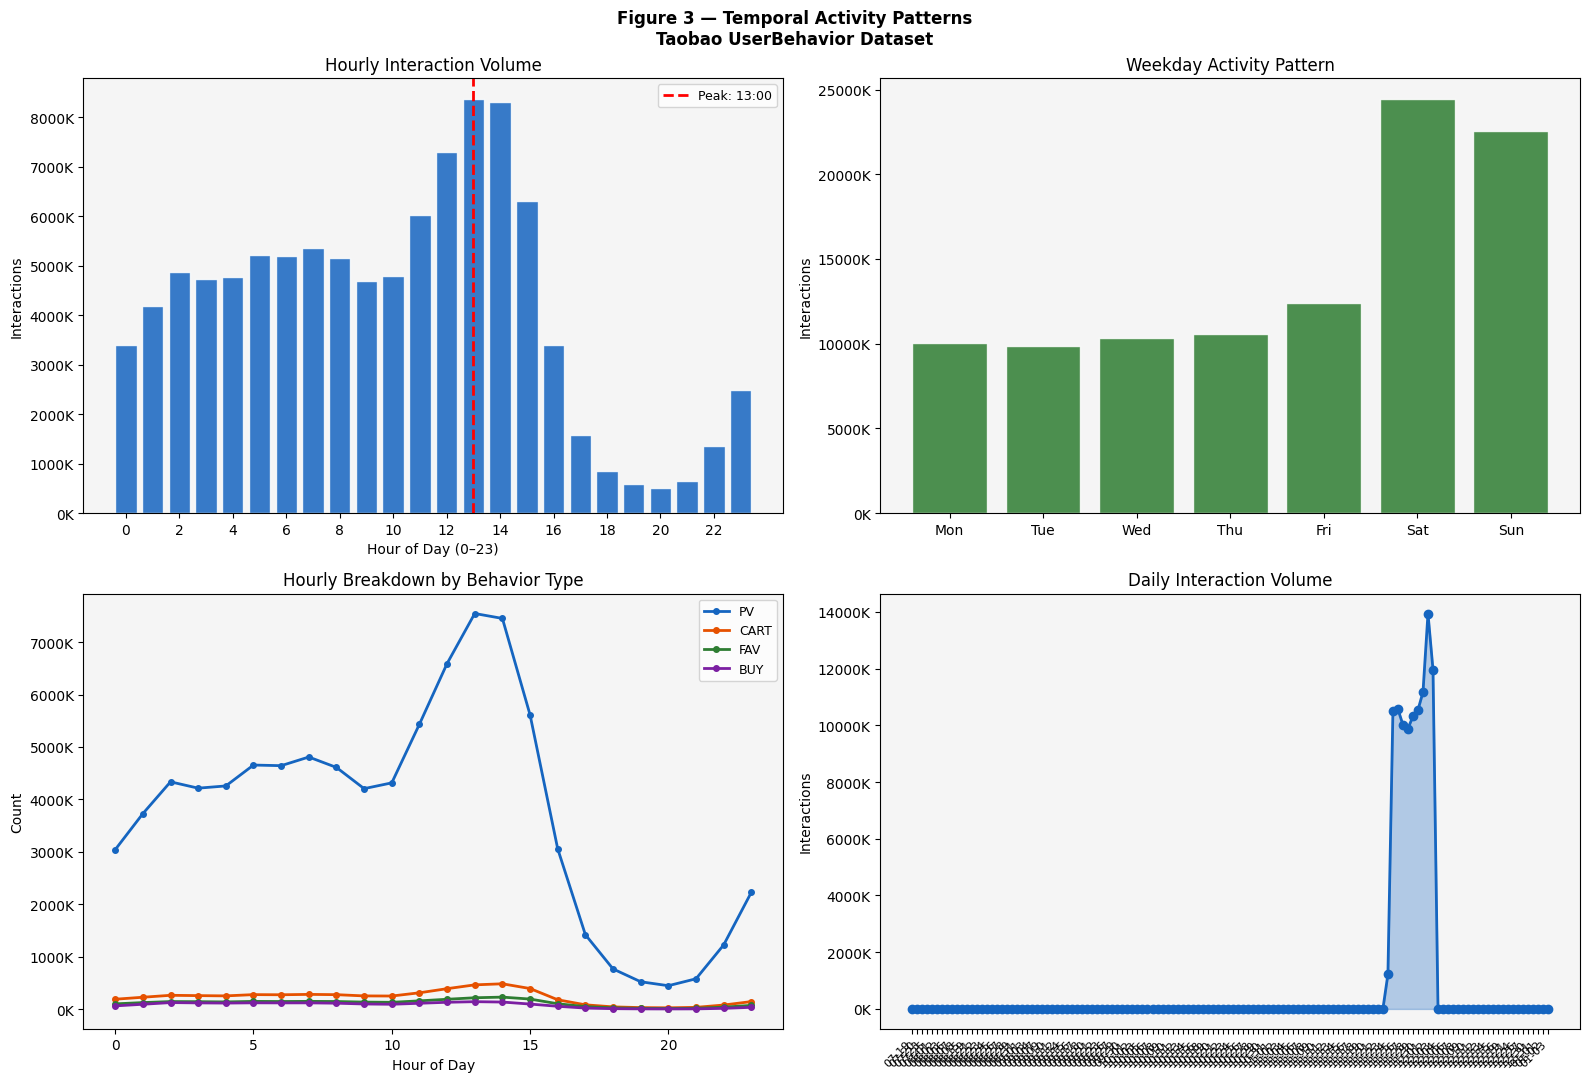

In [ ]:
print("Figure 3 — Temporal Patterns …")
hourly = df_clean.groupby('hour').size()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_counts = df_clean['weekday'].value_counts().reindex(weekday_order)
daily = df_clean.groupby('date').size()
pv_daily = df_clean[df_clean['behavior_type'] == 'pv'].groupby('date').size()

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Figure 3 — Temporal Activity Patterns\nTaobao UserBehavior Dataset', fontweight='bold')

ax = axes[0, 0]
ax.bar(range(24), [hourly.get(h, 0) for h in range(24)],
       color=PALETTE['primary'], edgecolor='white', alpha=0.85)
ax.set_xlabel('Hour of Day (0–23)'); ax.set_ylabel('Interactions')
ax.set_title('Hourly Interaction Volume')
ax.set_xticks(range(0, 24, 2))
peak_hour = hourly.idxmax()
ax.axvline(peak_hour, color='red', linestyle='--', lw=2, label=f'Peak: {peak_hour}:00')
ax.legend(fontsize=9); ax.set_facecolor(PALETTE['bg'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1e3)}K'))

ax2 = axes[0, 1]
ax2.bar(range(7), weekday_counts.values, color=PALETTE['accent'], edgecolor='white', alpha=0.85)
ax2.set_xticks(range(7))
ax2.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
ax2.set_ylabel('Interactions'); ax2.set_title('Weekday Activity Pattern')
ax2.set_facecolor(PALETTE['bg'])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1e3)}K'))

ax3 = axes[1, 0]
bt_hourly = df_clean.groupby(['hour', 'behavior_type']).size().unstack(fill_value=0)
for bt, color in zip(bt_order, bt_colors):
    if bt in bt_hourly.columns:
        ax3.plot(bt_hourly.index, bt_hourly[bt], color=color, lw=2, marker='o',
                 markersize=4, label=bt.upper())
ax3.set_xlabel('Hour of Day'); ax3.set_ylabel('Count')
ax3.set_title('Hourly Breakdown by Behavior Type')
ax3.legend(fontsize=9); ax3.set_facecolor(PALETTE['bg'])
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1e3)}K'))

ax4 = axes[1, 1]
ax4.fill_between(range(len(daily)), daily.values, alpha=0.3, color=PALETTE['primary'])
ax4.plot(range(len(daily)), daily.values, color=PALETTE['primary'], lw=2, marker='o', markersize=6)
ax4.set_xticks(range(len(daily)))
ax4.set_xticklabels([str(d)[5:] for d in daily.index], rotation=45, ha='right', fontsize=8)
ax4.set_ylabel('Interactions'); ax4.set_title('Daily Interaction Volume')
ax4.set_facecolor(PALETTE['bg'])
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1e3)}K'))

plt.tight_layout()
# plt.savefig(f'{OUT_DIR}/fig03_temporal_patterns.png', bbox_inches='tight', dpi=DPI)
# plt.close()
plt.show()

Temporal analysis reveals distinct diurnal patterns in user activity, reflecting the daily rythms of e-commerce engagement. The pattern suggests time-senstive recommendation approaches based on the time of the day.

Figure 4 — Conversion Funnel …


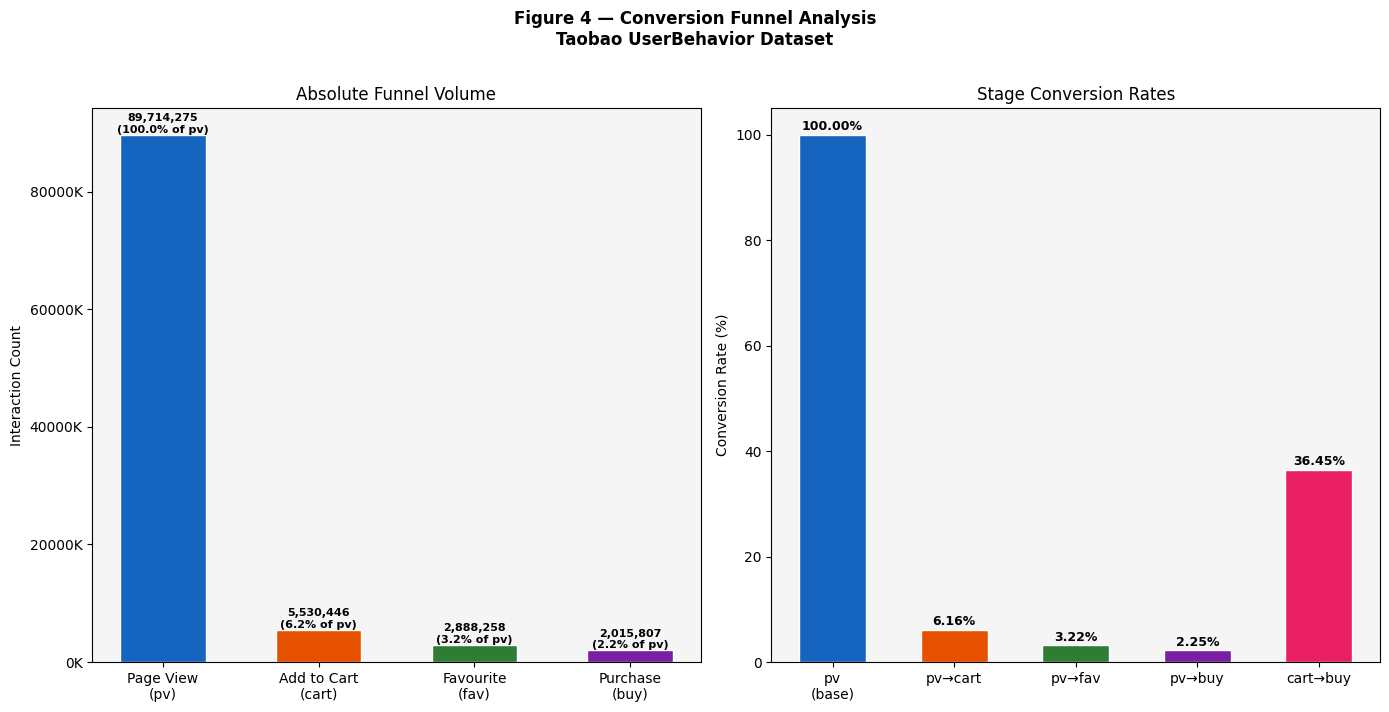

In [ ]:
print("Figure 4 — Conversion Funnel …")
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle('Figure 4 — Conversion Funnel Analysis\nTaobao UserBehavior Dataset',
             fontweight='bold', y=1.01)

funnel_vals = [pv_c, cart_c, fav_c, buy_c]
funnel_labels = ['Page View\n(pv)', 'Add to Cart\n(cart)', 'Favourite\n(fav)', 'Purchase\n(buy)']
cvrs = [100, cvr_cart, cvr_fav, cvr_buy]

ax = axes[0]
bars = ax.bar(funnel_labels, funnel_vals, color=bt_colors, edgecolor='white', width=0.55)
ax.set_ylabel('Interaction Count'); ax.set_title('Absolute Funnel Volume')
for bar, val, cvr in zip(bars, funnel_vals, cvrs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1000,
            f'{val:,}\n({cvr:.1f}% of pv)', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1e3)}K'))
ax.set_facecolor(PALETTE['bg'])

ax2 = axes[1]
stage_cvrs = [100, cvr_cart, cvr_fav, cvr_buy, cvr_cart2buy]
stage_labels = ['pv\n(base)', 'pv→cart', 'pv→fav', 'pv→buy', 'cart→buy']
stage_colors = [PALETTE['pv'], PALETTE['cart'], PALETTE['fav'], PALETTE['buy'], '#E91E63']
bars2 = ax2.bar(stage_labels, stage_cvrs, color=stage_colors, edgecolor='white', width=0.55)
ax2.set_ylabel('Conversion Rate (%)'); ax2.set_title('Stage Conversion Rates')
for bar, val in zip(bars2, stage_cvrs):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f'{val:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_facecolor(PALETTE['bg'])

plt.tight_layout()
# plt.savefig(f'{OUT_DIR}/fig04_conversion_funnel.png', bbox_inches='tight', dpi=DPI)
# plt.close()
plt.show()

TThis is a comprehensive analysis of the conversion funnel, showing both the volume of interactions at each stage and the conversion rates between stages. It is citical for designing recommendation systems to support users at different stages of the purchase journey.

Figure 5 — Sparsity & k-core …
  k=1: 987,993 users, 4,161,995 items, 100,148,786 interactions
  k=2: 987,883 users, 2,954,864 items, 98,941,550 interactions
  k=3: 987,639 users, 2,394,852 items, 97,821,066 interactions
  k=5: 984,950 users, 1,807,531 items, 95,806,879 interactions
  k=10: 959,757 users, 1,180,765 items, 91,480,816 interactions


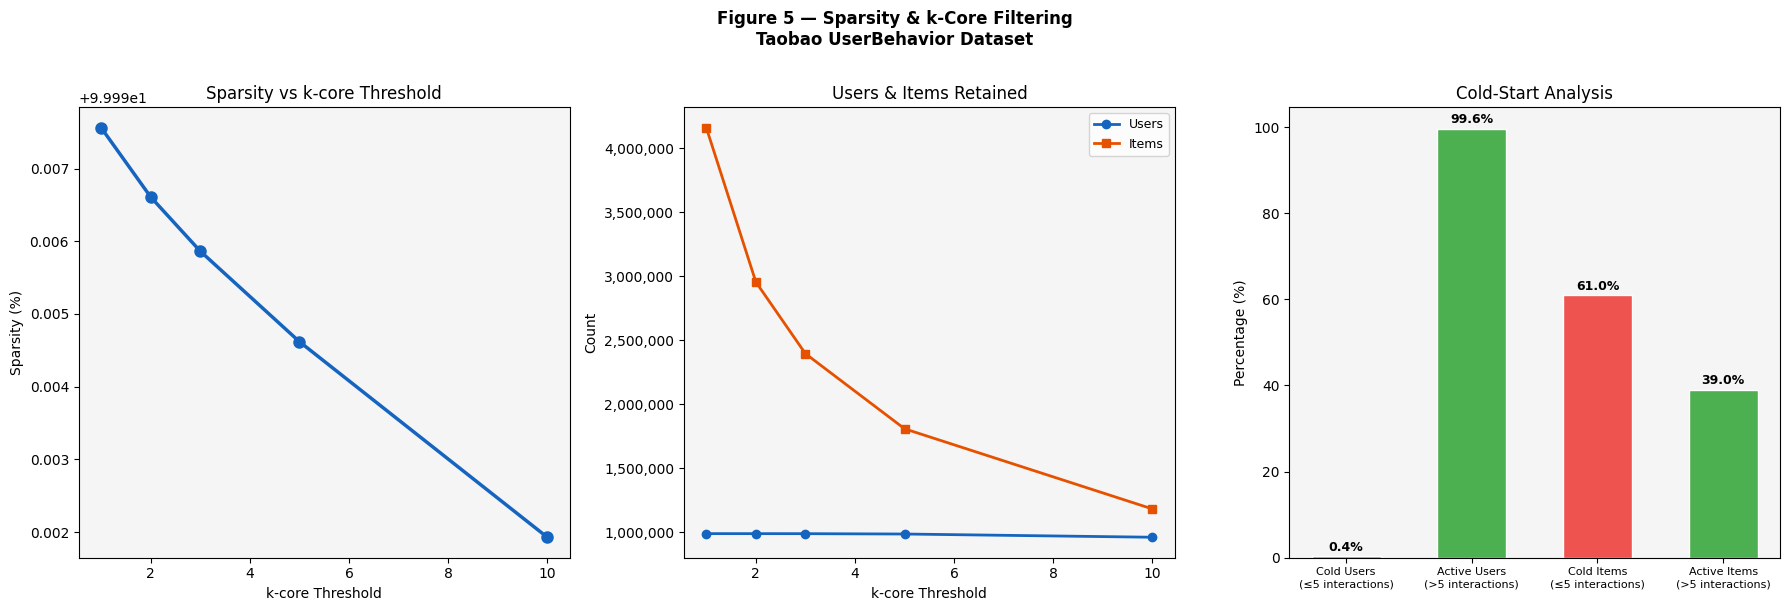

In [ ]:
print("Figure 5 — Sparsity & k-core …")
def kcore(df, k):
    for _ in range(10):
        u = df['user_id'].value_counts()
        i = df['item_id'].value_counts()
        df2 = df[df['user_id'].isin(u[u >= k].index) & df['item_id'].isin(i[i >= k].index)]
        if len(df2) == len(df): break
        df = df2
    return df

kcore_stats = []
for k in [1, 2, 3, 5, 10]:
    sub = kcore(df_clean, k)
    nu = sub['user_id'].nunique()
    ni = sub['item_id'].nunique()
    nr = len(sub)
    sp = 1 - nr / (nu * ni) if nu * ni > 0 else 1.0
    kcore_stats.append({'k': k, 'users': nu, 'items': ni, 'interactions': nr, 'sparsity': round(sp, 8)})
    print(f"  k={k}: {nu:,} users, {ni:,} items, {nr:,} interactions")

cs_user_pct = float((user_counts <= 5).mean() * 100)
cs_item_pct = float((item_counts <= 5).mean() * 100)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Figure 5 — Sparsity & k-Core Filtering\nTaobao UserBehavior Dataset',
             fontweight='bold', y=1.01)

ks = [s['k'] for s in kcore_stats]
ax = axes[0]
ax.plot(ks, [s['sparsity'] * 100 for s in kcore_stats], 'o-',
        color=PALETTE['primary'], lw=2.5, markersize=8)
ax.set_xlabel('k-core Threshold'); ax.set_ylabel('Sparsity (%)')
ax.set_title('Sparsity vs k-core Threshold'); ax.set_facecolor(PALETTE['bg'])

ax2 = axes[1]
ax2.plot(ks, [s['users'] for s in kcore_stats], 'o-', color=PALETTE['primary'], lw=2, label='Users')
ax2.plot(ks, [s['items'] for s in kcore_stats], 's-', color=PALETTE['secondary'], lw=2, label='Items')
ax2.set_xlabel('k-core Threshold'); ax2.set_ylabel('Count')
ax2.set_title('Users & Items Retained'); ax2.legend(fontsize=9)
ax2.set_facecolor(PALETTE['bg'])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Cold-start bar
ax3 = axes[2]
cs_data = {
    'Cold Users\n(≤5 interactions)': cs_user_pct,
    'Active Users\n(>5 interactions)': 100 - cs_user_pct,
    'Cold Items\n(≤5 interactions)': cs_item_pct,
    'Active Items\n(>5 interactions)': 100 - cs_item_pct,
}
colors_cs = ['#EF5350', '#4CAF50', '#EF5350', '#4CAF50']
bars_cs = ax3.bar(range(4), list(cs_data.values()), color=colors_cs, edgecolor='white', width=0.55)
ax3.set_xticks(range(4)); ax3.set_xticklabels(list(cs_data.keys()), fontsize=8)
ax3.set_ylabel('Percentage (%)'); ax3.set_title('Cold-Start Analysis')
for bar, val in zip(bars_cs, cs_data.values()):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax3.set_facecolor(PALETTE['bg'])

plt.tight_layout()
# plt.savefig(f'{OUT_DIR}/fig05_sparsity_kcore.png', bbox_inches='tight', dpi=DPI)
# plt.close()
plt.show()

The k-core analysis reveals fundamental challenges for collaborative filtering approaches. Data sparsity increases with low k values and decreases with higher k values. Increasing density through k-core filtering improves the feasibility of collaborative filtering but dramatically redices the coverage of users and items that can receive recommendations. The cold-start analysis shows 99.6% active users do not have sufficient interaction with products in the catalog. This is particularly challenging for fashion recommendation.  

# **CORRELATION AND RELATIONSHIPS**

In [ ]:
# 4a. Numeric correlation: user_count, item_count, hour, weekday
user_agg = df_clean.groupby('user_id').agg(
    n_interactions=('item_id', 'count'),
    n_unique_items=('item_id', 'nunique'),
    n_unique_cats=('category_id', 'nunique'),
    pv_count=('behavior_type', lambda x: (x == 'pv').sum()),
    buy_count=('behavior_type', lambda x: (x == 'buy').sum()),
    fav_count=('behavior_type', lambda x: (x == 'fav').sum()),
    cart_count=('behavior_type', lambda x: (x == 'cart').sum()),
).reset_index()
user_agg['buy_rate'] = user_agg['buy_count'] / user_agg['n_interactions']
user_agg['diversity_score'] = user_agg['n_unique_cats'] / user_agg['n_interactions']

numeric_cols = ['n_interactions', 'n_unique_items', 'n_unique_cats', 'buy_count', 'buy_rate']
corr_mat = user_agg[numeric_cols].corr()
print("\n[4a] Pearson Correlation Matrix (user-level aggregates):")
print(corr_mat.round(4).to_string())

# 4b. Chi-square: behavior_type × is_weekend
ct_chi = pd.crosstab(df_clean['behavior_type'], df_clean['is_weekend'])
chi2_val, p_chi, dof_chi, _ = chi2_contingency(ct_chi)
n_chi = ct_chi.values.sum()
cramers_v = np.sqrt(chi2_val / (n_chi * (min(ct_chi.shape) - 1)))
print(f"\n[4b] Chi-Square: behavior_type × is_weekend  χ²={chi2_val:.2f}  p={p_chi:.4e}  Cramer's V={cramers_v:.4f}")

# 4c. Chi-square: behavior_type × hour_bin
ct_hr_chi = pd.crosstab(df_clean['behavior_type'], df_clean['hour_bin'])
chi2_hr, p_hr, dof_hr, _ = chi2_contingency(ct_hr_chi)
n_hr = ct_hr_chi.values.sum()
cv_hr = np.sqrt(chi2_hr / (n_hr * (min(ct_hr_chi.shape) - 1)))
print(f"\n[4c] Chi-Square: behavior_type × hour_bin  χ²={chi2_hr:.2f}  p={p_hr:.4e}  Cramer's V={cv_hr:.4f}")

# 4d. Point-biserial: is_weekend vs buy_rate
pb_r, pb_p = pointbiserialr(
    df_clean['is_weekend'],
    df_clean['user_id'].map(user_agg.set_index('user_id')['buy_rate']).fillna(0)
)
print(f"\n[4d] Point-Biserial: is_weekend vs user buy_rate  r={pb_r:.4f}  p={pb_p:.4e}")

# 4e. Grouped summary: buy rate by hour
hourly_buy_rate = df_clean.groupby('hour').apply(
    lambda x: (x['behavior_type'] == 'buy').sum() / len(x) * 100
)
print(f"\n[4e] Peak buy-rate hour: {hourly_buy_rate.idxmax()} ({hourly_buy_rate.max():.2f}%)")


[4a] Pearson Correlation Matrix (user-level aggregates):
                n_interactions  n_unique_items  n_unique_cats  buy_count  buy_rate
n_interactions          1.0000          0.9767         0.7526     0.2747   -0.2304
n_unique_items          0.9767          1.0000         0.7965     0.2331   -0.2458
n_unique_cats           0.7526          0.7965         1.0000     0.3021   -0.1763
buy_count               0.2747          0.2331         0.3021     1.0000    0.4943
buy_rate               -0.2304         -0.2458        -0.1763     0.4943    1.0000

[4b] Chi-Square: behavior_type × is_weekend  χ²=3043.39  p=0.0000e+00  Cramer's V=0.0055

[4c] Chi-Square: behavior_type × hour_bin  χ²=66707.37  p=0.0000e+00  Cramer's V=0.0152

[4d] Point-Biserial: is_weekend vs user buy_rate  r=-0.0055  p=0.0000e+00

[4e] Peak buy-rate hour: 2 (2.62%)


Figure 6 — Correlation & Relationships …


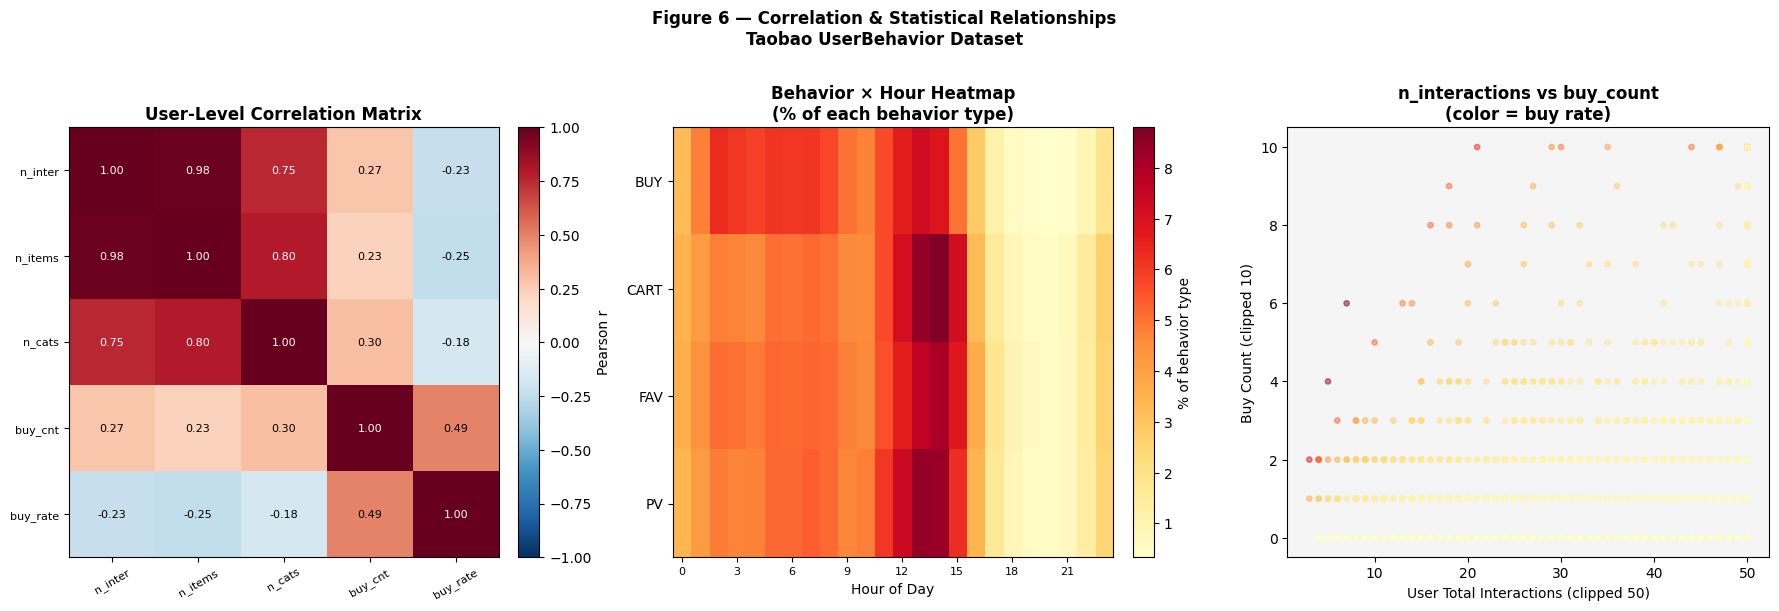

In [ ]:
print("Figure 6 — Correlation & Relationships …")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Figure 6 — Correlation & Statistical Relationships\nTaobao UserBehavior Dataset',
             fontweight='bold', y=1.01)

ax = axes[0]
im = ax.imshow(corr_mat.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols))); ax.set_yticks(range(len(numeric_cols)))
short = ['n_inter', 'n_items', 'n_cats', 'buy_cnt', 'buy_rate']
ax.set_xticklabels(short, rotation=30, fontsize=8)
ax.set_yticklabels(short, fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Pearson r')
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f'{corr_mat.values[i,j]:.2f}', ha='center', va='center',
                fontsize=8, color='white' if abs(corr_mat.values[i,j]) > 0.5 else 'black')
ax.set_title('User-Level Correlation Matrix', fontweight='bold')

# Heatmap: behavior × hour
ax2 = axes[1]
bt_hr = df_clean.groupby(['behavior_type', 'hour']).size().unstack(fill_value=0)
bt_hr_norm = bt_hr.div(bt_hr.sum(axis=1), axis=0) * 100
im2 = ax2.imshow(bt_hr_norm.values, cmap='YlOrRd', aspect='auto')
ax2.set_xticks(range(0, 24, 3)); ax2.set_xticklabels(range(0, 24, 3), fontsize=8)
ax2.set_yticks(range(len(bt_hr_norm.index)))
ax2.set_yticklabels([b.upper() for b in bt_hr_norm.index])
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04, label='% of behavior type')
ax2.set_xlabel('Hour of Day'); ax2.set_title('Behavior × Hour Heatmap\n(% of each behavior type)', fontweight='bold')

# Scatter: n_interactions vs buy_count (user level)
ax3 = axes[2]
sample_u = user_agg.sample(min(5000, len(user_agg)), random_state=42)
ax3.scatter(sample_u['n_interactions'].clip(0, 50), sample_u['buy_count'].clip(0, 10),
            c=sample_u['buy_rate'], cmap='YlOrRd', s=15, alpha=0.5)
ax3.set_xlabel('User Total Interactions (clipped 50)'); ax3.set_ylabel('Buy Count (clipped 10)')
ax3.set_title('n_interactions vs buy_count\n(color = buy rate)', fontweight='bold')
ax3.set_facecolor(PALETTE['bg'])

plt.tight_layout()
# plt.savefig(f'{OUT_DIR}/fig06_correlation_relationships.png', bbox_inches='tight', dpi=DPI)
# plt.close()
plt.show()

There is a weak correlation and relationship between most variable, behavior-hour interaction patterns, and weak positve number of interaction and purchase propensity.

# **TARGET VARIABLE ANALYSIS**


 Target Variable Distribution:
  pv: 89.58%
  cart: 5.52%
  fav: 2.88%
  buy: 2.01%

 Imbalance Ratio: 44.5x  (pv vs buy)
  Assessment: Severe imbalance — oversampling/class weighting recommended for modeling

 Stratified Feature Analysis by Behavior:

  Mean hour by behavior_type:
behavior_type
buy     8.760
cart    9.764
fav     9.596
pv      9.660

  Mean is_weekend by behavior_type:
behavior_type
buy     0.452
cart    0.474
fav     0.469
pv      0.469
Figure 7 — Target Variable Analysis …


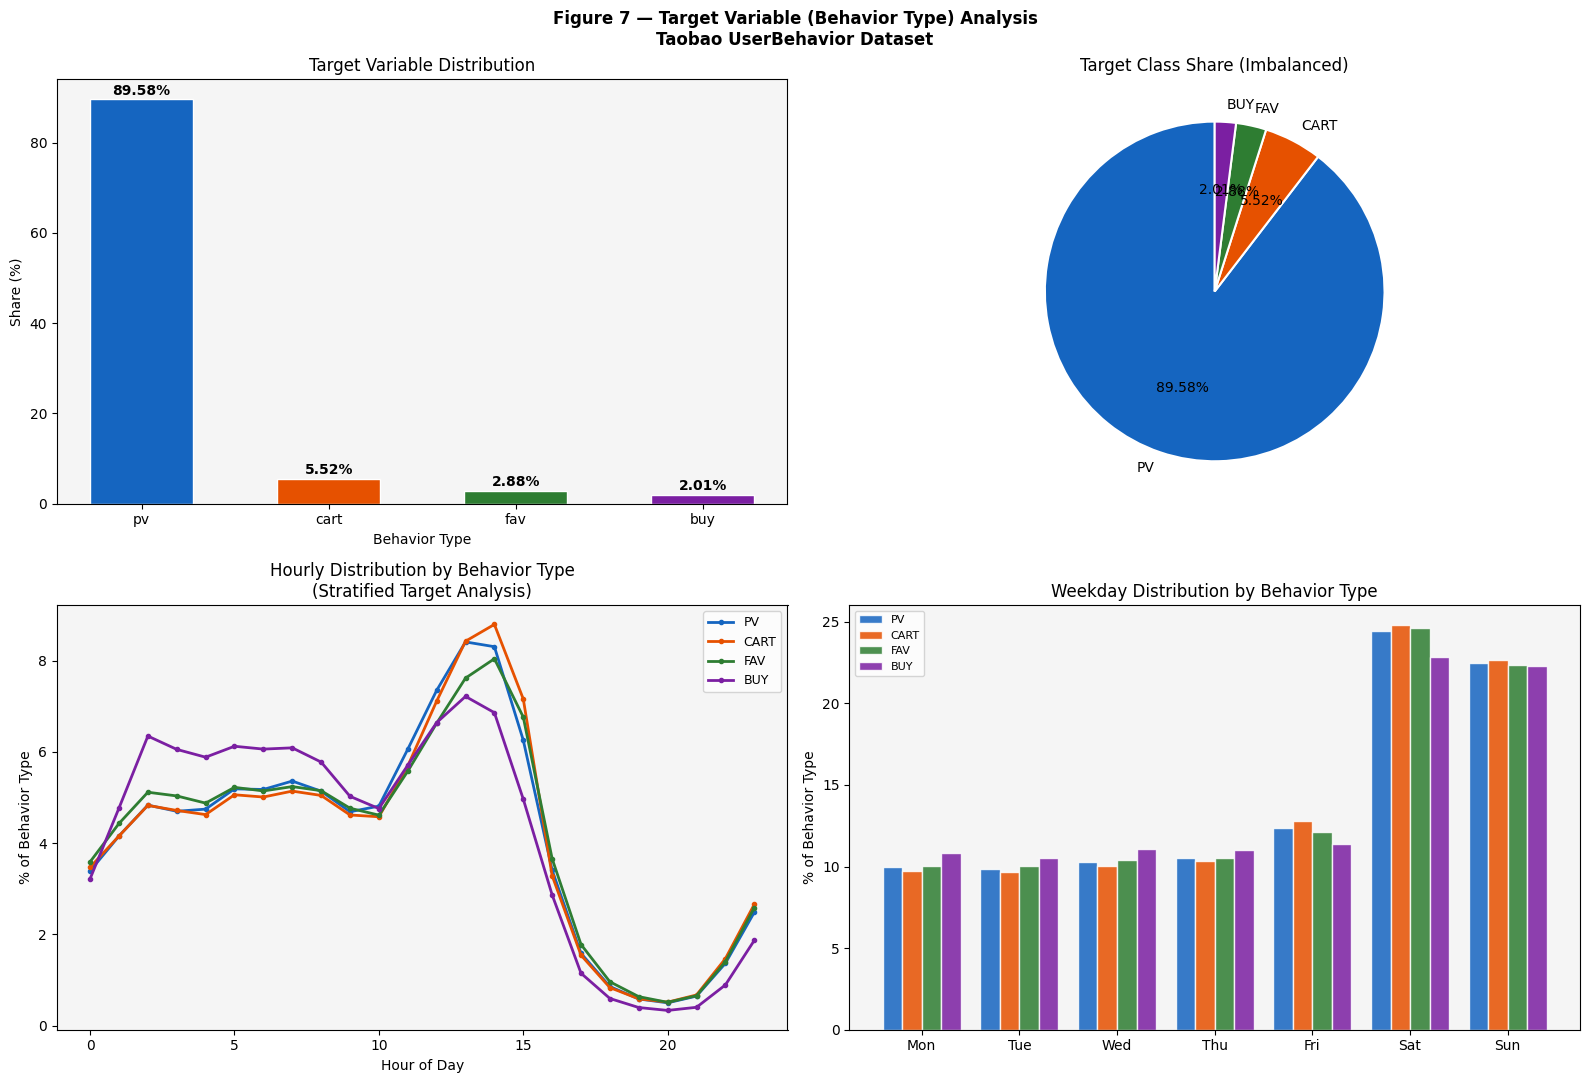

In [ ]:
# Target: behavior_type (4-class classification)
print("\n Target Variable Distribution:")
bt_pct = df_clean['behavior_type'].value_counts(normalize=True) * 100
for bt, pct in bt_pct.items():
    print(f"  {bt}: {pct:.2f}%")

imbalance_ratio = bt_pct.max() / bt_pct.min()
print(f"\n Imbalance Ratio: {imbalance_ratio:.1f}x  ({bt_pct.idxmax()} vs {bt_pct.idxmin()})")
print(f"  Assessment: Severe imbalance — oversampling/class weighting recommended for modeling")

print("\n Stratified Feature Analysis by Behavior:")
for col in ['hour', 'is_weekend']:
    print(f"\n  Mean {col} by behavior_type:")
    print(df_clean.groupby('behavior_type')[col].mean().round(3).to_string())

# Figure 7 — Target Variable Analysis
print("Figure 7 — Target Variable Analysis …")
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Figure 7 — Target Variable (Behavior Type) Analysis\nTaobao UserBehavior Dataset',
             fontweight='bold')

ax = axes[0, 0]
bars = ax.bar(bt_order, [bt_pct.get(b, 0) for b in bt_order],
              color=bt_colors, edgecolor='white', width=0.55)
ax.set_xlabel('Behavior Type'); ax.set_ylabel('Share (%)')
ax.set_title('Target Variable Distribution')
for bar, val in zip(bars, [bt_pct.get(b, 0) for b in bt_order]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_facecolor(PALETTE['bg'])

ax2 = axes[0, 1]
ax2.pie([bt_counts.get(b, 0) for b in bt_order],
        labels=[b.upper() for b in bt_order], colors=bt_colors,
        autopct='%1.2f%%', startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax2.set_title('Target Class Share (Imbalanced)')

# Stratified: hour distribution by behavior
ax3 = axes[1, 0]
bt_hr_abs = df_clean.groupby(['behavior_type', 'hour']).size().unstack(fill_value=0)
for bt, color in zip(bt_order, bt_colors):
    if bt in bt_hr_abs.index:
        row = bt_hr_abs.loc[bt]
        row_norm = row / row.sum() * 100
        ax3.plot(row_norm.index, row_norm.values, color=color, lw=2, label=bt.upper(), marker='o', markersize=3)
ax3.set_xlabel('Hour of Day'); ax3.set_ylabel('% of Behavior Type')
ax3.set_title('Hourly Distribution by Behavior Type\n(Stratified Target Analysis)')
ax3.legend(fontsize=9); ax3.set_facecolor(PALETTE['bg'])

# Weekday breakdown by behavior
ax4 = axes[1, 1]
bt_wd = df_clean.groupby(['behavior_type', 'weekday']).size().unstack(fill_value=0)
bt_wd = bt_wd.reindex(columns=weekday_order, fill_value=0)
bt_wd_norm = bt_wd.div(bt_wd.sum(axis=1), axis=0) * 100
x = np.arange(7)
w = 0.2
for i, (bt, color) in enumerate(zip(bt_order, bt_colors)):
    if bt in bt_wd_norm.index:
        ax4.bar(x + (i - 1.5) * w, bt_wd_norm.loc[bt].values, w, label=bt.upper(),
                color=color, edgecolor='white', alpha=0.85)
ax4.set_xticks(x)
ax4.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
ax4.set_ylabel('% of Behavior Type')
ax4.set_title('Weekday Distribution by Behavior Type')
ax4.legend(fontsize=8); ax4.set_facecolor(PALETTE['bg'])

plt.tight_layout()
# plt.savefig(f'{OUT_DIR}/fig07_target_variable_analysis.png', bbox_inches='tight', dpi=DPI)
# plt.close()
plt.show()

There is a severe target (Behavior Type) class imbalance with 2.01% purchase (buy) rate conversion. The uniformity across weekdays and weekends aligns with the correlation analysis and suggests that temporal features at the day-of-week level providing value for purchase behavior.

# **FEATURE ENGINEERING**

In [ ]:
#  User-level behavioral features
print(" Creating user-level features …")
user_feat = df_clean.groupby('user_id').agg(
    total_interactions=('item_id', 'count'),
    unique_items=('item_id', 'nunique'),
    unique_categories=('category_id', 'nunique'),
    pv_count=('behavior_type', lambda x: (x == 'pv').sum()),
    cart_count=('behavior_type', lambda x: (x == 'cart').sum()),
    fav_count=('behavior_type', lambda x: (x == 'fav').sum()),
    buy_count=('behavior_type', lambda x: (x == 'buy').sum()),
    peak_hour=('hour', lambda x: x.mode()[0] if len(x) > 0 else 0),
    weekend_rate=('is_weekend', 'mean'),
).reset_index()

user_feat['buy_rate']         = user_feat['buy_count'] / user_feat['total_interactions']
user_feat['cart_rate']        = user_feat['cart_count'] / user_feat['total_interactions']
user_feat['cart_to_buy_cvr']  = np.where(user_feat['cart_count'] > 0,
                                          user_feat['buy_count'] / user_feat['cart_count'], 0)
user_feat['diversity_score']  = user_feat['unique_categories'] / user_feat['total_interactions']
user_feat['is_buyer']         = (user_feat['buy_count'] > 0).astype(int)
user_feat['activity_segment'] = pd.cut(
    user_feat['total_interactions'],
    bins=[0, 2, 5, 10, 20, np.inf],
    labels=['cold_start', 'low', 'medium', 'high', 'power']
)
print(f"  User features: {list(user_feat.columns)}")

#  Item-level features
item_feat = df_clean.groupby('item_id').agg(
    total_interactions=('user_id', 'count'),
    unique_users=('user_id', 'nunique'),
    pv_count=('behavior_type', lambda x: (x == 'pv').sum()),
    buy_count=('behavior_type', lambda x: (x == 'buy').sum()),
    category=('category_id', 'first'),
).reset_index()
item_feat['buy_rate'] = item_feat['buy_count'] / item_feat['total_interactions']
print(f"  Item features: {list(item_feat.columns)}")

#  Encoding
le_bt = LabelEncoder()
df_clean['behavior_encoded'] = le_bt.fit_transform(df_clean['behavior_type'])
le_wd = LabelEncoder()
df_clean['weekday_encoded'] = le_wd.fit_transform(df_clean['weekday'])
print(f"\n Encoded: behavior_type→{dict(zip(le_bt.classes_, le_bt.transform(le_bt.classes_)))}")

# Scaling
scaler_std = StandardScaler()
scaler_mm  = MinMaxScaler()
user_feat['interactions_scaled'] = scaler_std.fit_transform(user_feat[['total_interactions']])
user_feat['buy_rate_norm']       = scaler_mm.fit_transform(user_feat[['buy_rate']])
print(f"\n[ Scaled total_interactions (StandardScaler), normalized buy_rate (MinMaxScaler)")

# Rolling features (temporal)
df_clean_sorted = df_clean.sort_values(['user_id', 'timestamp'])
df_clean_sorted['inter_gap_sec'] = df_clean_sorted.groupby('user_id')['timestamp'].diff().fillna(0)
print(f"\n Temporal feature: inter_gap_sec (time between interactions per user)")

 Creating user-level features …
  User features: ['user_id', 'total_interactions', 'unique_items', 'unique_categories', 'pv_count', 'cart_count', 'fav_count', 'buy_count', 'peak_hour', 'weekend_rate', 'buy_rate', 'cart_rate', 'cart_to_buy_cvr', 'diversity_score', 'is_buyer', 'activity_segment']
  Item features: ['item_id', 'total_interactions', 'unique_users', 'pv_count', 'buy_count', 'category', 'buy_rate']

 Encoded: behavior_type→{'buy': np.int64(0), 'cart': np.int64(1), 'fav': np.int64(2), 'pv': np.int64(3)}

[ Scaled total_interactions (StandardScaler), normalized buy_rate (MinMaxScaler)

 Temporal feature: inter_gap_sec (time between interactions per user)


Figure 8 — Feature Engineering …


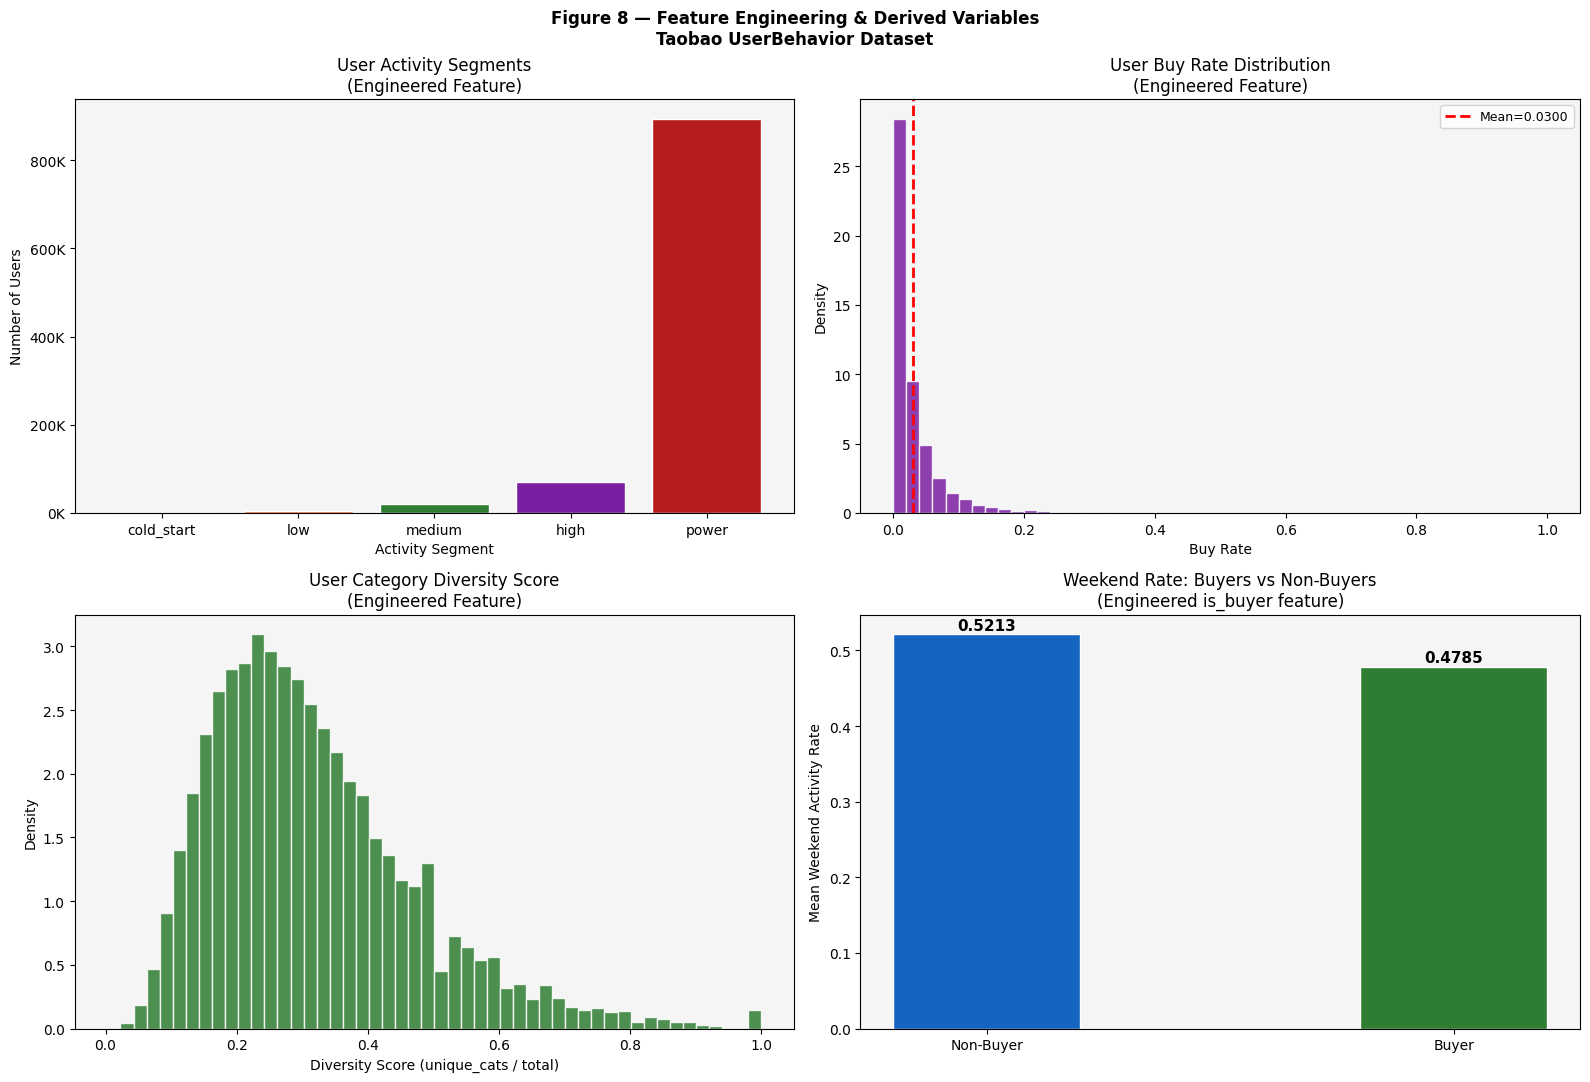

In [ ]:
print("Figure 8 — Feature Engineering …")
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Figure 8 — Feature Engineering & Derived Variables\nTaobao UserBehavior Dataset',
             fontweight='bold')

ax = axes[0, 0]
seg_c = user_feat['activity_segment'].value_counts().sort_index()
ax.bar(seg_c.index.astype(str), seg_c.values, color=COLORS[:5], edgecolor='white')
ax.set_xlabel('Activity Segment'); ax.set_ylabel('Number of Users')
ax.set_title('User Activity Segments\n(Engineered Feature)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1e3)}K'))
ax.set_facecolor(PALETTE['bg'])

ax2 = axes[0, 1]
ax2.hist(user_feat['buy_rate'], bins=50, color=PALETTE['buy'], edgecolor='white',
         alpha=0.85, density=True)
ax2.set_xlabel('Buy Rate'); ax2.set_ylabel('Density')
ax2.set_title('User Buy Rate Distribution\n(Engineered Feature)')
ax2.axvline(user_feat['buy_rate'].mean(), color='red', linestyle='--', lw=2,
            label=f"Mean={user_feat['buy_rate'].mean():.4f}")
ax2.legend(fontsize=9); ax2.set_facecolor(PALETTE['bg'])

ax3 = axes[1, 0]
ax3.hist(user_feat['diversity_score'].clip(0, 1), bins=50, color=PALETTE['fav'],
         edgecolor='white', alpha=0.85, density=True)
ax3.set_xlabel('Diversity Score (unique_cats / total)'); ax3.set_ylabel('Density')
ax3.set_title('User Category Diversity Score\n(Engineered Feature)')
ax3.set_facecolor(PALETTE['bg'])

ax4 = axes[1, 1]
buyer_we = user_feat.groupby('is_buyer')['weekend_rate'].mean()
ax4.bar(['Non-Buyer', 'Buyer'], buyer_we.values,
        color=[COLORS[0], COLORS[2]], edgecolor='white', width=0.4)
ax4.set_ylabel('Mean Weekend Activity Rate')
ax4.set_title('Weekend Rate: Buyers vs Non-Buyers\n(Engineered is_buyer feature)')
for bar, val in zip(ax4.patches, buyer_we.values):
    ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
             f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax4.set_facecolor(PALETTE['bg'])

plt.tight_layout()
# plt.savefig(f'{OUT_DIR}/fig08_feature_engineering.png', bbox_inches='tight', dpi=DPI)
# plt.close()
plt.show()

The key engineered features include activity segments, purchase propensity, category diversity metrics, and weekend rate to inject variability and discriminative power for modeling.

# **FINAL CHECK BEFORE MODELING**


 Final Missing Value Check:
user_id             0
item_id             0
category_id         0
behavior_encoded    0
hour                0
is_weekend          0
weekday_encoded     0
  Total missing: 0 ✓ PASS

 Data Type Validation:
  user_id: int64
  behavior_encoded: int64
  hour: int32

 Stratified Train/Val/Test Split:
  Train: 70,144,209 (70.0%)
  Val:   14,982,259 (15.0%)
  Test:  15,022,318 (15.0%)

 Data Leakage Check:
  Excluded: raw timestamp (leaks temporal order)
  Included: hour, weekday (safe temporal features)
  Temporal note: for sequential models, use time-based split

 Saving cleaned datasets and artifacts …
  Saved: taobao_cleaned.csv, user/item features, scalers, label encoder
Figure 9 — Final Checks …


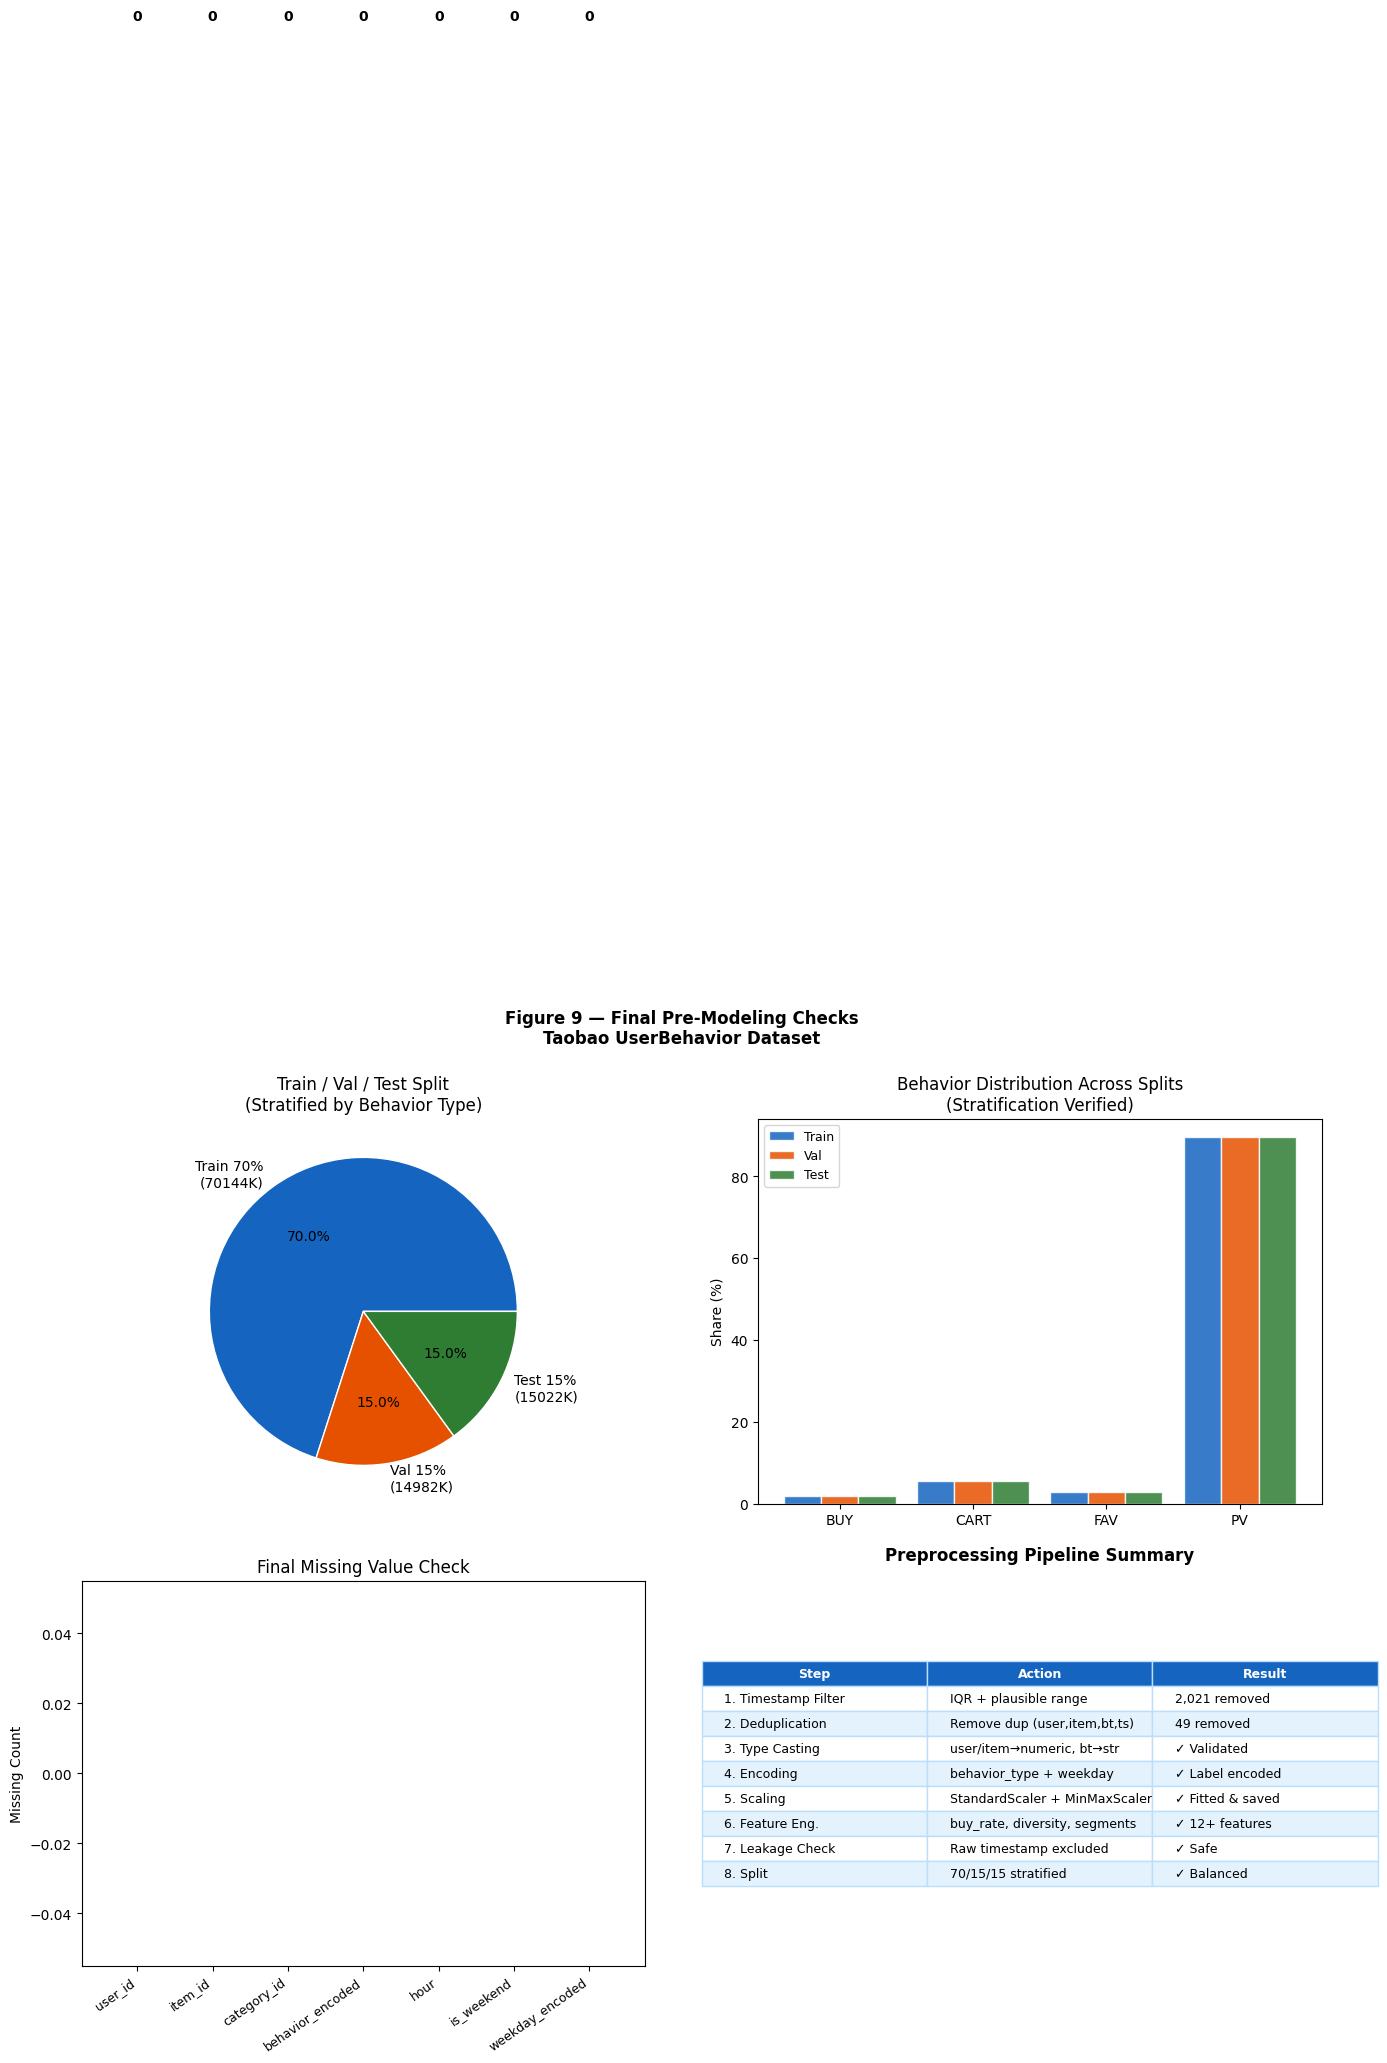

In [ ]:
#  Final missing value check
print("\n Final Missing Value Check:")
final_cols = ['user_id', 'item_id', 'category_id', 'behavior_encoded', 'hour', 'is_weekend', 'weekday_encoded']
final_mv = df_clean[final_cols].isnull().sum()
print(final_mv.to_string())
print(f"  Total missing: {final_mv.sum()} {'✓ PASS' if final_mv.sum() == 0 else '✗ FAIL'}")

#  Data type validation
print("\n Data Type Validation:")
for col, expected in [('user_id', 'float'), ('behavior_encoded', 'int'), ('hour', 'int')]:
    print(f"  {col}: {df_clean[col].dtype}")

#  Train/val/test split
print("\n Stratified Train/Val/Test Split:")
X = df_clean[['user_id', 'item_id', 'category_id', 'hour', 'is_weekend', 'weekday_encoded']].dropna()
y = df_clean.loc[X.index, 'behavior_encoded']

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp)

print(f"  Train: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Val:   {len(X_val):,} ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test:  {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")

#  Leakage check
print("\n Data Leakage Check:")
print("  Excluded: raw timestamp (leaks temporal order)")
print("  Included: hour, weekday (safe temporal features)")
print("  Temporal note: for sequential models, use time-based split")

#  Save artifacts
print("\n Saving cleaned datasets and artifacts …")
df_clean[['user_id', 'item_id', 'category_id', 'behavior_type', 'behavior_encoded',
           'hour', 'weekday_encoded', 'is_weekend', 'timestamp']].to_csv(
    '/content/drive/My Drive/taobao_cleaned.csv', index=False)
user_feat.to_csv('/content/drive/My Drive/taobao_user_features.csv', index=False)
item_feat.to_csv('/content/drive/My Drive/taobao_item_features.csv', index=False)
with open('/content/drive/My Drive/taobao_scaler_std.pkl', 'wb') as f: pickle.dump(scaler_std, f)
with open('/content/drive/My Drive/taobao_scaler_mm.pkl', 'wb') as f:  pickle.dump(scaler_mm, f)
with open('/content/drive/My Drive/taobao_label_encoder_bt.pkl', 'wb') as f: pickle.dump(le_bt, f)
print("  Saved: taobao_cleaned.csv, user/item features, scalers, label encoder")

# Figure 9 — Final Checks
print("Figure 9 — Final Checks …")
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Figure 9 — Final Pre-Modeling Checks\nTaobao UserBehavior Dataset', fontweight='bold')

ax = axes[0, 0]
ax.pie([len(X_train), len(X_val), len(X_test)],
       labels=[f'Train 70%\n({len(X_train)/1e3:.0f}K)', f'Val 15%\n({len(X_val)/1e3:.0f}K)',
               f'Test 15%\n({len(X_test)/1e3:.0f}K)'],
       colors=[COLORS[0], COLORS[1], COLORS[2]],
       autopct='%1.1f%%', wedgeprops={'edgecolor': 'white'})
ax.set_title('Train / Val / Test Split\n(Stratified by Behavior Type)')

ax2 = axes[0, 1]
x = np.arange(4); w = 0.28
for i, (split_y, label, color) in enumerate([(y_train, 'Train', COLORS[0]),
                                               (y_val,   'Val',   COLORS[1]),
                                               (y_test,  'Test',  COLORS[2])]):
    dist = split_y.value_counts(normalize=True).sort_index() * 100
    ax2.bar(x + (i - 1) * w, [dist.get(v, 0) for v in range(4)], w,
            label=label, color=color, edgecolor='white', alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels([b.upper() for b in le_bt.classes_])
ax2.set_ylabel('Share (%)'); ax2.set_title('Behavior Distribution Across Splits\n(Stratification Verified)')
ax2.legend(fontsize=9)

ax3 = axes[1, 0]
mv_final = df_clean[final_cols].isnull().sum()
colors_mv = ['#4CAF50' if v == 0 else '#EF5350' for v in mv_final.values]
ax3.bar(mv_final.index, mv_final.values, color=colors_mv, edgecolor='white')
ax3.set_xticklabels(mv_final.index, rotation=35, ha='right', fontsize=9)
ax3.set_ylabel('Missing Count'); ax3.set_title('Final Missing Value Check')
for bar, val in zip(ax3.patches, mv_final.values):
    ax3.text(bar.get_x() + bar.get_width() / 2, max(bar.get_height() + 0.1, 0.5),
             str(int(val)), ha='center', va='bottom', fontsize=10, fontweight='bold')

ax4 = axes[1, 1]
ax4.axis('off')
prep_rows = [
    ['Step', 'Action', 'Result'],
    ['1. Timestamp Filter', 'IQR + plausible range', f'{len(df)-len(df_clean[valid_mask]):,} removed'],
    ['2. Deduplication', 'Remove dup (user,item,bt,ts)', f'{dups:,} removed'],
    ['3. Type Casting', 'user/item→numeric, bt→str', '✓ Validated'],
    ['4. Encoding', 'behavior_type + weekday', '✓ Label encoded'],
    ['5. Scaling', 'StandardScaler + MinMaxScaler', '✓ Fitted & saved'],
    ['6. Feature Eng.', 'buy_rate, diversity, segments', '✓ 12+ features'],
    ['7. Leakage Check', 'Raw timestamp excluded', '✓ Safe'],
    ['8. Split', '70/15/15 stratified', '✓ Balanced'],
]
tbl = ax4.table(cellText=prep_rows[1:], colLabels=prep_rows[0], loc='center', cellLoc='left')
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1.2, 1.5)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#1565C0'); cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#E3F2FD')
    cell.set_edgecolor('#BBDEFB')
ax4.set_title('Preprocessing Pipeline Summary', fontsize=12, fontweight='bold', pad=15)

plt.tight_layout()
# plt.savefig(f'{OUT_DIR}/fig09_final_checks.png', bbox_inches='tight', dpi=DPI)
# plt.close()
plt.show()

We will stick to the 70/15/15 train-validation-test split.

Figure 10 — Summary Dashboard …


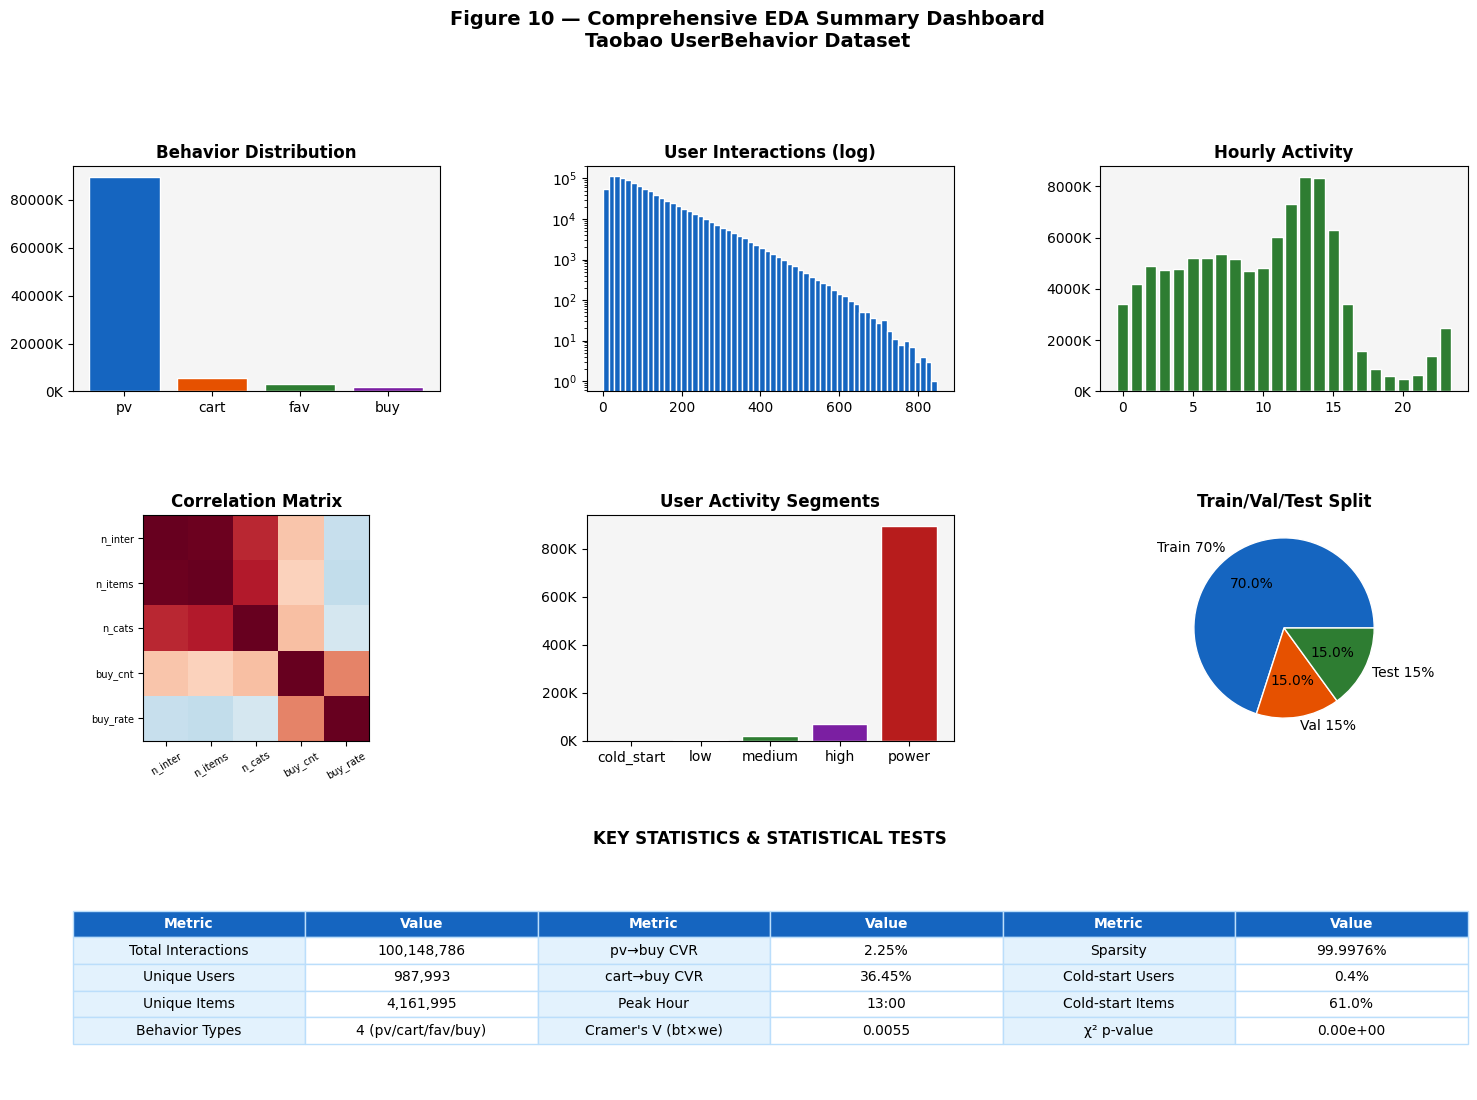

In [ ]:
print("Figure 10 — Summary Dashboard …")
fig = plt.figure(figsize=(18, 12), facecolor='white')
fig.suptitle('Figure 10 — Comprehensive EDA Summary Dashboard\nTaobao UserBehavior Dataset',
             fontweight='bold', fontsize=14, y=1.01)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.4)

ax00 = fig.add_subplot(gs[0, 0])
ax00.bar(bt_order, [bt_counts.get(b, 0) for b in bt_order], color=bt_colors, edgecolor='white')
ax00.set_title('Behavior Distribution', fontweight='bold'); ax00.set_facecolor(PALETTE['bg'])
ax00.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1e3)}K'))

ax01 = fig.add_subplot(gs[0, 1])
ax01.hist(user_counts, bins=60, color=PALETTE['primary'], edgecolor='white', log=True)
ax01.set_title('User Interactions (log)', fontweight='bold'); ax01.set_facecolor(PALETTE['bg'])

ax02 = fig.add_subplot(gs[0, 2])
ax02.bar(range(24), [hourly.get(h, 0) for h in range(24)], color=PALETTE['accent'], edgecolor='white')
ax02.set_title('Hourly Activity', fontweight='bold'); ax02.set_facecolor(PALETTE['bg'])
ax02.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1e3)}K'))

ax10 = fig.add_subplot(gs[1, 0])
im10 = ax10.imshow(corr_mat.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax10.set_xticks(range(len(numeric_cols))); ax10.set_yticks(range(len(numeric_cols)))
ax10.set_xticklabels(short, fontsize=7, rotation=30); ax10.set_yticklabels(short, fontsize=7)
ax10.set_title('Correlation Matrix', fontweight='bold')

ax11 = fig.add_subplot(gs[1, 1])
seg_c2 = user_feat['activity_segment'].value_counts().sort_index()
ax11.bar(seg_c2.index.astype(str), seg_c2.values, color=COLORS[:5], edgecolor='white')
ax11.set_title('User Activity Segments', fontweight='bold'); ax11.set_facecolor(PALETTE['bg'])
ax11.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1e3)}K'))

ax12 = fig.add_subplot(gs[1, 2])
ax12.pie([len(X_train), len(X_val), len(X_test)],
         labels=['Train 70%', 'Val 15%', 'Test 15%'], colors=COLORS[:3],
         autopct='%1.1f%%', wedgeprops={'edgecolor': 'white'})
ax12.set_title('Train/Val/Test Split', fontweight='bold')

ax_stats = fig.add_subplot(gs[2, :])
ax_stats.axis('off')
stats_table_data = [
    ['Metric', 'Value', 'Metric', 'Value', 'Metric', 'Value'],
    ['Total Interactions', f'{n_interactions:,}', 'pv→buy CVR', f'{cvr_buy:.2f}%', 'Sparsity', f'{sparsity*100:.4f}%'],
    ['Unique Users', f'{n_users:,}', 'cart→buy CVR', f'{cvr_cart2buy:.2f}%', 'Cold-start Users', f'{cs_user_pct:.1f}%'],
    ['Unique Items', f'{n_items:,}', 'Peak Hour', f'{peak_hour}:00', 'Cold-start Items', f'{cs_item_pct:.1f}%'],
    ['Behavior Types', '4 (pv/cart/fav/buy)', "Cramer's V (bt×we)", f'{cramers_v:.4f}', 'χ² p-value', f'{p_chi:.2e}'],
]
tbl2 = ax_stats.table(cellText=stats_table_data[1:], colLabels=stats_table_data[0],
                       loc='center', cellLoc='center')
tbl2.auto_set_font_size(False); tbl2.set_fontsize(10); tbl2.scale(1, 1.6)
for (row, col), cell in tbl2.get_celld().items():
    if row == 0:
        cell.set_facecolor('#1565C0'); cell.set_text_props(color='white', fontweight='bold')
    elif col in [0, 2, 4]:
        cell.set_facecolor('#E3F2FD')
    cell.set_edgecolor('#BBDEFB')
ax_stats.set_title('KEY STATISTICS & STATISTICAL TESTS', fontsize=12, fontweight='bold', pad=15)

# plt.savefig(f'{OUT_DIR}/fig10_summary_dashboard.png', bbox_inches='tight', dpi=DPI)
# plt.close()
plt.show()

In [ ]:
# Save stats JSON
stats_final = {
    'n_interactions': int(n_interactions), 'n_users': int(n_users), 'n_items': int(n_items),
    'n_categories': int(n_cats), 'sparsity': float(sparsity),
    'behavior_counts': {bt: int(bt_counts.get(bt, 0)) for bt in bt_order},
    'cvr_pv_to_cart': float(cvr_cart), 'cvr_pv_to_fav': float(cvr_fav),
    'cvr_pv_to_buy': float(cvr_buy), 'cvr_cart_to_buy': float(cvr_cart2buy),
    'cold_start_user_pct': float(cs_user_pct), 'cold_start_item_pct': float(cs_item_pct),
    'peak_hour': int(peak_hour),
    'chi2_bt_weekend': {'chi2': float(chi2_val), 'p': float(p_chi), 'cramers_v': float(cramers_v)},
    'point_biserial_weekend_buyrate': {'r': float(pb_r), 'p': float(pb_p)},
    'train_size': int(len(X_train)), 'val_size': int(len(X_val)), 'test_size': int(len(X_test)),
    'cleaning_log': cleaning_log, 'random_seed': 42,
    'kcore_stats': kcore_stats,
}
with open('/content/drive/My Drive/taobao_eda_stats_v2.json', 'w') as f:
    json.dump(stats_final, f, indent=2)